## Importations

In [3]:
import numpy as np
import pandas as pd
import math
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, chi2_contingency, zscore, f_oneway, pearsonr, spearmanr, normaltest, levene, mannwhitneyu, ttest_ind

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.oneway import anova_oneway

import plotly.express as px

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")

### Data Loading

In [4]:
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")



engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)

In [74]:
tables = [
    'champ', 'mvp', 'player_season_stats', 'players', 
    'positions', 'seasons', 'team_season_stats', 'teams'
]

try:
    for table in tables:
        df_name = f"{table}"
        
        globals()[df_name] = pd.read_sql_table(table, con=engine)
        
        rows, cols = globals()[df_name].shape
        print(f"{df_name:<22} | Shape: {rows:<6} rows, {cols:<3} columns")

except Exception as e:
    print(f"Error loading tables: {e}")

champ                  | Shape: 7      rows, 3   columns
mvp                    | Shape: 81     rows, 11  columns
player_season_stats    | Shape: 4513   rows, 34  columns
players                | Shape: 1172   rows, 12  columns
positions              | Shape: 5      rows, 3   columns
seasons                | Shape: 7      rows, 3   columns
team_season_stats      | Shape: 210    rows, 32  columns
teams                  | Shape: 30     rows, 12  columns


In [5]:
# players = pd.read_csv("nba_players.csv")
# players_stats = pd.read_csv("nba_player_season_stats.csv")
# teams = pd.read_csv("nba_teams.csv")
# mvp = pd.read_csv("nba_mvp_votes.csv")
# seasons = pd.read_csv("nba_season.csv")
# champ = pd.read_csv("nba_champ.csv")

In [77]:
player_season_stats.columns

Index(['player_season_stats_id', 'player_id', 'season_id', 'team_id',
       'position_id', 'rank', 'position', 'games', 'games_started',
       'minutes_played', 'three_point_field_goals',
       'three_point_field_goals_attempted', 'two_point_field_goals',
       'two_point_field_goals_attempted', 'effective_field_goal_percentage',
       'free_throws', 'free_throws_attempted', 'offensive_rebounds',
       'defensive_rebounds', 'assists', 'steals', 'blocks', 'turnovers',
       'points', 'personal_fouls', 'triple_doubles', 'OWS', 'DWS', 'WS',
       'OBPM', 'DBPM', 'BPM', 'VORP', 'PER'],
      dtype='object')

In [80]:
players.columns

Index(['player_id', 'name', 'birth_date', 'height_cm', 'weight_kg', 'position',
       'draft_year', 'nba_debut', 'experience_years', 'is_active',
       'birth_place', 'shoots'],
      dtype='object')

In [81]:
mvp.columns

Index(['MVP_id', 'player_id', 'season_id', 'team_id', 'rank',
       'first_place_votes', 'points_won', 'points_max', 'share', 'win_shares',
       'win_shares_per_48'],
      dtype='object')

In [82]:
team_season_stats.columns

Index(['team_season_stats_id', 'team_id', 'season_id', 'league', 'wins',
       'losses', 'finish', 'average_height', 'average_weight', 'average_age',
       'simple_rating_system', 'pace', 'relative_pace', 'offensive_rating',
       'relative_offensive_rating', 'top_win_shares_player', 'games',
       'minutes_played', 'three_point_field_goals',
       'three_point_field_goal_attempts', 'two_point_field_goals',
       'two_point_field_goal_attempts', 'free_throws', 'free_throws_attempts',
       'offensive_rebounds', 'defensive_rebounds', 'assists', 'steals',
       'blocks', 'turnovers', 'points', 'personal_fouls'],
      dtype='object')

Build the season-level analysis table: one row per player per season,
joined with player biography, team name, and season label.

Merge correctness notes:
- player_id is a primary key on `players`, so this left join cannot fan out
 player_season_stats rows -- row count after the merge equals row count before.
- `players_stats` and `players` both have a "position" column; suffixes=("", "_bio")
 keeps the LEFT frame's (season-specific) "position" unchanged, which is the one
 `position_main` below correctly uses -- not the player's career-long position.

In [9]:
data = players_stats.merge(players[["player_id", "name", "height_cm", "weight_kg", "position", "birth_place", "shoots",
                     "draft_year", "nba_debut", "experience_years", "is_active"]],
           on="player_id", how="left", suffixes=("", "_bio")).merge(teams[["team_id", "team_name"]], on="team_id", how="left").merge(seasons, on="season_id", how="left")

# the career-position column created by the "position" name collision above is
# never used (position_main uses the season-specific "position" instead) -- drop it
data = data.drop(columns=["position_bio"])

In [10]:
# core derived per-game / shooting metrics
data["fg_pct"] = data["field_goals"] / data["field_goals_attempted"].replace(0, np.nan)
data["ft_pct"] = data["free_throws"] / data["free_throws_attempted"].replace(0, np.nan)
data["points_per_game"] = data["points"] / data["games"].replace(0, np.nan)
data["assists_per_game"] = data["assists"] / data["games"].replace(0, np.nan)
data["rebounds_per_game"] = (data["offensive_rebounds"] + data["defensive_rebounds"]) / data["games"].replace(0, np.nan)
data["true_shooting_pct"] = data["points"] / (2 * (data["field_goals_attempted"] + 0.44 * data["free_throws_attempted"])).replace(0, np.nan)

Season-specific experience fix:

players.experience_years / players.is_active are the player's CURRENT totals, not what they were during this particular season row. Attaching that static value to every historical season is misleading for any season-level test (e.g. "experience_years_bin" would overstate how experienced a player was in an old season if they're still playing today). Reconstruct experience AT THE TIME OF EACH SEASON from nba_debut instead, and keep the static column too but rename it so its "current, not season-specific" meaning is explicit.

In [11]:
data = data.rename(columns={"experience_years": "experience_years_current_total"})
data["season_year"] = data["season"].astype(str).str[:4].astype(int)
data["experience_years"] = (data["season_year"] - data["nba_debut"]).clip(lower=0)

data.shape

(4513, 51)

#### First look at the data

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   player_id                          4513 non-null   int64  
 1   team_id                            4513 non-null   int64  
 2   season_id                          4513 non-null   int64  
 3   rank                               4513 non-null   int64  
 4   age                                4513 non-null   int64  
 5   position                           4513 non-null   object 
 6   games                              4513 non-null   int64  
 7   games_started                      4513 non-null   int64  
 8   minutes_played                     4513 non-null   int64  
 9   field_goals                        4513 non-null   int64  
 10  field_goals_attempted              4513 non-null   int64  
 11  field_goal_percentage              4476 non-null   float

In [13]:
data.head(10)

,player_id,team_id,season_id,rank,age,position,games,games_started,minutes_played,field_goals,...,team_name,season,fg_pct,ft_pct,points_per_game,assists_per_game,rebounds_per_game,true_shooting_pct,season_year,experience_years
0,1415,11,1,1,30,SG,68,68,2483,672,...,Houston Rockets,2019-20,0.443857,0.865000,34.338235,7.529412,6.558824,0.625670,2019,10
1,1623,25,1,2,29,PG,66,66,2474,624,...,Portland Trail Blazers,2019-20,0.462565,0.888031,29.969697,8.030303,4.303030,0.627172,2019,7
2,1101,24,1,3,23,SG,70,70,2512,627,...,Phoenix Suns,2019-20,0.488698,0.919450,26.614286,6.514286,4.242857,0.618132,2019,4
3,1022,17,1,4,25,PF,63,63,1917,685,...,Milwaukee Bucks,2019-20,0.553312,0.632750,29.476190,5.619048,13.587302,0.612968,2019,6
4,2166,1,1,5,21,PG,60,60,2120,546,...,Atlanta Hawks,2019-20,0.437150,0.860465,29.633333,9.333333,4.250000,0.594665,2019,1
5,1271,7,1,6,20,PG,61,61,2047,581,...,Dallas Mavericks,2019-20,0.462948,0.758007,28.836066,8.819672,9.393443,0.585443,2019,1
6,1068,30,1,7,26,SG,57,57,2053,593,...,Washington Wizards,2019-20,0.455104,0.842451,30.543860,6.087719,4.245614,0.578759,2019,7
7,1512,14,1,8,35,PG,67,67,2316,643,...,Los Angeles Lakers,2019-20,0.493477,0.692913,25.343284,10.208955,7.835821,0.577300,2019,16
8,1723,29,1,9,23,SG,69,69,2364,602,...,Utah Jazz,2019-20,0.448584,0.863354,23.985507,4.260870,4.405797,0.557735,2019,2
9,1244,14,1,10,26,PF,62,62,2131,551,...,Los Angeles Lakers,2019-20,0.502737,0.845714,26.096774,3.225806,9.306452,0.609646,2019,7


In [14]:
print("The dataset contains", data.shape[0], "rows and", data.shape[1], "columns.")
print("The dataset contains", data.duplicated().sum(), "duplicate rows.")

The dataset contains 4513 rows and 51 columns.
The dataset contains 0 duplicate rows.


In [15]:
# Target: did this player-season receive at least one MVP vote?
# This is the binary outcome used throughout the "vs target" analysis below,
# playing the same role the Anxious/Not-Anxious label plays in the reference notebook.
mvp_pairs = set(zip(mvp["player_id"], mvp["season_id"]))
data["win_mvp"] = data.apply(lambda r: int((r["player_id"], r["season_id"]) in mvp_pairs), axis=1)
target = "win_mvp"
data["win_mvp"].value_counts()

win_mvp
0    4430
1      83
Name: count, dtype: int64

In [16]:
numeric_columns = ["minutes_played", "field_goals", "field_goals_attempted",
                   "three_point_field_goals", "three_point_field_goals_attempted",
                   "two_point_field_goals", "two_point_field_goals_attempted",
                   "free_throws", "free_throws_attempted",
                   "offensive_rebounds", "defensive_rebounds", "assists", "steals", "blocks",
                   "turnovers", "points", "personal_fouls", "triple_doubles",
                   "points_per_game", "assists_per_game", "rebounds_per_game",
                   "fg_pct", "ft_pct", "true_shooting_pct", "height_cm", "weight_kg",
                   "games", "games_started", "experience_years"]

categorical_columns = ["position_main", "team_name", "season", "shoots",
                       "is_active", "win_mvp"]

In [17]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,4513.0,1579.512963,338.901388,1001.0,1287.000000,1578.000000,1870.000000,2172.000000
team_id,4513.0,15.568580,8.707814,1.0,8.000000,15.000000,23.000000,30.000000
season_id,4513.0,4.046089,1.983443,1.0,2.000000,4.000000,6.000000,7.000000
rank,4513.0,285.297585,160.259976,1.0,149.000000,288.000000,421.000000,605.000000
age,4513.0,25.872812,4.164210,19.0,23.000000,25.000000,28.000000,43.000000
games,4513.0,39.161755,24.847870,1.0,16.000000,39.000000,62.000000,82.000000
games_started,4513.0,18.366940,24.402652,0.0,0.000000,5.000000,31.000000,82.000000
minutes_played,4513.0,886.993796,771.588031,1.0,185.000000,680.000000,1473.000000,3036.000000
field_goals,4513.0,152.513184,161.764555,0.0,23.000000,94.000000,237.000000,860.000000
field_goals_attempted,4513.0,325.820519,337.929050,0.0,53.000000,211.000000,506.000000,1656.000000


In [18]:
players.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,1172.0,1586.500000,338.471565,1001.0,1293.75,1586.5,1879.25,2172.0
height_cm,1172.0,198.715017,8.413868,170.0,193.00,198.0,203.75,229.0
weight_kg,1172.0,96.501706,10.784869,72.0,88.00,96.0,104.00,141.0
draft_year,749.0,2017.813084,5.370477,1998.0,2014.00,2019.0,2022.00,2025.0
nba_debut,1172.0,2019.078498,4.967424,1999.0,2017.00,2020.0,2023.00,2026.0
experience_years,1172.0,5.252560,4.373006,1.0,2.00,4.0,8.00,23.0


## Before Cleaning

### Normality

In [19]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    results = []

    for col in columns:
        clean_data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        n = len(clean_data)

        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue

        sample = clean_data.sample(min(n, 5000), random_state=42)
        stat, p_value = shapiro(sample)

        result = "Normal" if p_value > alpha else "Not normal"

        results.append([col, n, p_value, result])

    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )

    return result_df

In [20]:
normality_checker(data, numeric_columns)

,Column,Sample Size,p-value,Result
0,minutes_played,4513,2.029056e-46,Not normal
1,field_goals,4513,5.280769e-55,Not normal
2,field_goals_attempted,4513,2.678098e-54,Not normal
3,three_point_field_goals,4513,3.783170e-59,Not normal
4,three_point_field_goals_attempted,4513,2.444412e-57,Not normal
5,two_point_field_goals,4513,1.020425e-59,Not normal
6,two_point_field_goals_attempted,4513,5.226048e-59,Not normal
7,free_throws,4513,2.348743e-66,Not normal
8,free_throws_attempted,4513,4.001775e-65,Not normal
9,offensive_rebounds,4513,2.141776e-63,Not normal


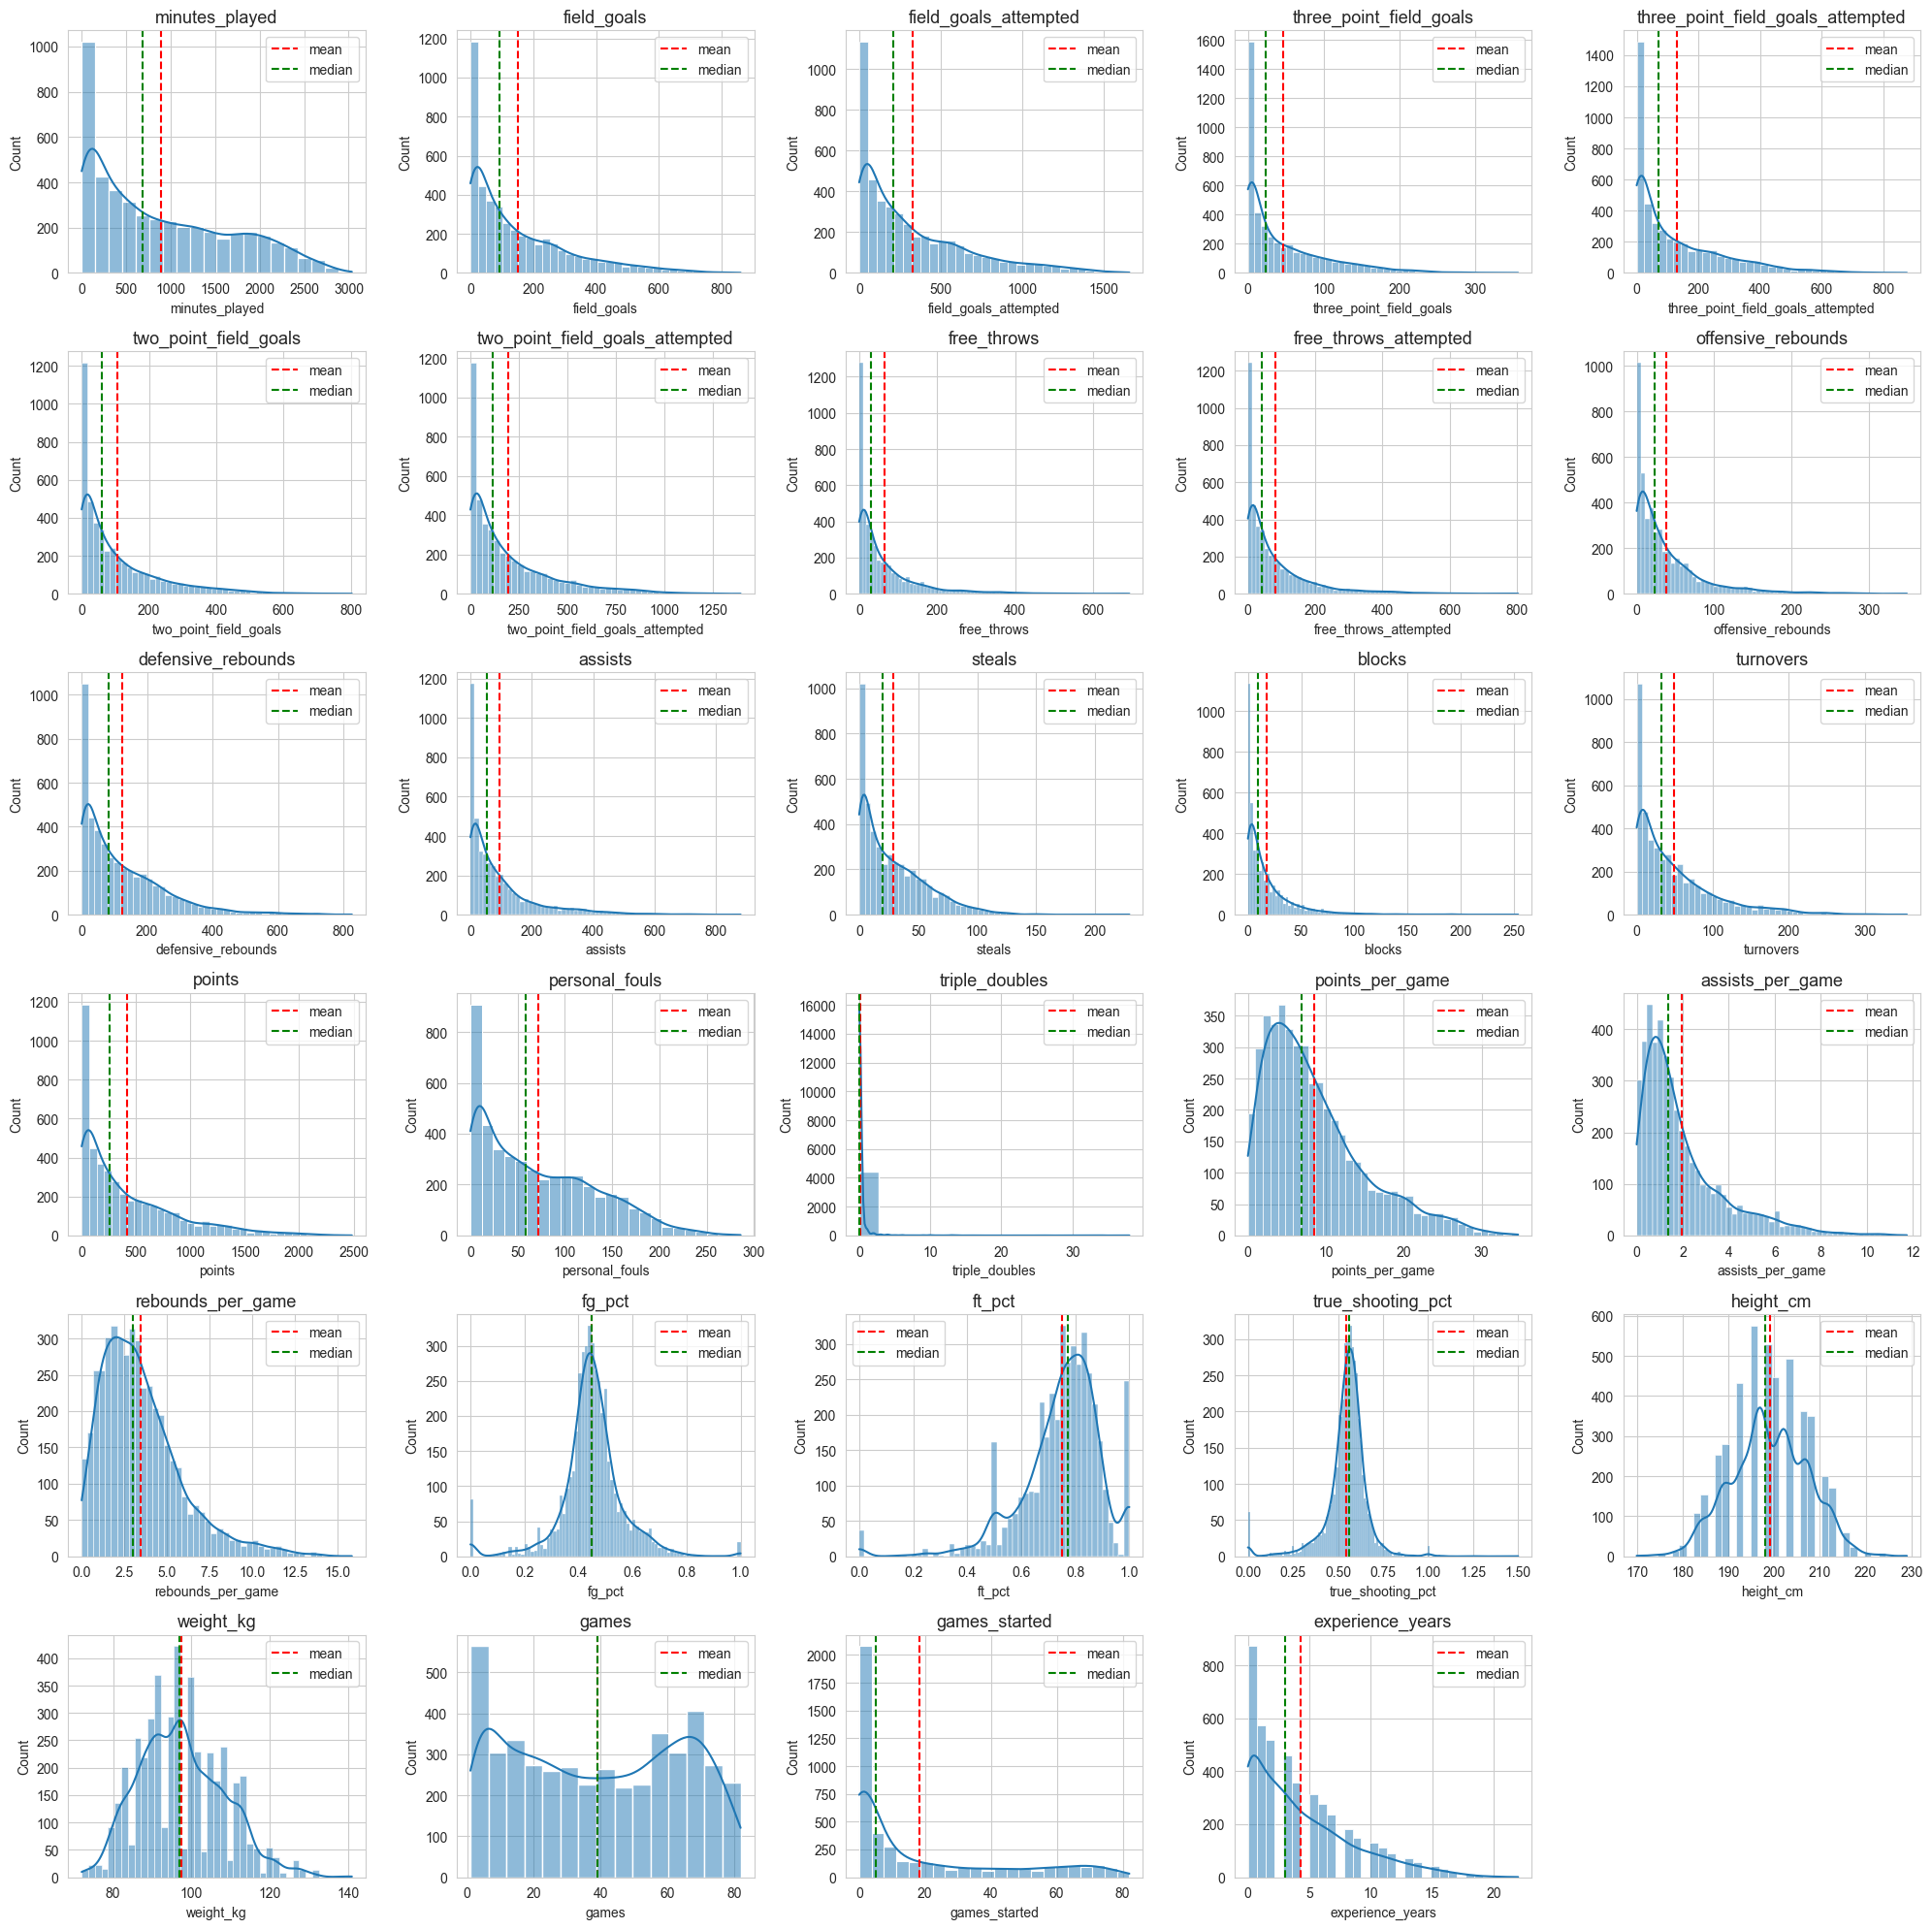

In [21]:
fig, axes = plt.subplots(6, 5, figsize=(20, 20))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(data[c].replace([np.inf, -np.inf], np.nan), kde=True, ax=ax)
    ax.axvline(data[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(data[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=13)
    ax.legend(fontsize=10)

for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### NaN percentage

In [22]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [23]:
nan_percentage(data)

,Missing Count,Nan Percent
draft_year,1192,26.412586
ft_pct,314,6.957678
free_throw_percentage,314,6.957678
three_point_field_goal_percentage,284,6.292932
two_point_field_goal_percentage,78,1.728340
fg_pct,37,0.819854
field_goal_percentage,37,0.819854
effective_field_goal_percentage,37,0.819854
true_shooting_pct,35,0.775537
nba_debut,0,0.000000


In [24]:
# draft_year is missing precisely for undrafted players -- check the relationship
# between missing draft_year and having a recorded nba_debut
pd.crosstab(data["draft_year"].isna(), data["nba_debut"].notna())

nba_debut,True
draft_year,
False,3321
True,1192


## Cleaning Data

In [25]:
# draft_year is genuinely missing for undrafted players -- this is meaningful information,
# not noise, so it gets an explicit label instead of being dropped or median-filled
data["draft_year"] = data["draft_year"].astype("Int64")
data["is_undrafted"] = data["draft_year"].isna().map({True: "Undrafted", False: "Drafted"})
data["is_undrafted"].value_counts()

is_undrafted
Drafted      3321
Undrafted    1192
Name: count, dtype: int64

### Impute NaNs

In [26]:
def fill_numeric(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            med = data[c].median()
            print(c, "->", data[c].isnull().sum(), "filled with median", round(med, 3))
            data[c] = data[c].fillna(med)
    return data

def fill_categorical(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            m = data[c].mode()[0]
            print(c, "->", data[c].isnull().sum(), "filled with mode", m)
            data[c] = data[c].fillna(m)
    return data

In [27]:
numeric_to_fill = ["fg_pct", "ft_pct", "free_throw_percentage", "three_point_field_goal_percentage", "two_point_field_goal_percentage", "field_goal_percentage" ,"true_shooting_pct", "effective_field_goal_percentage"]

In [28]:
data = fill_numeric(data, numeric_to_fill)

fg_pct -> 37 filled with median 0.448
ft_pct -> 314 filled with median 0.773
free_throw_percentage -> 314 filled with median 0.773
three_point_field_goal_percentage -> 284 filled with median 0.34
two_point_field_goal_percentage -> 78 filled with median 0.526
field_goal_percentage -> 37 filled with median 0.448
true_shooting_pct -> 35 filled with median 0.56
effective_field_goal_percentage -> 37 filled with median 0.529


In [29]:
print("Remaining missing values (excluding draft_year, kept as-is):",
      data.drop(columns=["draft_year"]).isnull().sum().sum())

Remaining missing values (excluding draft_year, kept as-is): 0


## Outliers, Binning & Reclassifying

### Outliers

In [30]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [31]:
for c in numeric_columns:
    print(c, int(outlier_detector(data[c]).sum()))

minutes_played 0
field_goals 136
field_goals_attempted 136
three_point_field_goals 161
three_point_field_goals_attempted 134
two_point_field_goals 255
two_point_field_goals_attempted 247
free_throws 331
free_throws_attempted 311
offensive_rebounds 292
defensive_rebounds 138
assists 345
steals 60
blocks 317
turnovers 225
points 147
personal_fouls 7
triple_doubles 254
points_per_game 166
assists_per_game 288
rebounds_per_game 166
fg_pct 429
ft_pct 162
true_shooting_pct 377
height_cm 9
weight_kg 62
games 0
games_started 60
experience_years 44


### Binning

Binning turns a continuous variable into a smaller number of meaningful groups — useful when the
raw scale is noisy but a coarser grouping tells a clearer story (e.g. career stage instead of
exact years of experience).

In [32]:
def binning(data, col, method="custom", bins=5, thresholds=None, labels=None):

    df = data.copy()
    new_col = col + "_bin"

    if method == "equal width":
        df[new_col] = pd.cut(df[col], bins=bins, labels=labels)
    elif method == "quantile":
        df[new_col] = pd.qcut(df[col], q=bins, labels=labels, duplicates="drop")
    elif method == "custom":
        df[new_col] = pd.cut(df[col], bins=thresholds, labels=labels)

    print("column:", new_col)
    print("number of groups:", df[new_col].nunique())

    return df

In [33]:
data = binning(data, "height_cm", method="custom",
               thresholds=[0, 190, 198, 206, 260],
               labels=["Short (<190cm)", "Average (190-198cm)", "Tall (198-206cm)", "Very Tall (206cm+)"])
data["height_cm_bin"].value_counts().sort_index()

column: height_cm_bin
number of groups: 4


height_cm_bin
Short (<190cm)          849
Average (190-198cm)    1536
Tall (198-206cm)       1300
Very Tall (206cm+)      828
Name: count, dtype: int64

In [34]:
data = binning(data, "experience_years", method="custom",
               thresholds=[-0.01, 1, 4, 9, 30],
               labels=["Rookie", "Developing (2-4 yr)", "Prime (5-9 yr)", "Veteran (10+ yr)"])
data["experience_years_bin"].value_counts().sort_index()

column: experience_years_bin
number of groups: 4


experience_years_bin
Rookie                 1444
Developing (2-4 yr)    1333
Prime (5-9 yr)         1156
Veteran (10+ yr)        580
Name: count, dtype: int64

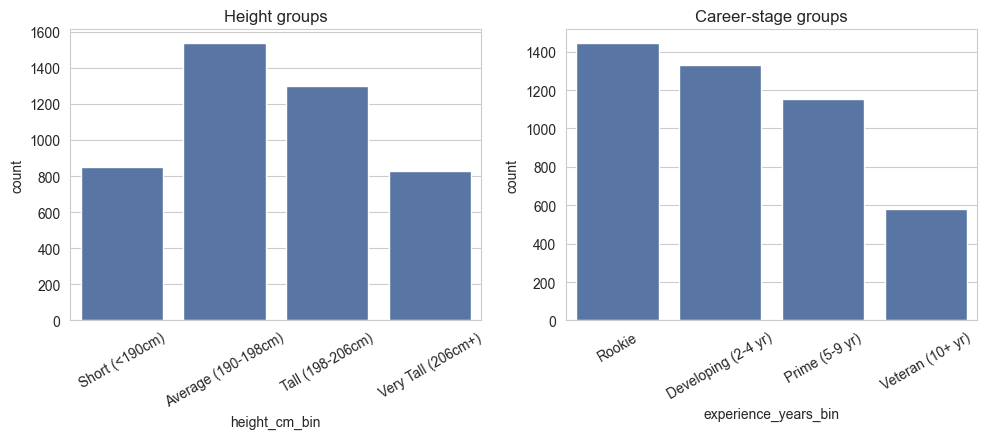

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.countplot(data=data, x="height_cm_bin", color="#4C72B0", ax=axes[0])
axes[0].set_title("Height groups")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=data, x="experience_years_bin", color="#4C72B0", ax=axes[1])
axes[1].set_title("Career-stage groups")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Reclassifying categorical variables

In [36]:
def reclassify_categorical(data, col, mapping_fn, new_col=None):
    data = data.copy()
    new_col = new_col or f"{col}_recls"
    data[new_col] = data[col].apply(mapping_fn)
    return data

In [37]:
# US states (birth_place is a US state for domestic players, a country name otherwise)
US_STATES = {
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan",
    "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming", "District of Columbia"
}

def origin_group(place):
    if pd.isna(place):
        return "Unknown"
    return "USA" if place in US_STATES else "International"

data = reclassify_categorical(data, "birth_place", origin_group, new_col="player_origin")
data["player_origin"].value_counts()

player_origin
USA              3493
International    1020
Name: count, dtype: int64

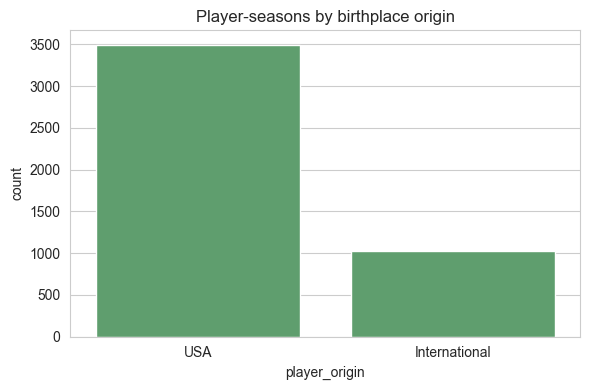

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="player_origin", color="#55A868")
plt.title("Player-seasons by birthplace origin")
plt.tight_layout()
plt.show()

### Final Columns

In [39]:
data.tail()

,player_id,team_id,season_id,rank,age,position,games,games_started,minutes_played,field_goals,...,assists_per_game,rebounds_per_game,true_shooting_pct,season_year,experience_years,win_mvp,is_undrafted,height_cm_bin,experience_years_bin,player_origin
4508,2017,13,7,578,24,PF,8,0,32,0,...,0.125,0.375,0.086806,2025,0,0,Undrafted,Tall (198-206cm),Rookie,International
4509,1131,6,7,579,26,SG,1,0,3,0,...,0.000,1.000,0.000000,2025,0,0,Undrafted,Short (<190cm),Rookie,USA
4510,1308,5,7,580,19,PF,2,0,6,0,...,0.000,0.000,0.000000,2025,0,0,Drafted,Tall (198-206cm),Rookie,International
4511,1312,20,7,581,24,SF,5,0,8,0,...,0.000,0.400,0.000000,2025,1,0,Undrafted,Tall (198-206cm),Rookie,International
4512,1442,28,7,582,22,PG,2,0,13,0,...,1.000,0.500,0.000000,2025,0,0,Undrafted,Short (<190cm),Rookie,USA


In [40]:
data.columns

Index(['player_id', 'team_id', 'season_id', 'rank', 'age', 'position', 'games',
       'games_started', 'minutes_played', 'field_goals',
       'field_goals_attempted', 'field_goal_percentage',
       'three_point_field_goals', 'three_point_field_goals_attempted',
       'three_point_field_goal_percentage', 'two_point_field_goals',
       'two_point_field_goals_attempted', 'two_point_field_goal_percentage',
       'effective_field_goal_percentage', 'free_throws',
       'free_throws_attempted', 'free_throw_percentage', 'offensive_rebounds',
       'defensive_rebounds', 'total_rebounds', 'assists', 'steals', 'blocks',
       'turnovers', 'personal_fouls', 'points', 'triple_doubles', 'name',
       'height_cm', 'weight_kg', 'birth_place', 'shoots', 'draft_year',
       'nba_debut', 'experience_years_current_total', 'is_active', 'team_name',
       'season', 'fg_pct', 'ft_pct', 'points_per_game', 'assists_per_game',
       'rebounds_per_game', 'true_shooting_pct', 'season_year',
       'e

## Column Descriptions

### 1) players_stats columns (raw per-player, per-season stats)
- **player_id**: Unique identifier for the player
- **team_id**: Identifier of the team the player played for that season
- **season_id**: Numeric identifier for the season
- **rank**: Player's rank for that season (e.g., in voting or a statistical leaderboard)
- **age**: Player's age during that season
- **position**: Player's position for that season (e.g., Guard, Forward, Center — may be a combination like "Forward and Center")
- **games**: Number of games played that season
- **games_started**: Number of games started as a starter
- **minutes_played**: Total minutes played that season
- **field_goals**: Successful field goals made (2PT + 3PT combined)
- **field_goals_attempted**: Field goal attempts (successful or not)
- **field_goal_percentage**: FG% = field_goals ÷ field_goals_attempted
- **three_point_field_goals**: Successful three-point shots made
- **three_point_field_goals_attempted**: Three-point shot attempts
- **three_point_field_goal_percentage**: 3P% success rate
- **two_point_field_goals**: Successful two-point shots made
- **two_point_field_goals_attempted**: Two-point shot attempts
- **two_point_field_goal_percentage**: 2P% success rate
- **effective_field_goal_percentage**: Shooting efficiency metric that accounts for the extra value of a 3-pointer: eFG% = (FG + 0.5 × 3P) ÷ FGA
- **free_throws**: Successful free throws made
- **free_throws_attempted**: Free throw attempts
- **free_throw_percentage**: FT% success rate
- **offensive_rebounds**: Rebounds collected on the offensive end
- **defensive_rebounds**: Rebounds collected on the defensive end
- **total_rebounds**: Sum of offensive and defensive rebounds
- **assists**: Passes leading directly to a made basket
- **steals**: Times the player took the ball away from an opponent
- **blocks**: Opponent shots blocked
- **turnovers**: Times the player lost possession of the ball
- **personal_fouls**: Personal fouls committed
- **points**: Total points scored that season
- **triple_doubles**: Games with double digits in three statistical categories (e.g., points, rebounds, assists)

### 2) players columns (player biography — static, not season-specific)
- **player_id**: Unique identifier for the player (join key to other tables)
- **name**: Player's full name
- **position**: Player's main/current position (dropped after the merge since it collides in name with the season-specific position, which is kept instead)
- **shoots**: Player's dominant shooting hand (Left/Right)
- **height_cm**: Player's height in centimeters
- **weight_kg**: Player's weight in kilograms
- **draft_year**: Year the player was drafted (empty if undrafted)
- **nba_debut**: Year of the player's first NBA appearance
- **experience_years**: Player's total career experience **as of today** (a static, current-total value, not season-specific — later renamed to experience_years_current_total)
- **is_active**: Whether the player is currently active in the league
- **birth_date**: Player's date of birth
- **birth_place**: Player's place of birth

### 3) mvp columns (MVP voting results)
- **player_id**: Identifier of the nominated/winning player
- **season_id**: Identifier of the season the vote was held for
- **team_id**: Identifier of the player's team that season
- **rank**: Player's rank in that season's MVP voting
- **first_place_votes**: Number of first-place votes received
- **points_won**: Total weighted score received from the voting
- **points_max**: Maximum possible score in that voting (used to normalize share)
- **share**: Player's share of the maximum possible score = points_won ÷ points_max
- **win_shares**: Advanced metric estimating how many of the team's wins the player "generated"
- **win_shares_per_48**: win_shares normalized per 48 minutes played (for fair comparison between players with different playing time)

### 4) Columns created in data (after merging and feature engineering)
- **team_name**: Team name (added from the teams table)
- **season**: Human-readable season label, e.g. "2020-21" (added from the seasons table)
- **fg_pct**: Field goal percentage, recomputed = field_goals ÷ field_goals_attempted (zeros replaced with NaN to avoid division-by-zero)
- **ft_pct**: Free throw percentage, recomputed = free_throws ÷ free_throws_attempted
- **points_per_game**: Average points per game = points ÷ games
- **assists_per_game**: Average assists per game = assists ÷ games
- **rebounds_per_game**: Average total rebounds per game = (offensive_rebounds + defensive_rebounds) ÷ games
- **true_shooting_pct**: Advanced shooting efficiency metric accounting for 2PT, 3PT, and free throws simultaneously: TS% = PTS ÷ (2 × (FGA + 0.44 × FTA))
- **experience_years_current_total**: The original experience_years from the players table (the player's total career experience as of today, not season-specific) — renamed for clarity
- **season_year**: Starting calendar year of the season, parsed from the first 4 characters of season (e.g., 2020 from "2020-21")
- **experience_years**: Player's experience **specifically during that season** = season_year − nba_debut (floored at 0) — the corrected, season-specific version, replacing the static career-total value
- **win_mvp**: Binary target variable (0 or 1) — whether the player received at least one MVP vote that season (based on whether the (player_id, season_id) pair exists in the mvp table)
- **height_cm_bin**: Height binned into 4 groups: Short (<190cm), Average (190–198cm), Tall (198–206cm), Very Tall (206cm+)
- **experience_years_bin**: Season-specific experience binned into 4 groups: Rookie, Developing (2–4 yr), Prime (5–9 yr), Veteran (10+ yr)


In [41]:
numeric_columns_pp = [
    "rank", "age", "games", "games_started", "minutes_played",
    "field_goals", "field_goals_attempted", "field_goal_percentage",
    "three_point_field_goals", "three_point_field_goals_attempted", "three_point_field_goal_percentage",
    "two_point_field_goals", "two_point_field_goals_attempted", "two_point_field_goal_percentage",
    "effective_field_goal_percentage",
    "free_throws", "free_throws_attempted", "free_throw_percentage",
    "offensive_rebounds", "defensive_rebounds", "total_rebounds",
    "assists", "steals", "blocks", "turnovers", "personal_fouls", "points", "triple_doubles",
    "height_cm", "weight_kg",
    "fg_pct", "ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game", "true_shooting_pct",
    "experience_years_current_total", "experience_years", "season_year"
]

categorical_columns_pp = [
    "position", "season", "shoots",
    "is_active", "is_undrafted", "player_origin",
    "height_cm_bin", "experience_years_bin",
    "win_mvp"
]

# Visualization

In [42]:
Blue = "#7B9FF9"
Orange = "#F7A98B"
TARGET_PALETTE = {0: Orange, 1: Blue}

FALLBACK_PALETTE = ["#7B9FF9", "#BDAF88", "#87A16A", "#DAB552", "#C0A2D4", "#66BB87"]

sns.set_theme(style="whitegrid", font_scale=1.0)

import matplotlib.colors as mcolors
import matplotlib.cm as cm

base = cm.get_cmap("coolwarm")
colors = base(np.linspace(0.20, 0.80, 256))
soft_coolwarm = mcolors.LinearSegmentedColormap.from_list("soft_coolwarm", colors)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_35448\2688169019.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap("coolwarm")


## Data overview after preprocessing

In [43]:
def plot_numeric_overview(df, numeric_cols, k=1.5):
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.5 * n))

    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        q1, q3 = clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        n_lower = (clean < lower).sum()
        n_upper = (clean > upper).sum()

        sns.boxplot(x=clean, ax=axes[i, 0], color=Blue, fliersize=4)
        axes[i, 0].set_title(f"{col} - Boxplot  (lower: {n_lower}, upper: {n_upper})", fontsize=10)

        sns.histplot(clean, kde=True, ax=axes[i, 1], color=Blue, edgecolor="white")
        axes[i, 1].set_title(f"{col} - Histogram + KDE")

    plt.tight_layout()
    plt.show()

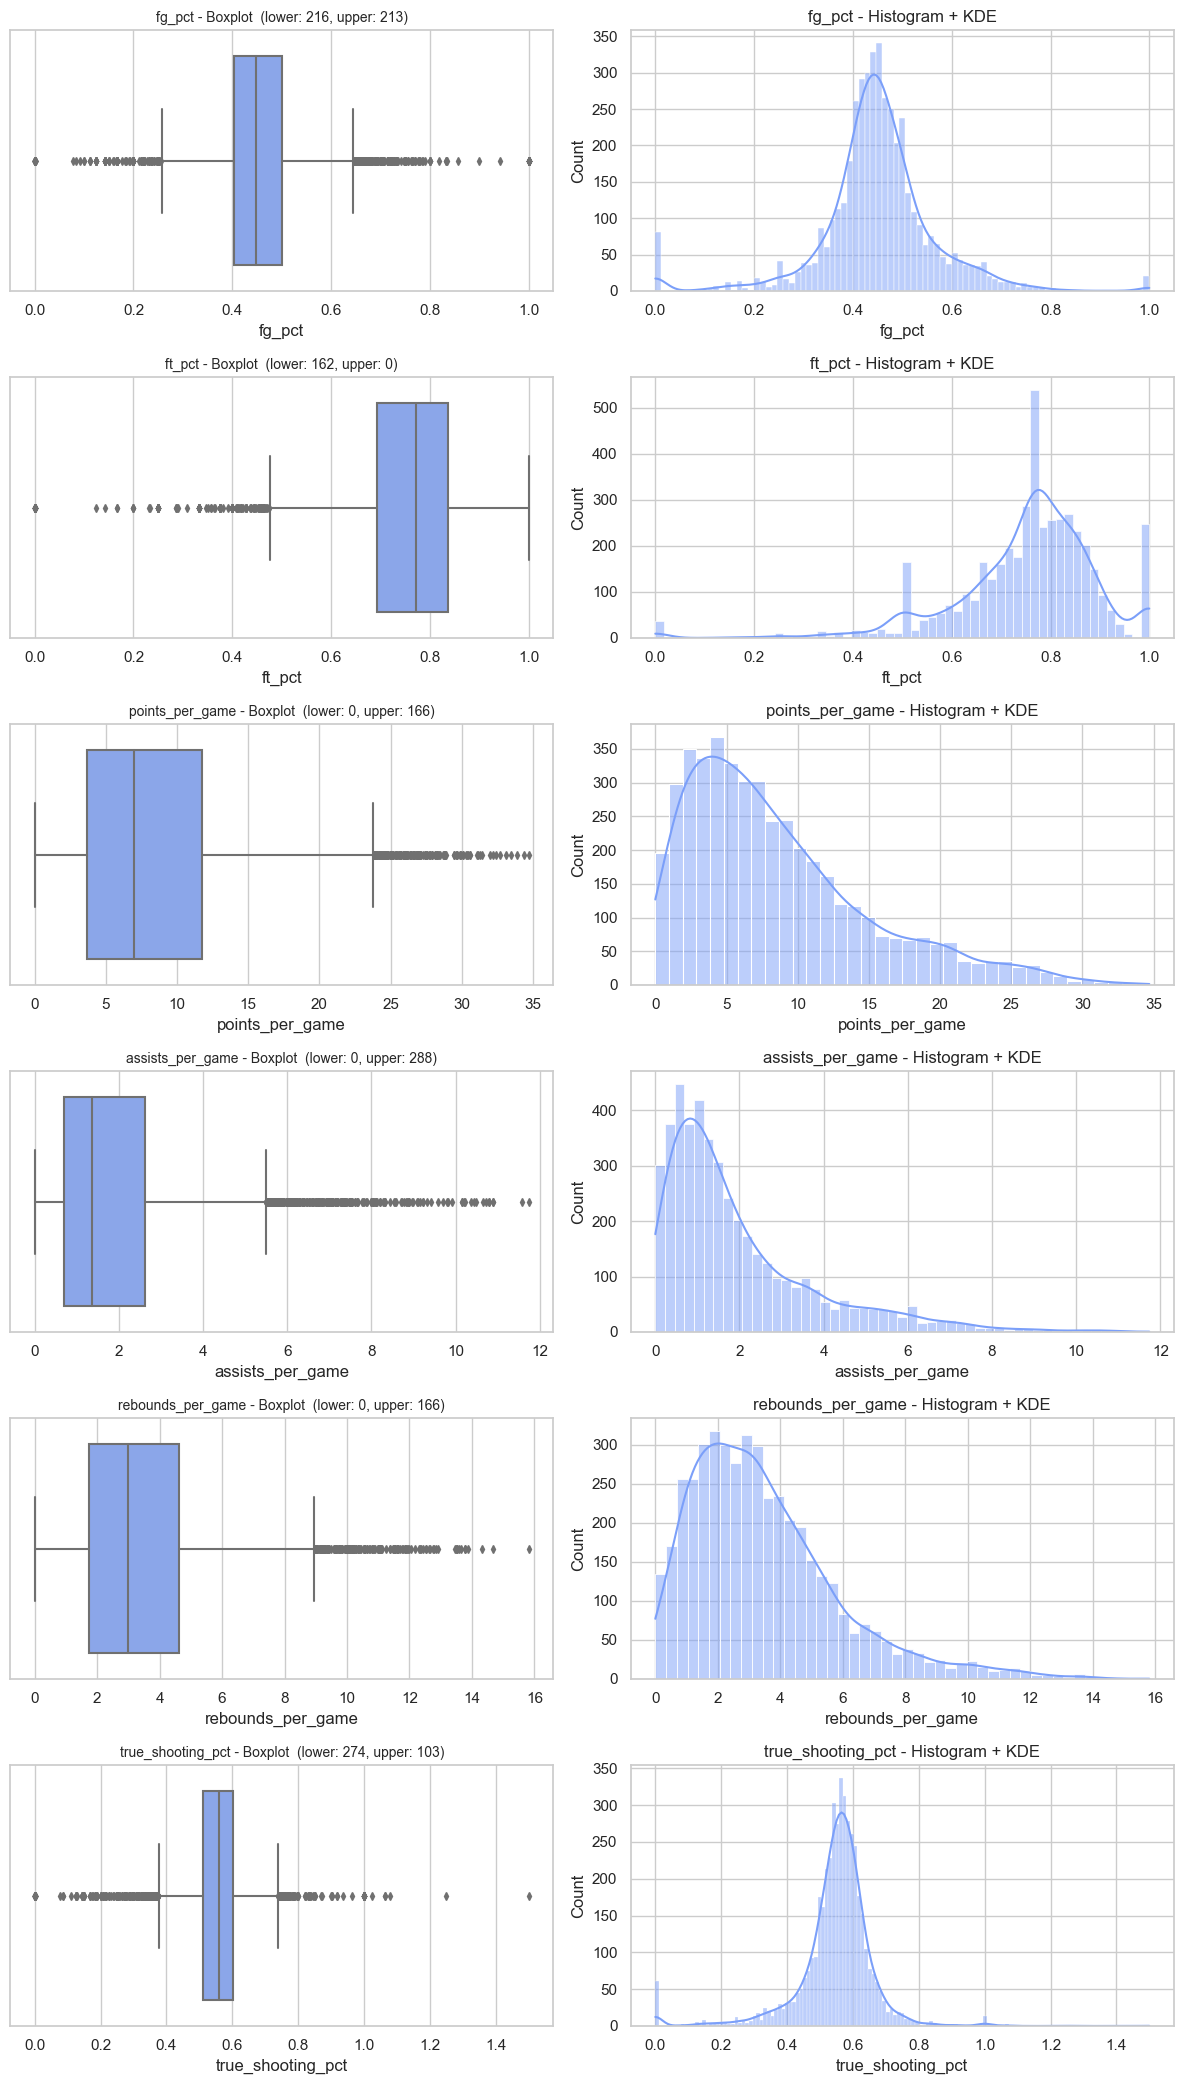

In [44]:
plot_numeric_overview(data, ["fg_pct", "ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game", "true_shooting_pct"], k=1.5)

In [45]:
def plot_categorical_overview(df, categorical_cols, ncols=3, top_n=8):
    n = len(categorical_cols)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        counts = df[col].value_counts(dropna=False)

        # collapse long tails into "Other" so the pie stays readable
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])

        # use the Target palette for binary 0/1 columns, fallback palette otherwise
        if set(counts.index) <= {0, 1}:
            colors = [TARGET_PALETTE[v] for v in counts.index]
        else:
            colors = [FALLBACK_PALETTE[j % len(FALLBACK_PALETTE)] for j in range(len(counts))]

        wedges, _, autotexts = ax.pie(
            counts,
            labels=counts.index.astype(str),
            autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
            colors=colors,
            startangle=90,
            pctdistance=0.78,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
            textprops=dict(fontsize=9),
        )
        for t in autotexts:
            t.set_color("white")
            t.set_fontweight("bold")

        ax.set_title(col, fontsize=12, fontweight="bold", y=1.0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Categorical Columns Overview", fontsize=16, fontweight="bold")
    plt.tight_layout(pad=1.5, w_pad=2.5, h_pad=1.5, rect=[0, 0, 1, 0.97])
    plt.show()

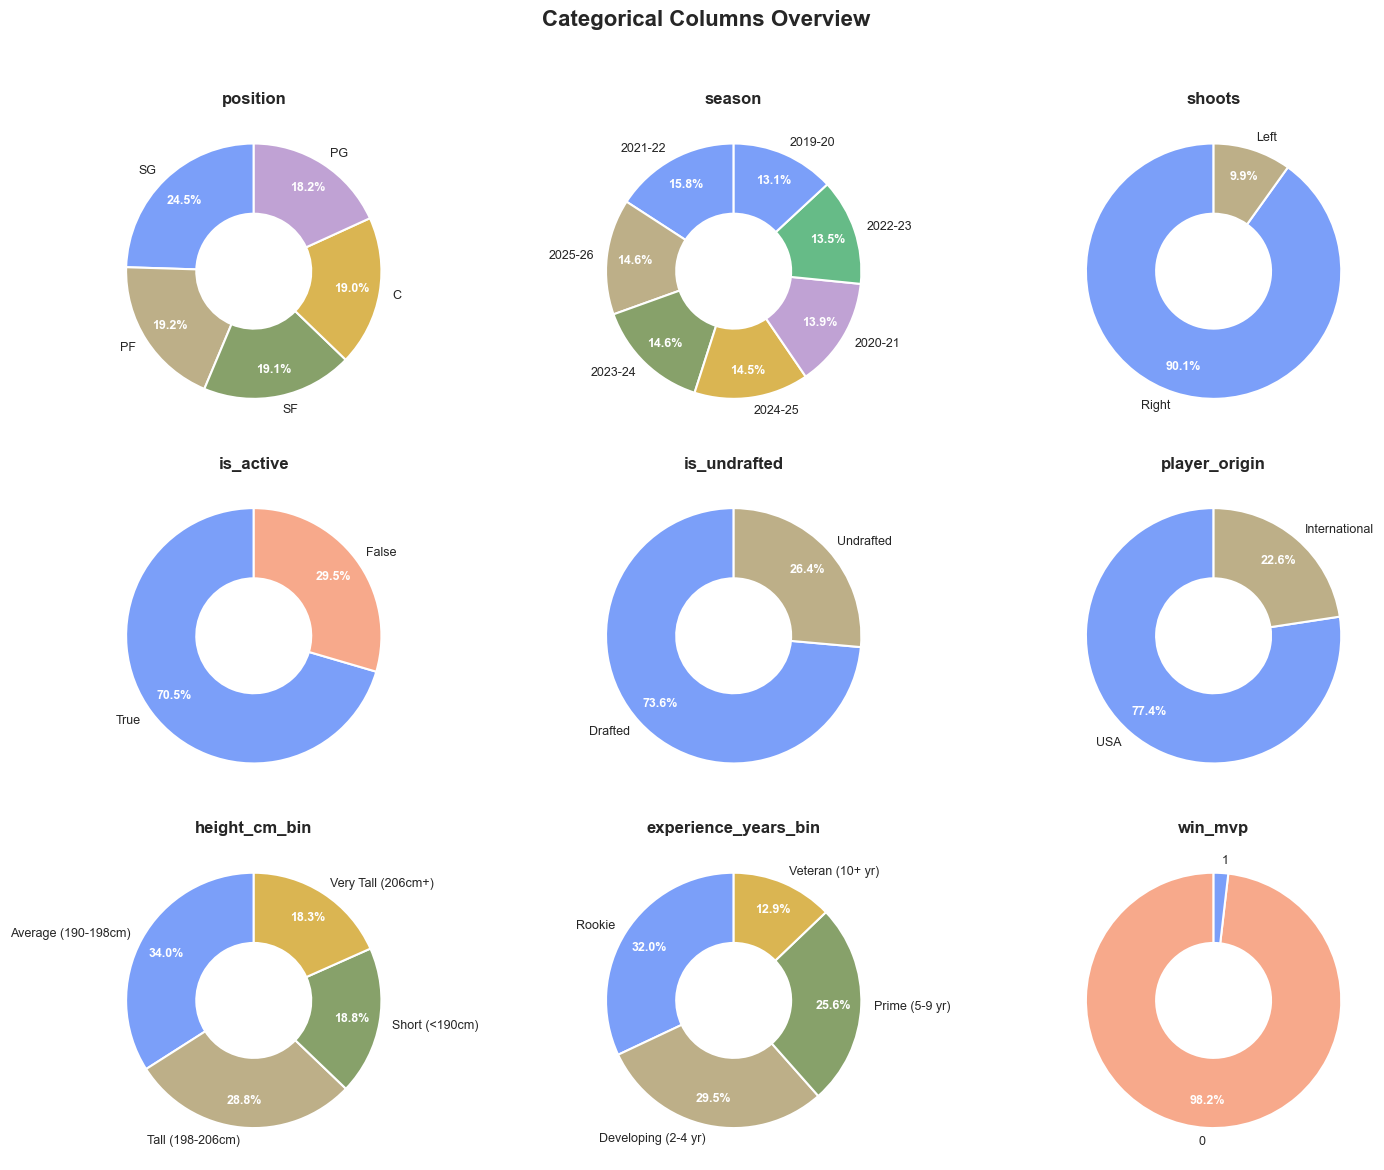

In [46]:
plot_categorical_overview(data, categorical_columns_pp)

## Correlation Overview

#### For numeric columns

In [47]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(20,10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
                annot_kws={"size": 10})
    plt.title(f"Correlation Heatmap: {method}")
    plt.tight_layout()
    plt.show()

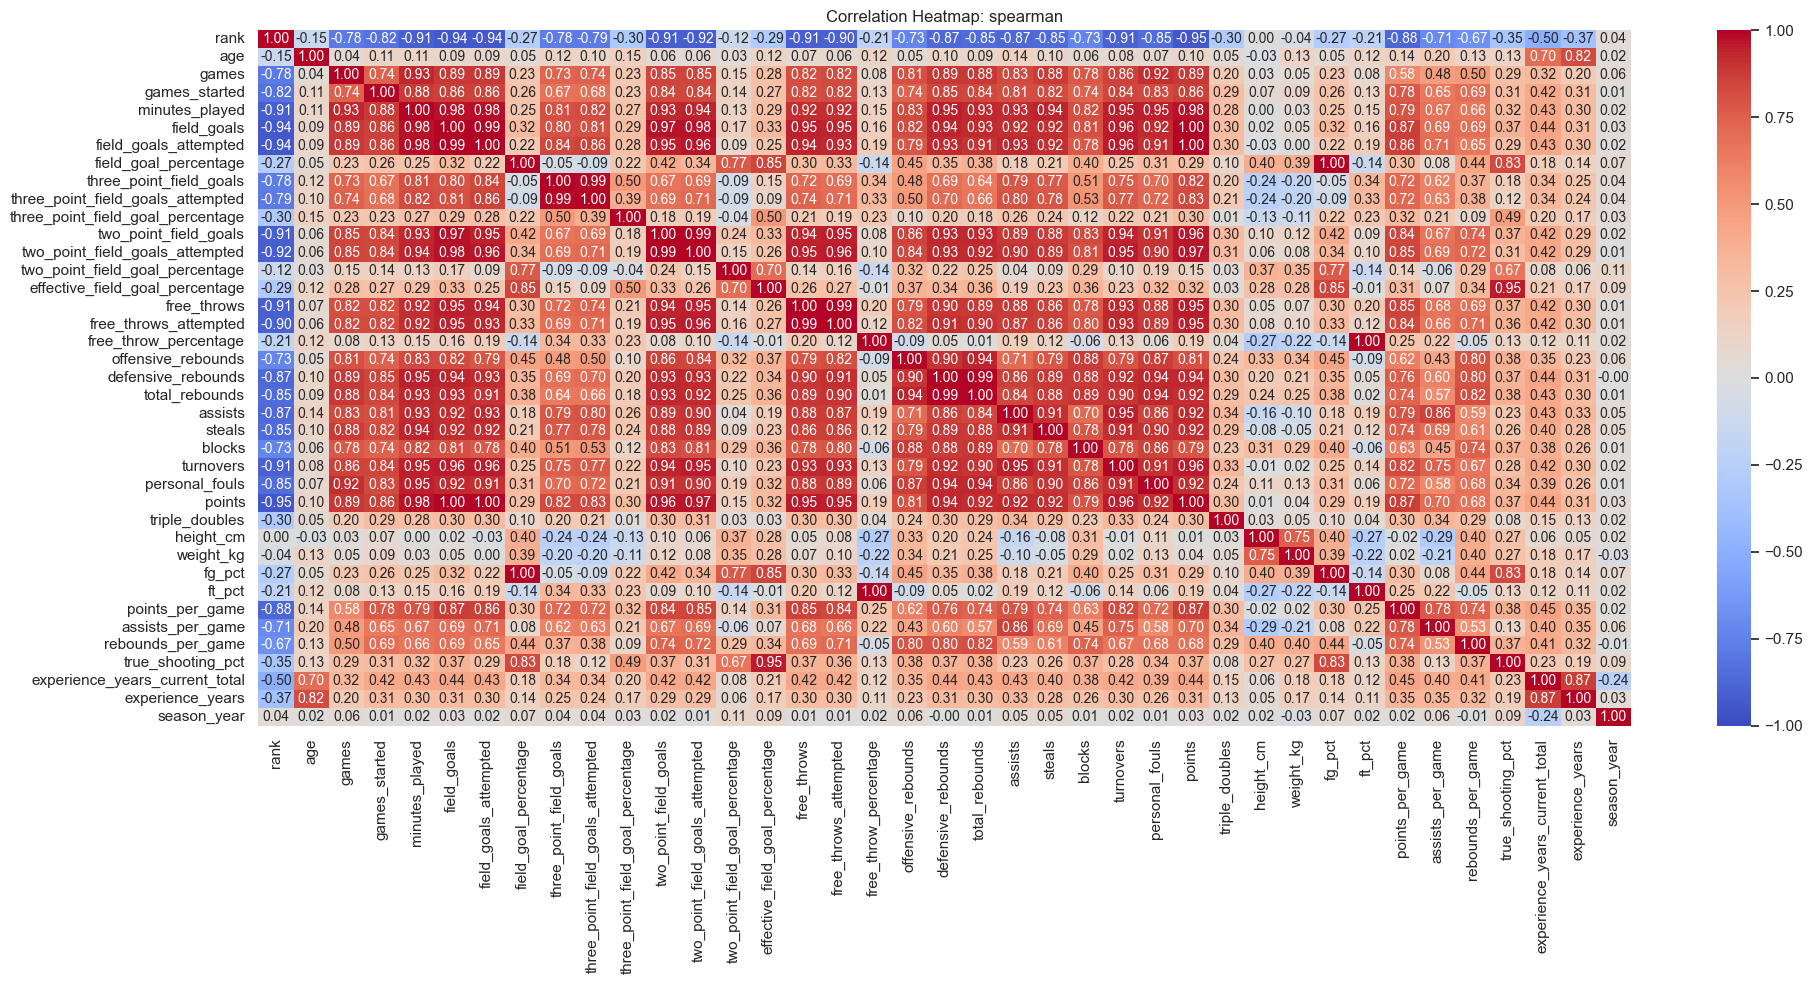

In [48]:
corr_heatmap(data[numeric_columns_pp], method="spearman")

## Two-variable comparison

### Numeric vs Categorical Plot

In [49]:
def numeric_vs_categorical_plot(df, col, target="win_mvp"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{col} by {target}", fontsize=14, fontweight="bold")

    target_values = sorted(df[target].dropna().unique())
    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    sns.histplot(data=df, x=col, hue=target, multiple="stack", palette=palette, ax=axes[0])
    axes[0].set_title("Stacked count")

    sns.histplot(data=df, x=col, hue=target, multiple="fill", palette=palette, ax=axes[1])
    axes[1].set_title("Proportion")

    sns.boxplot(data=df, x=target, y=col, palette=palette, ax=axes[2])
    axes[2].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

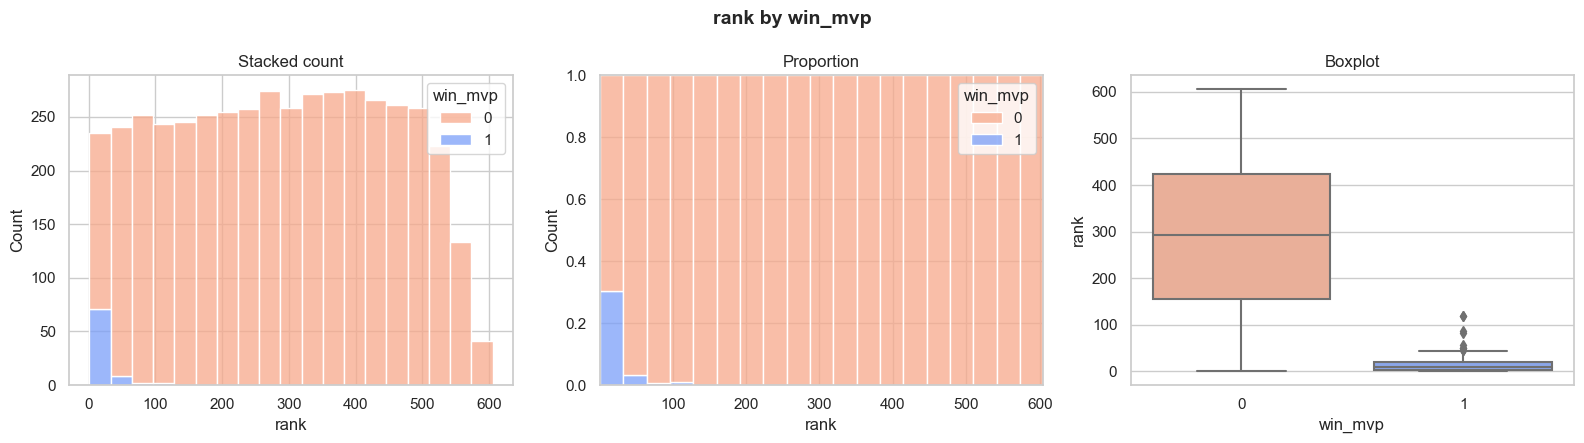

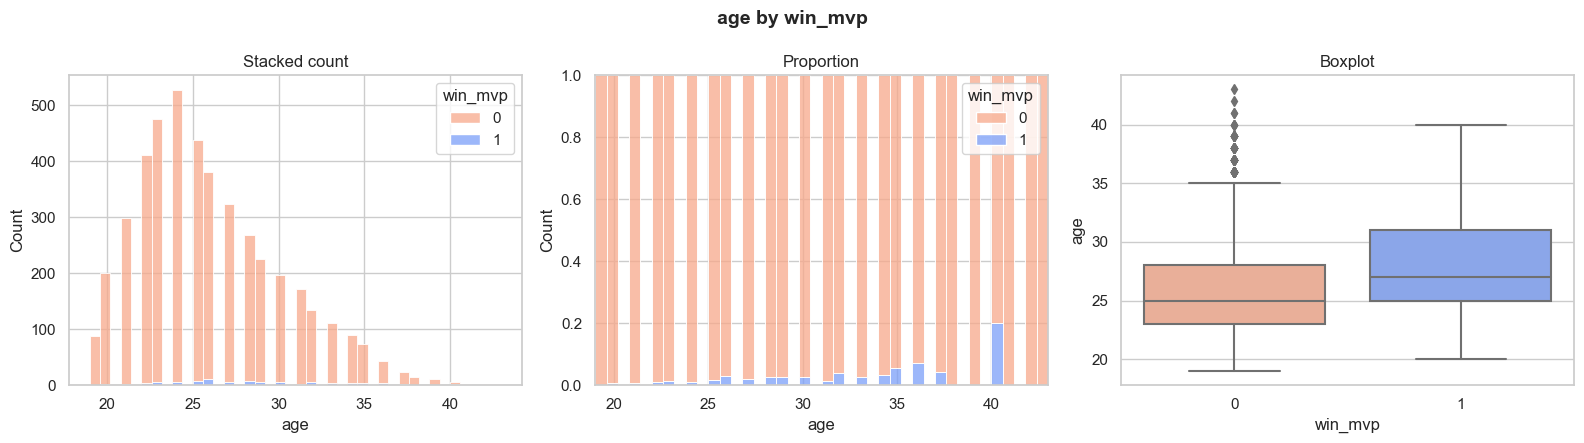

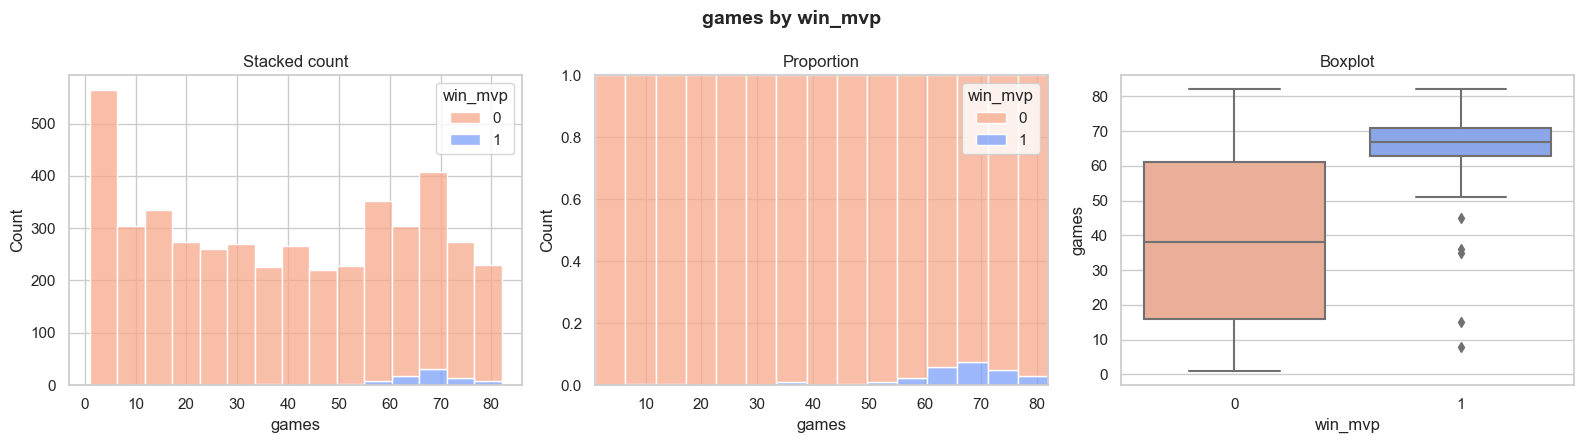

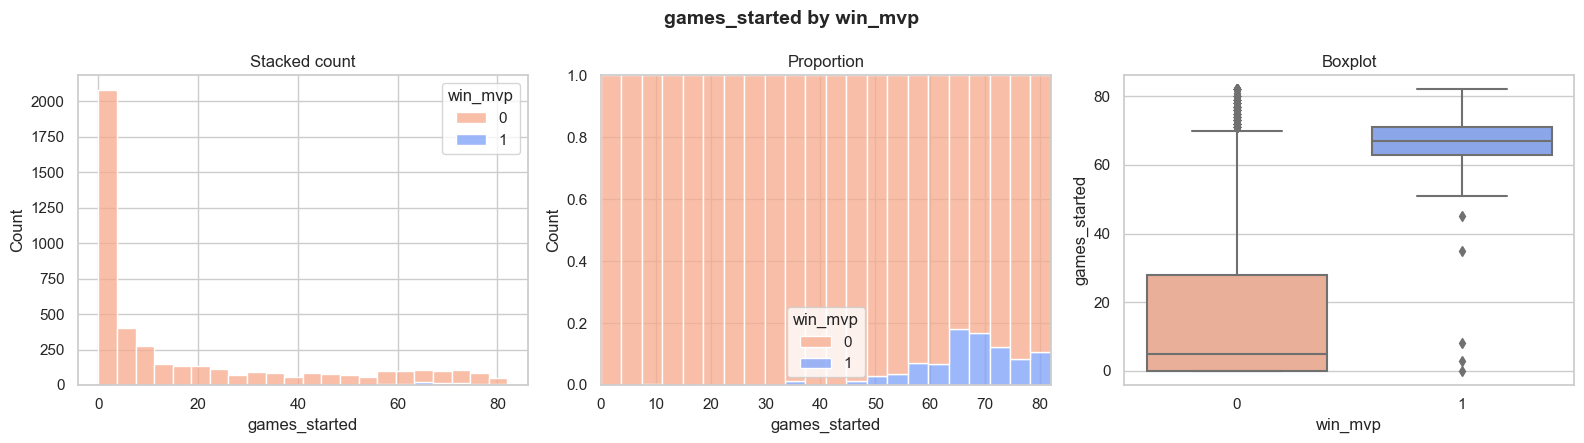

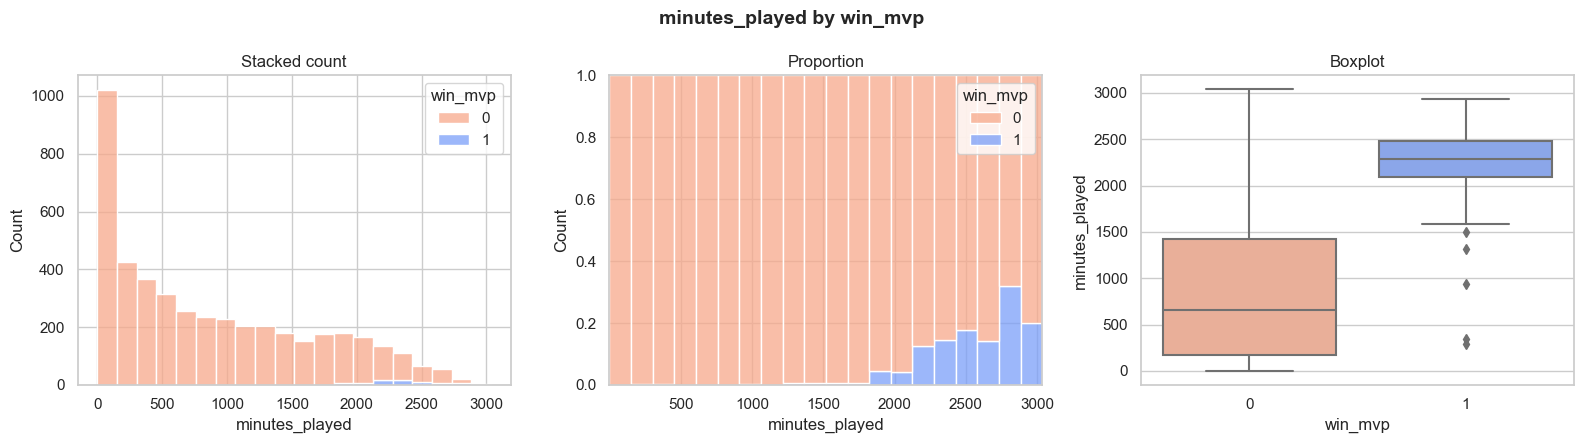

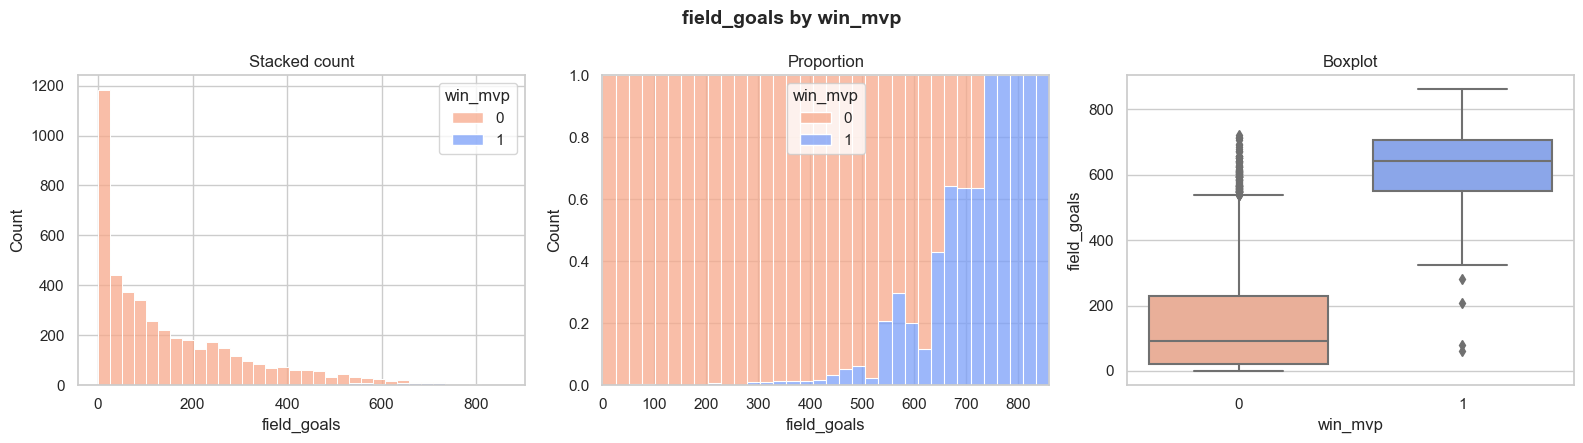

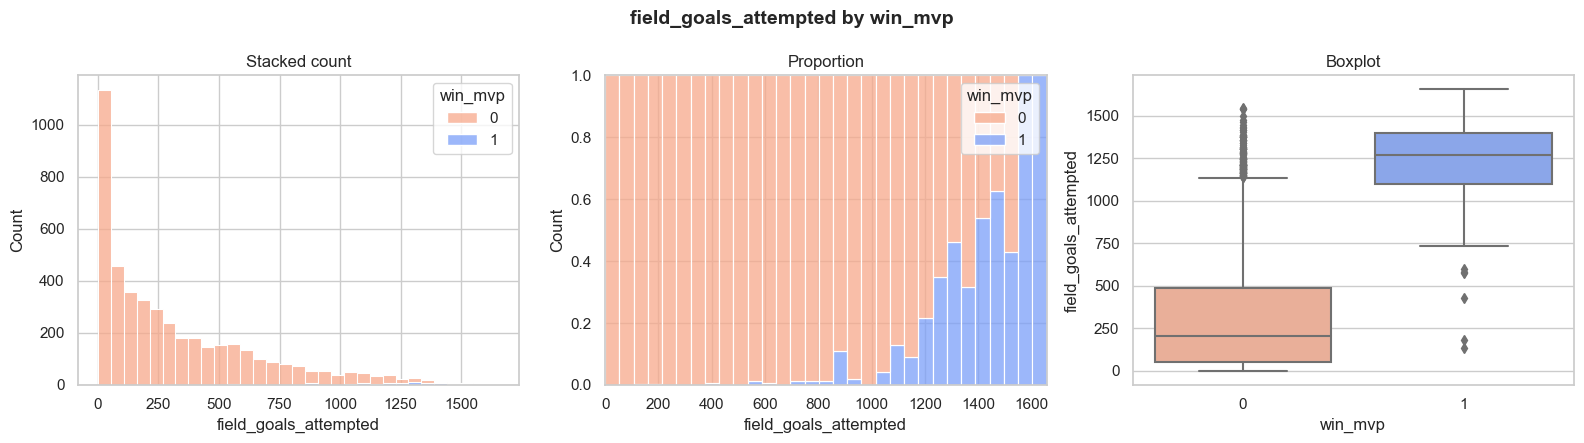

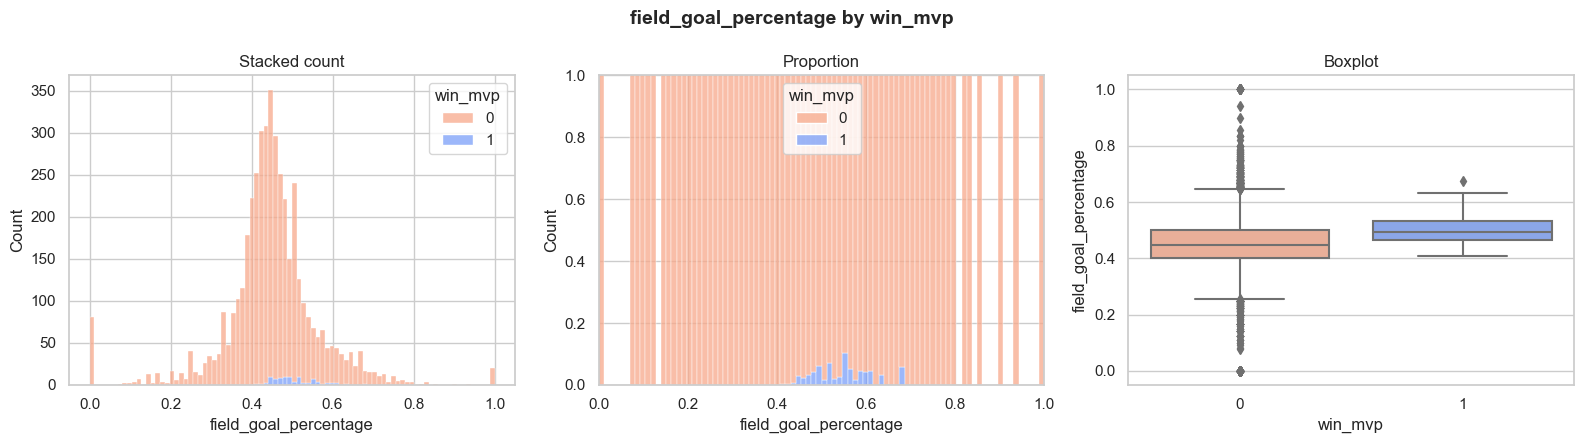

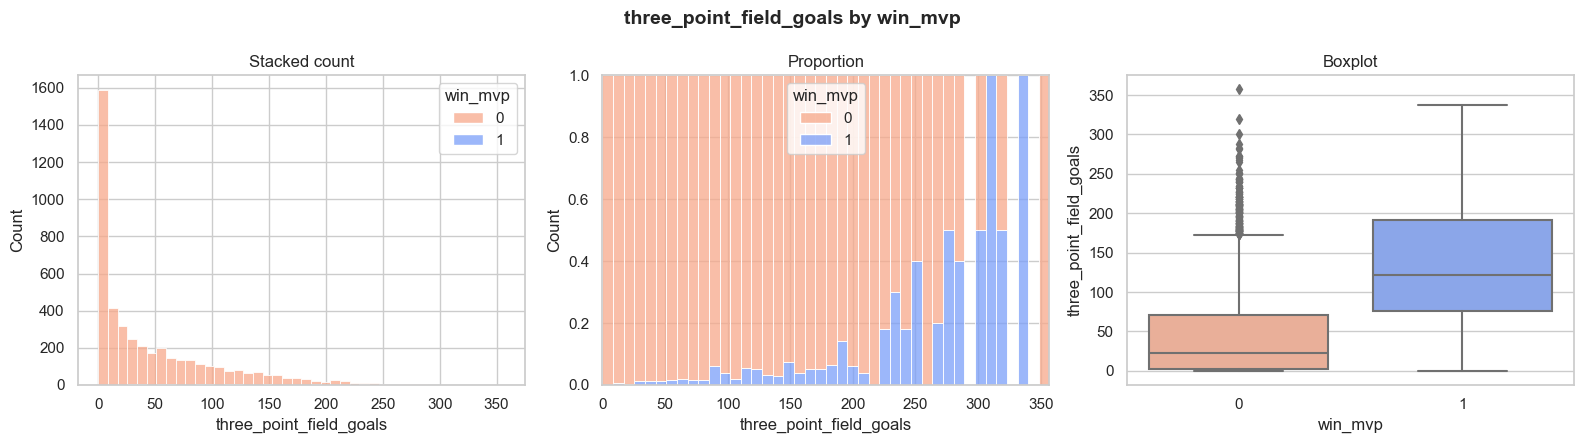

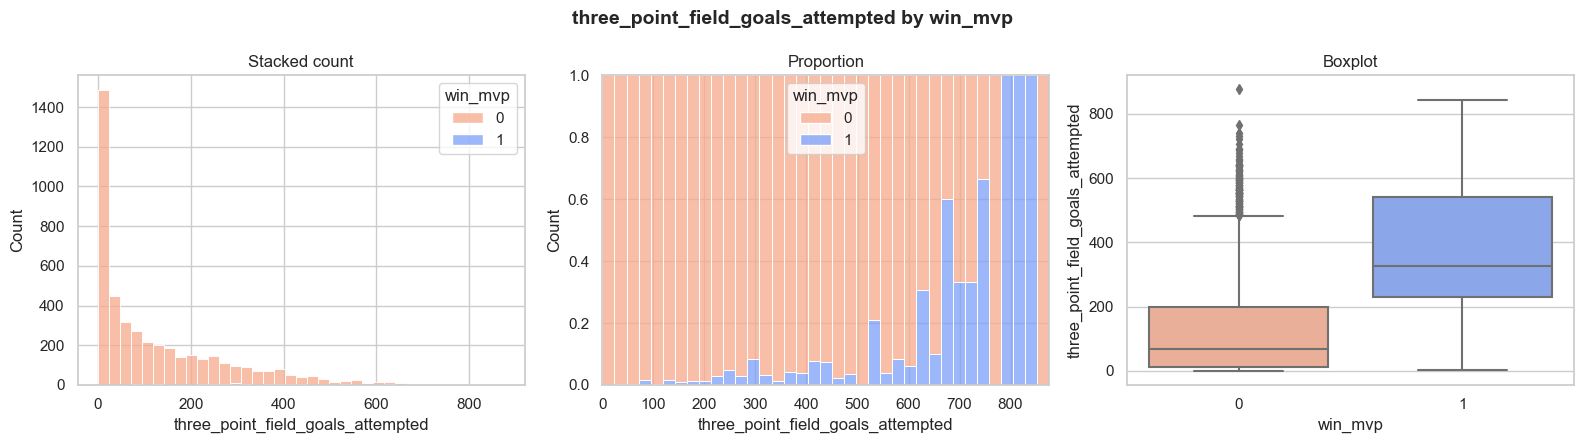

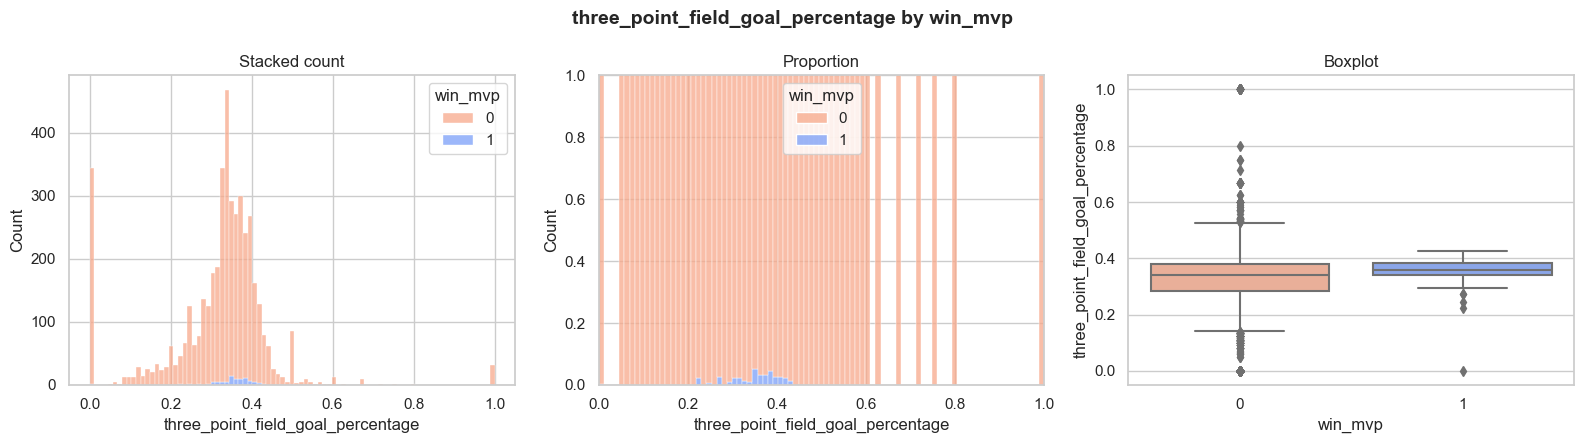

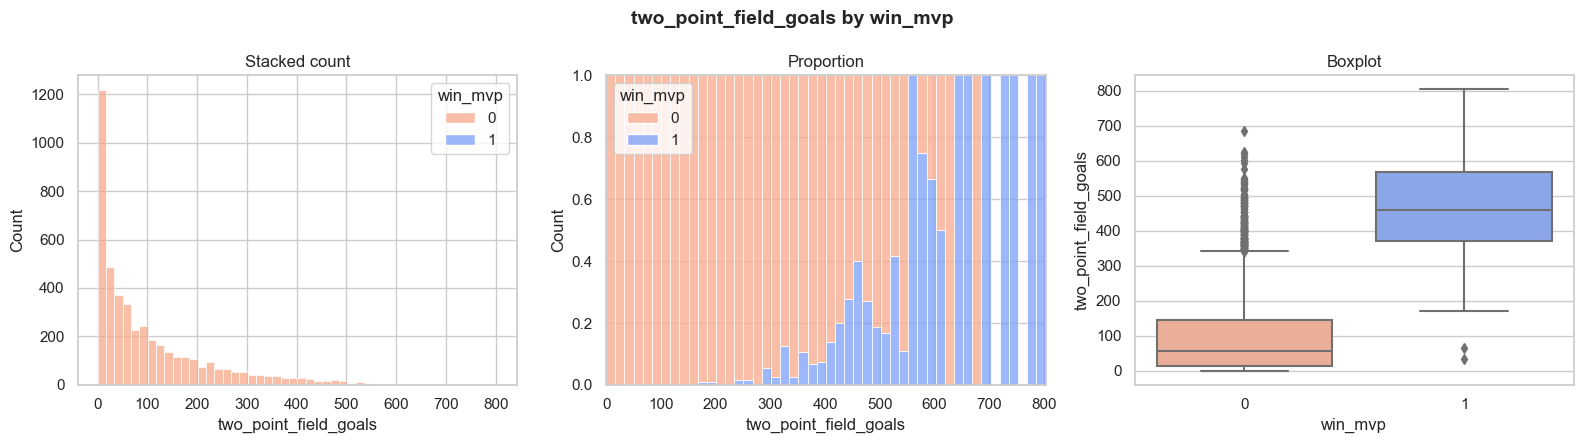

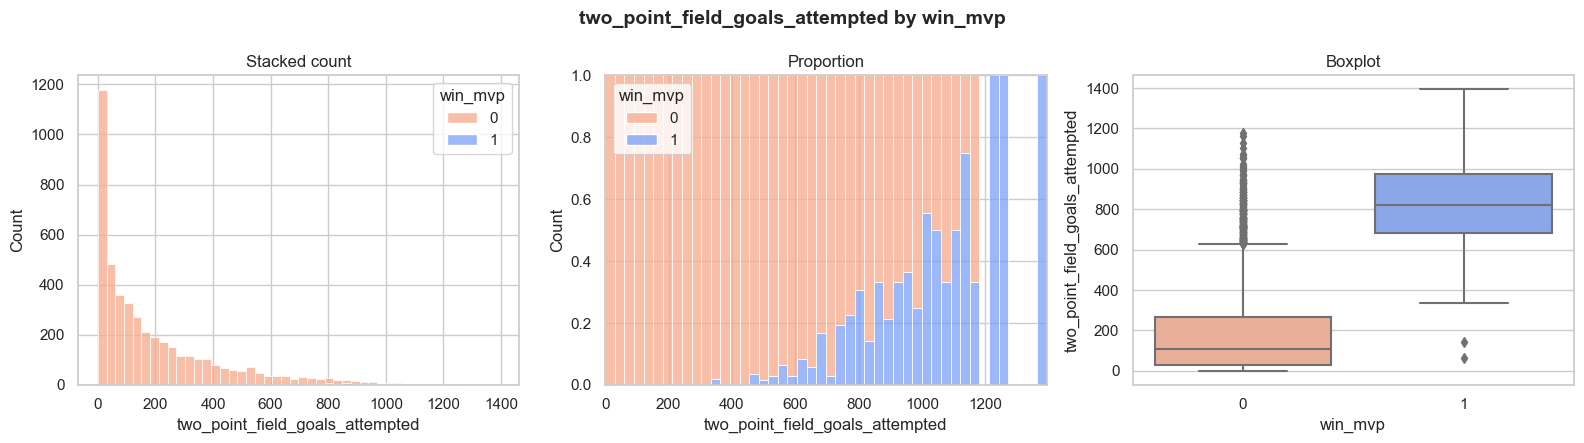

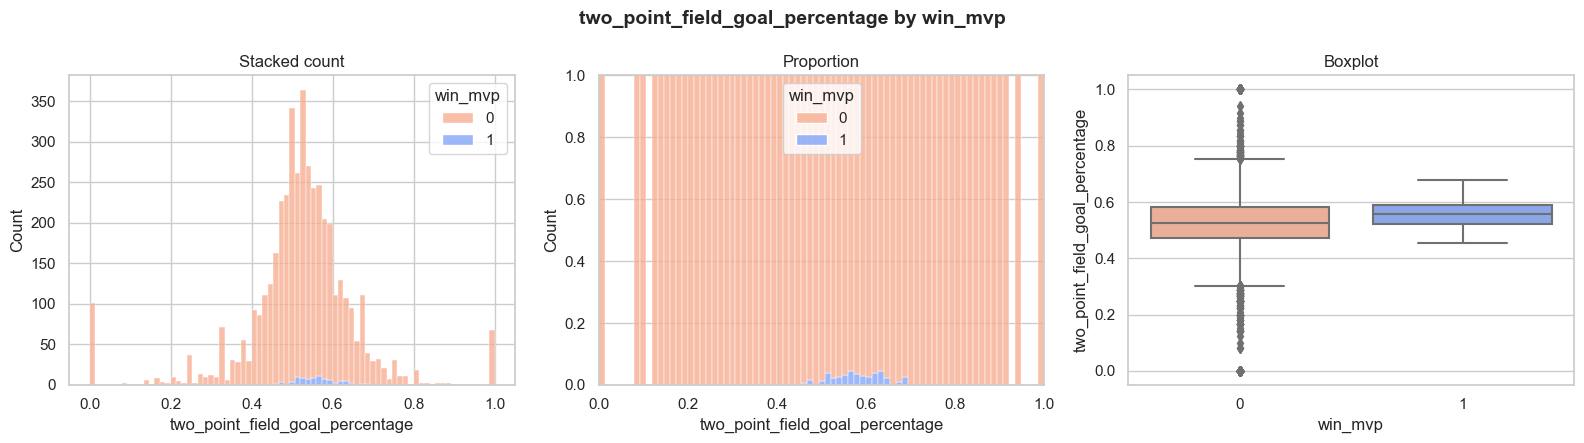

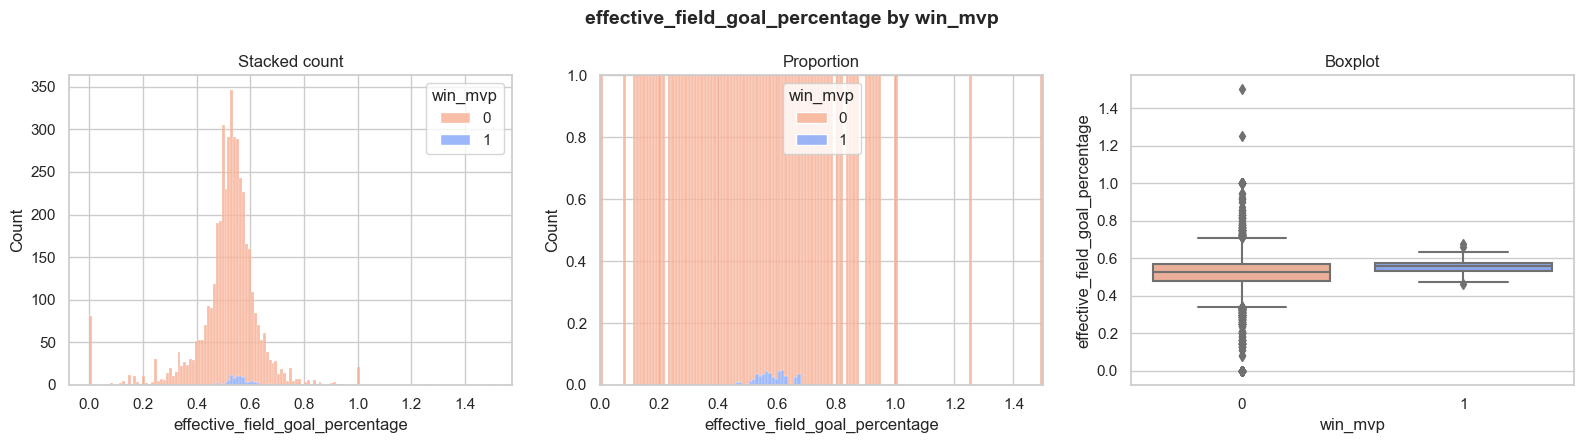

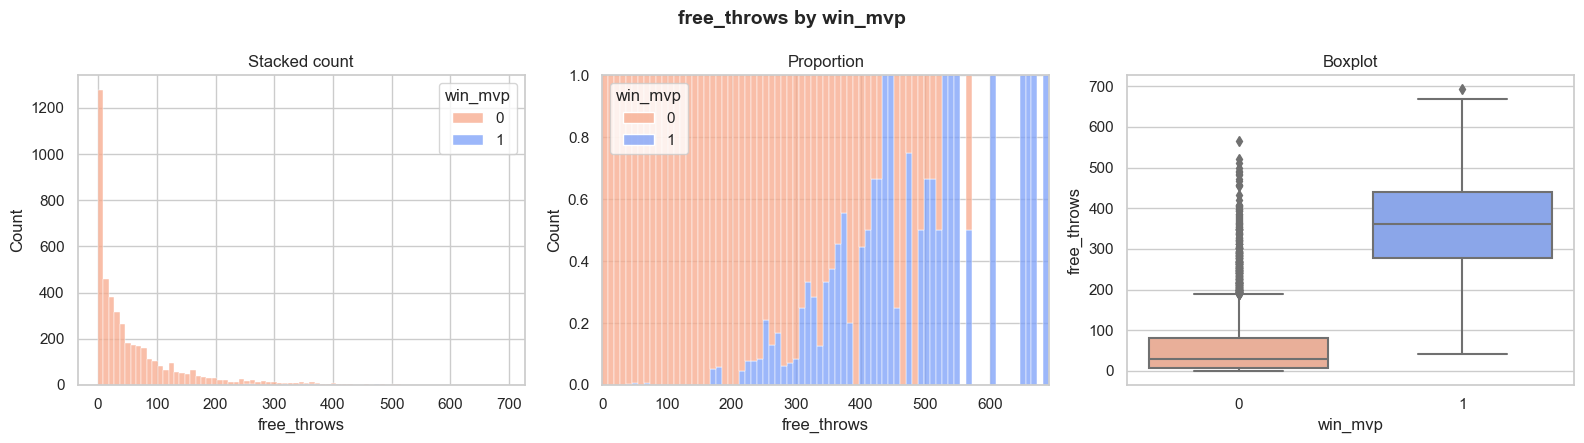

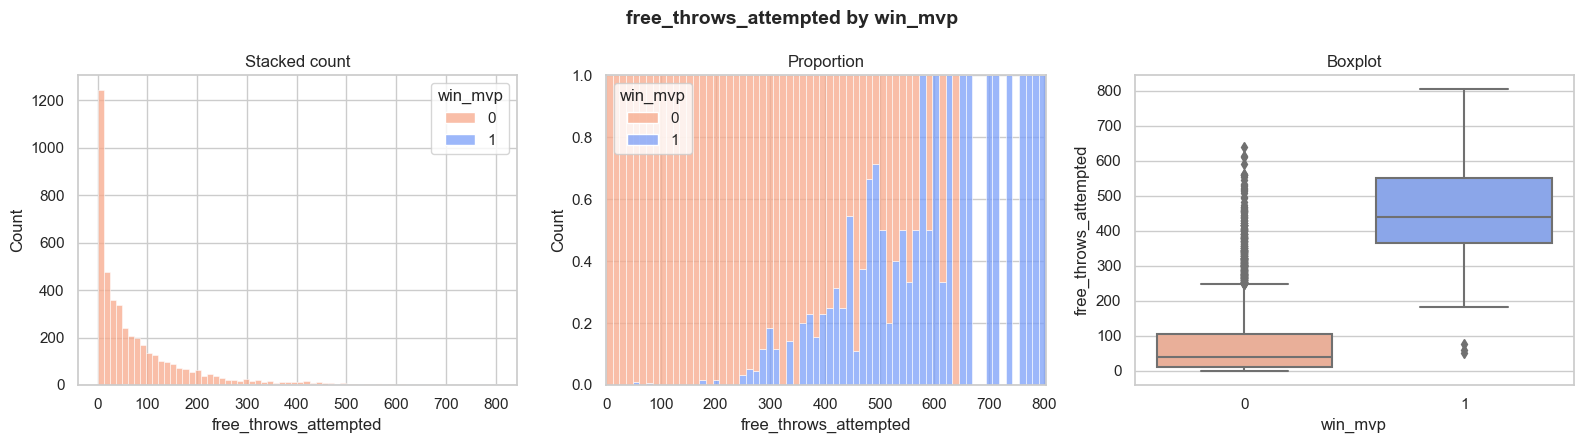

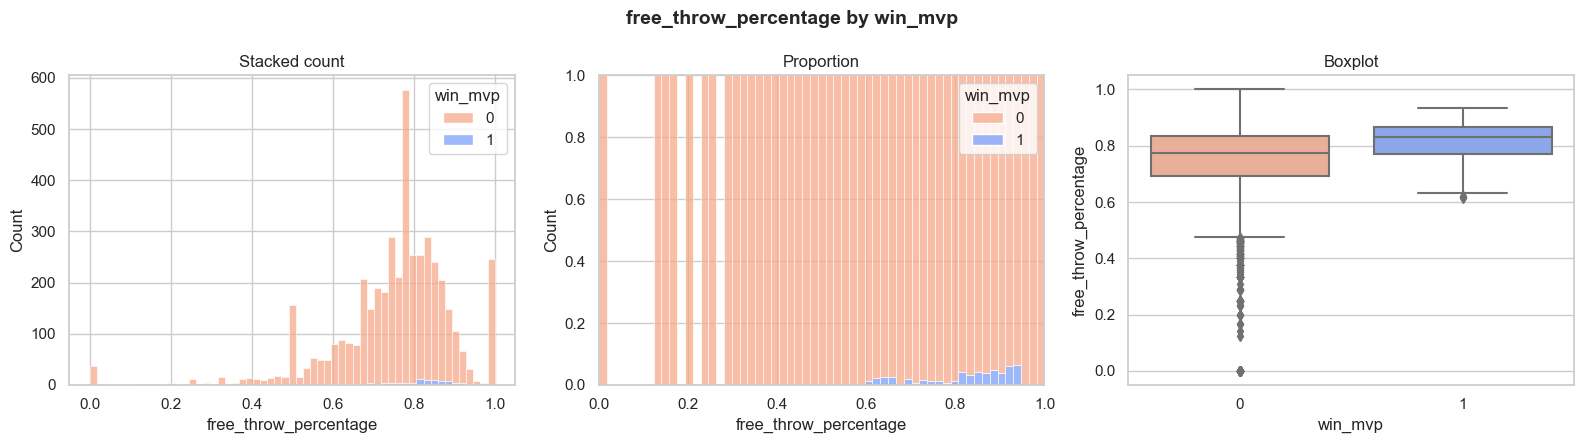

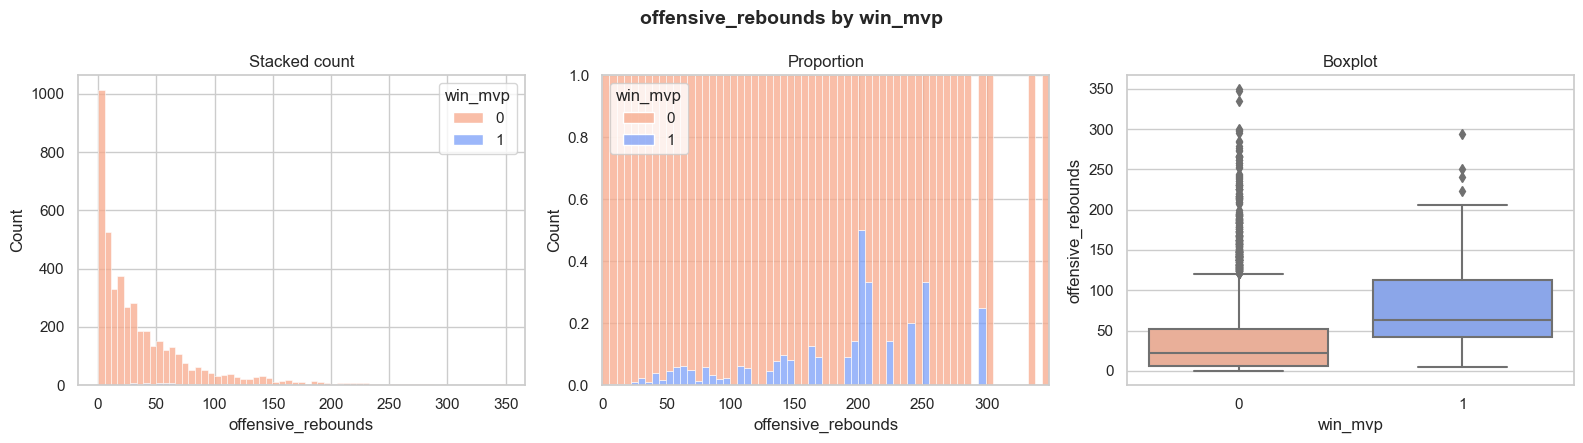

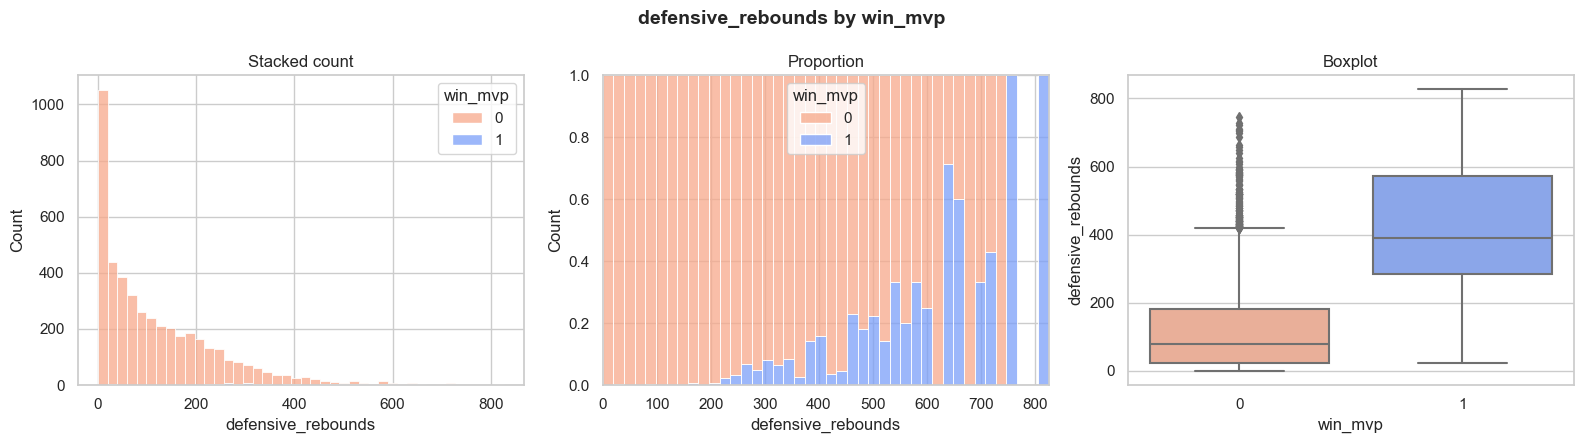

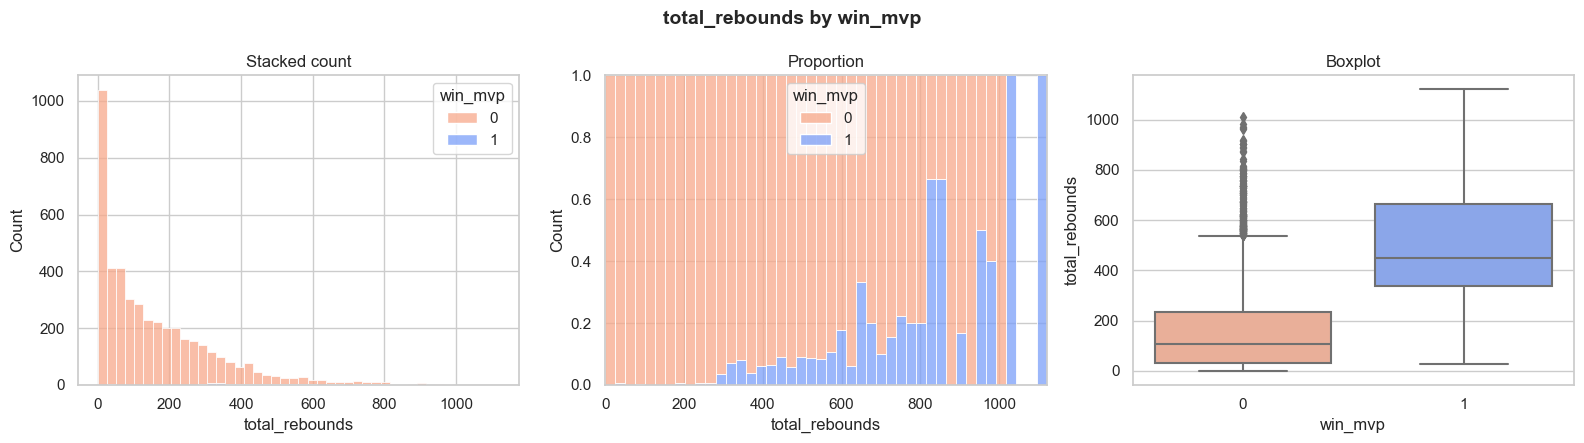

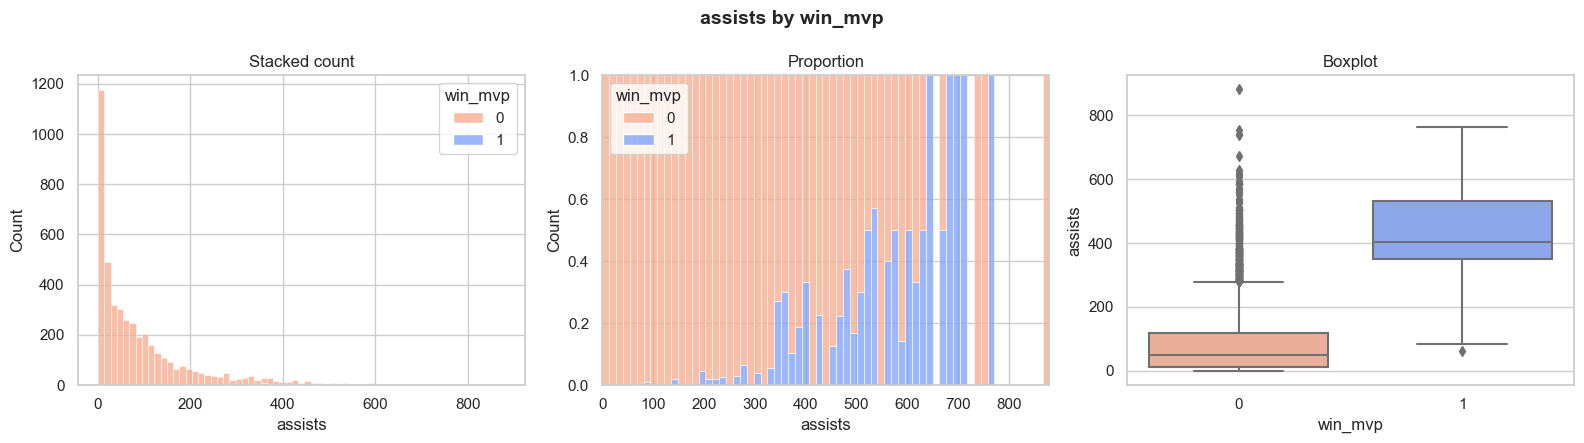

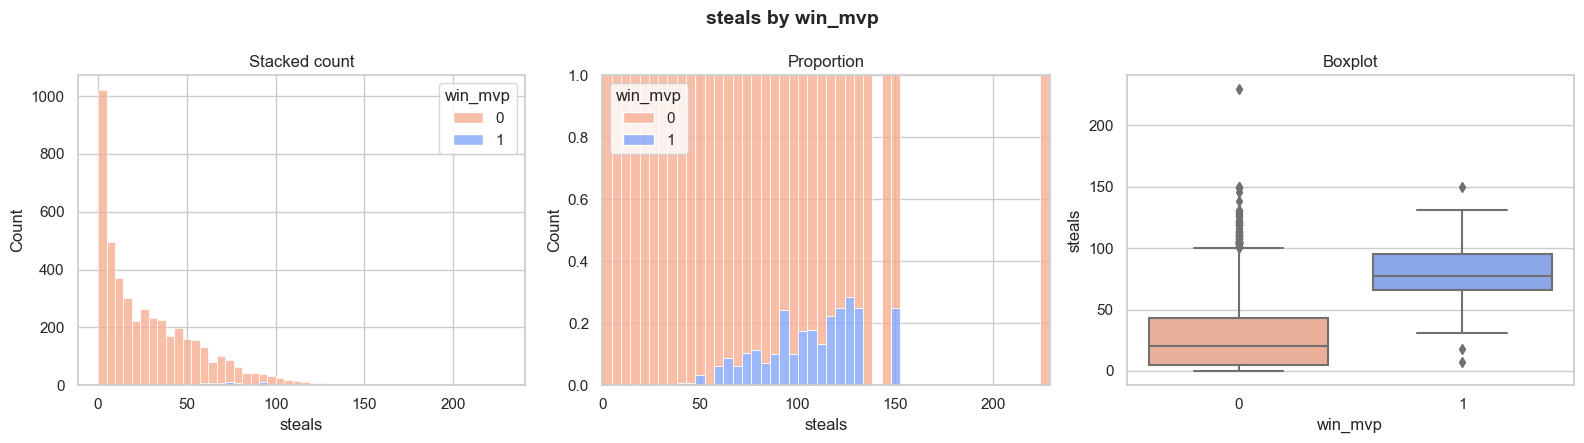

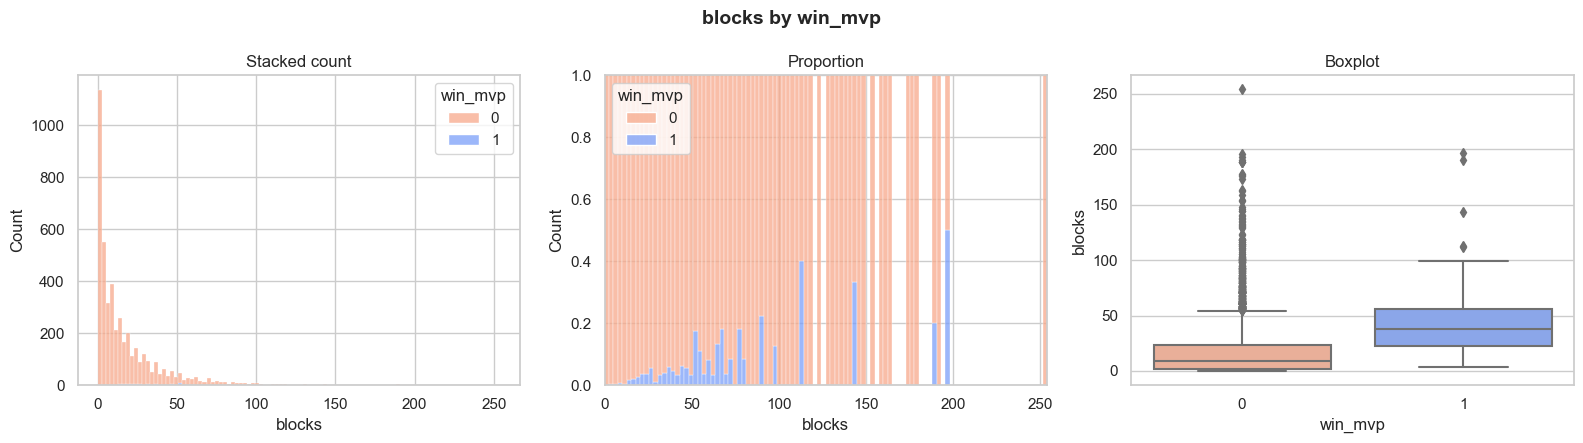

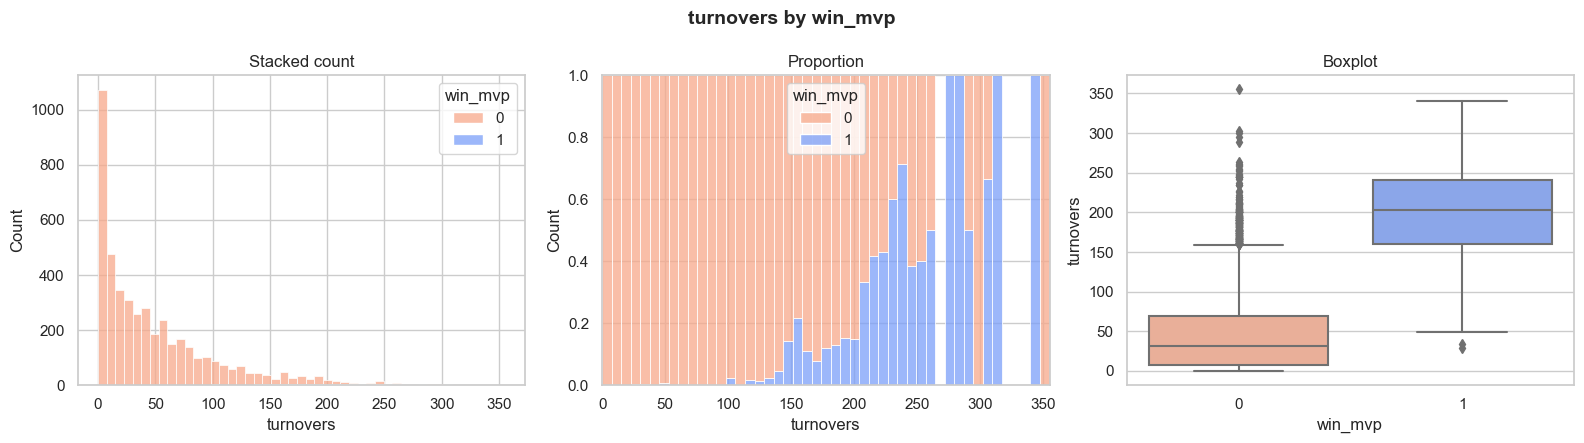

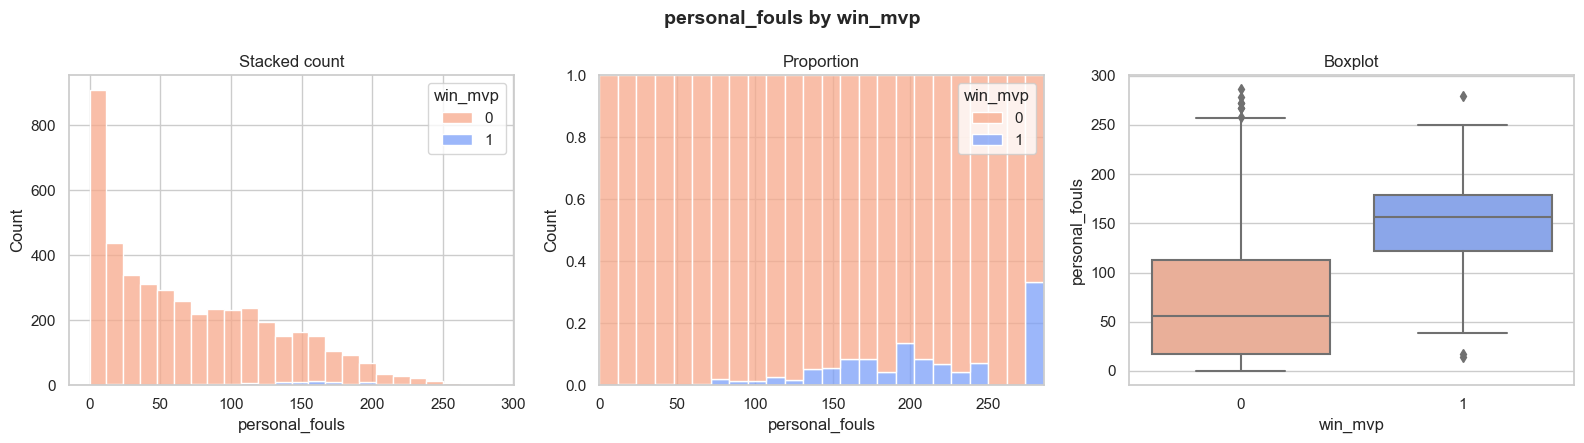

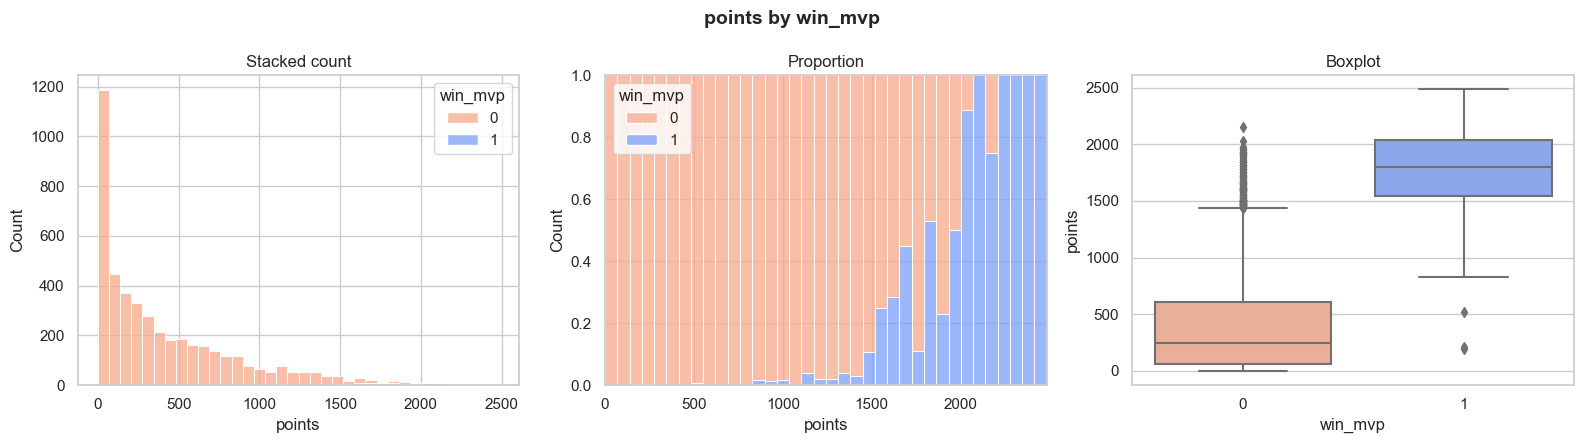

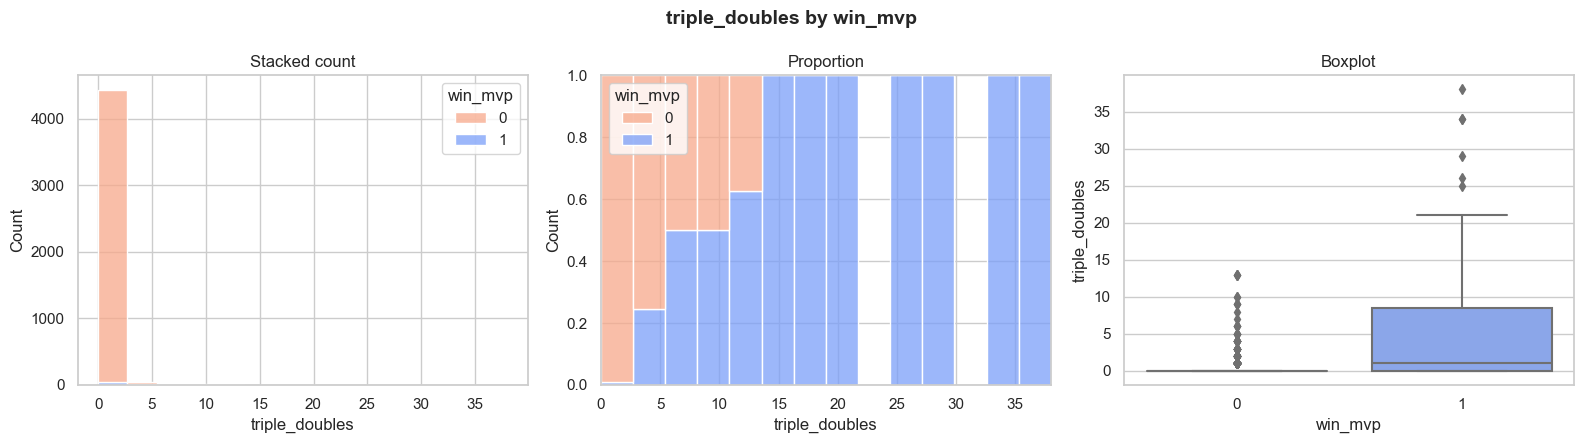

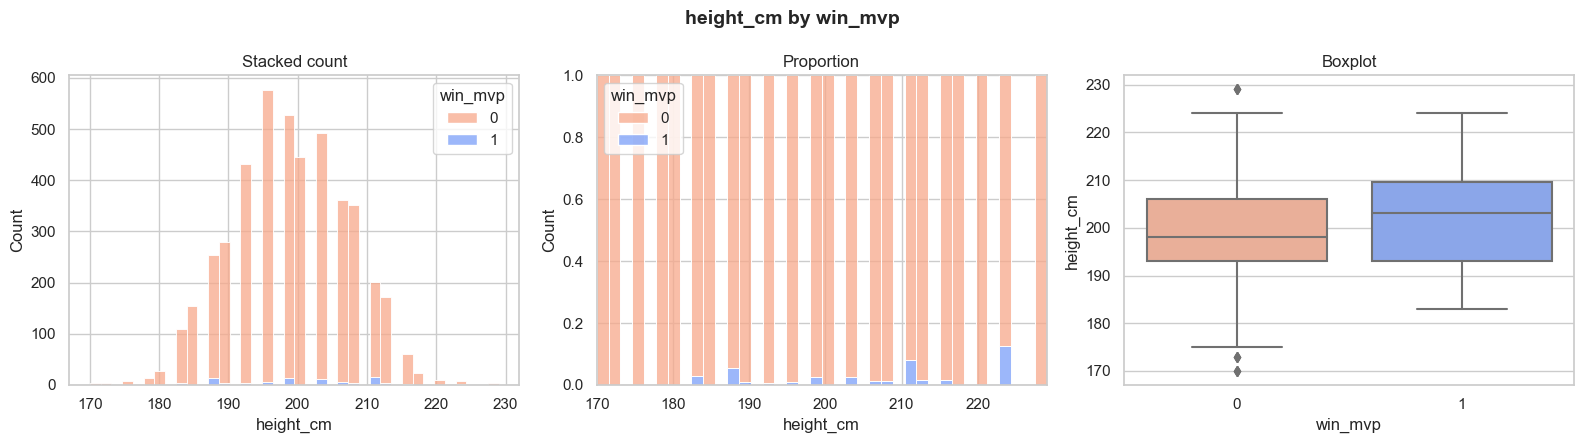

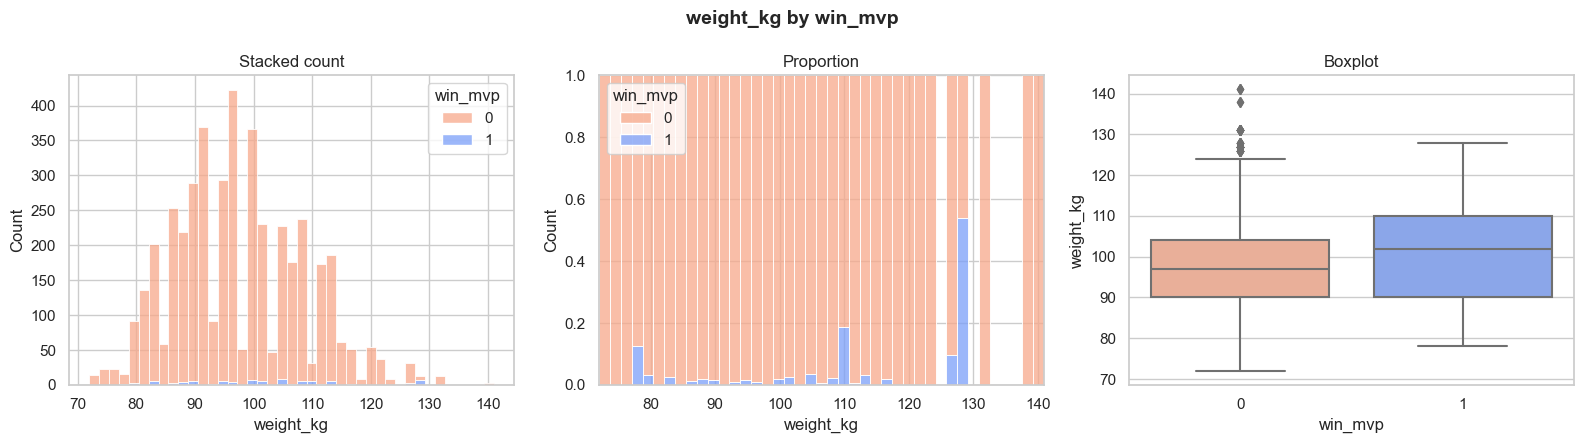

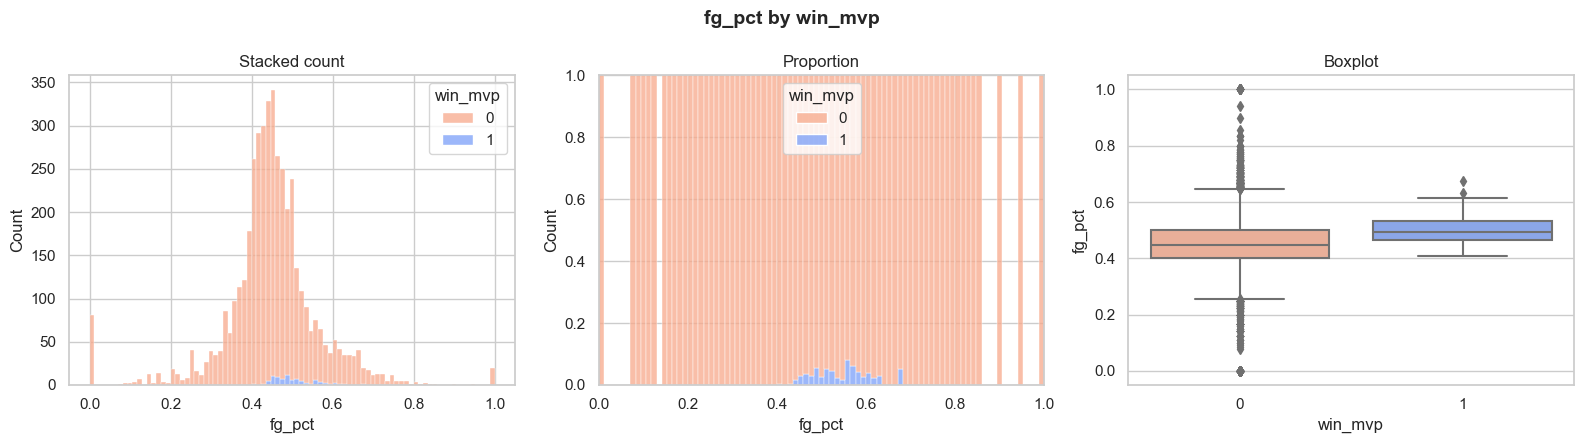

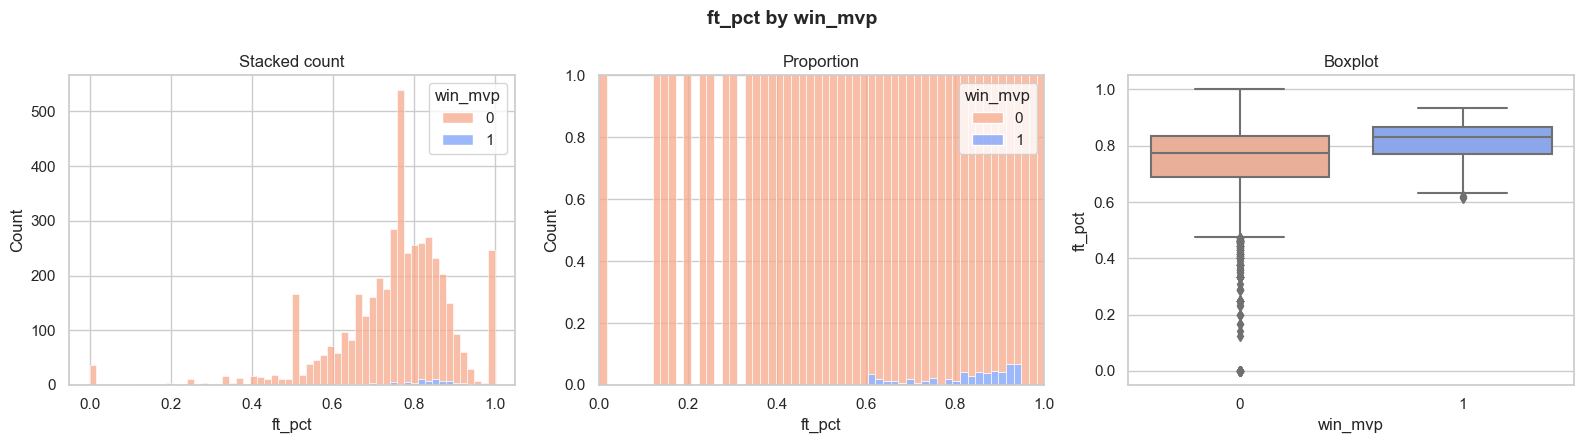

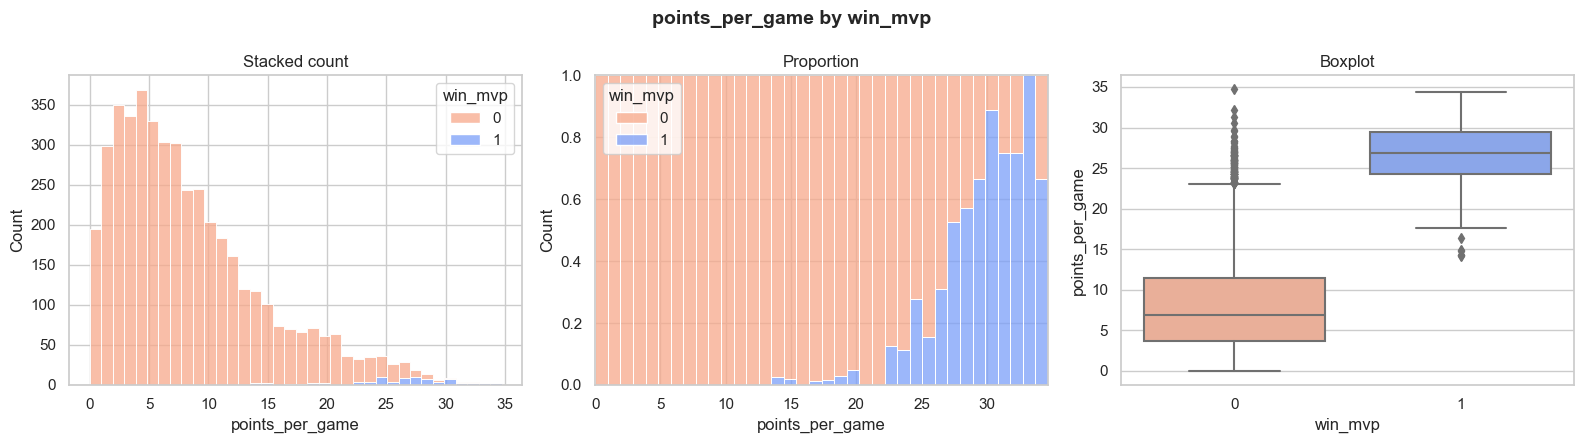

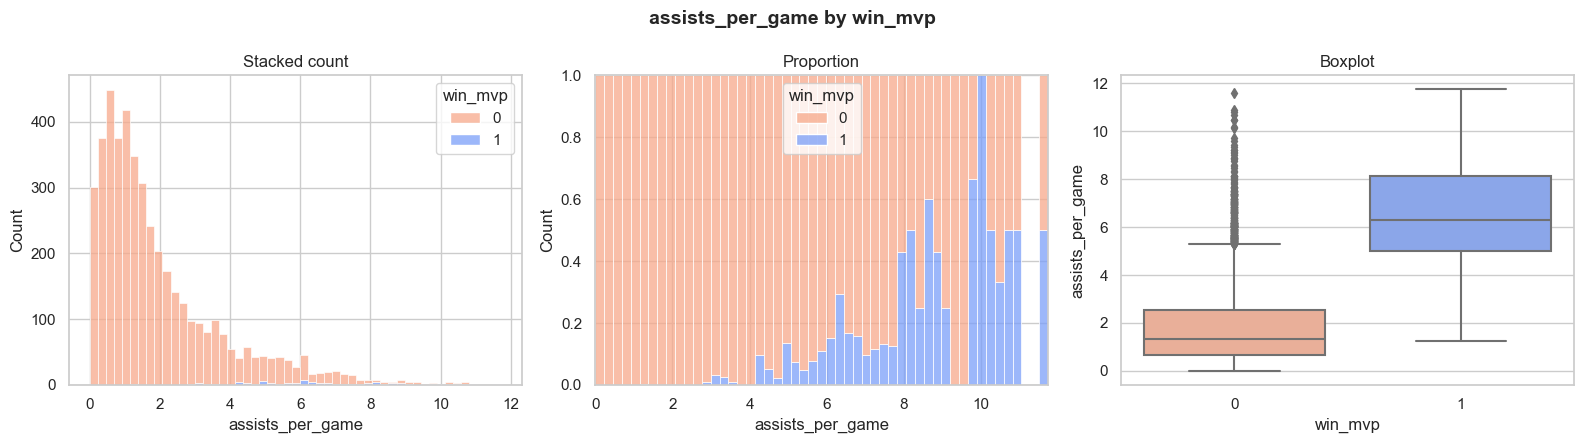

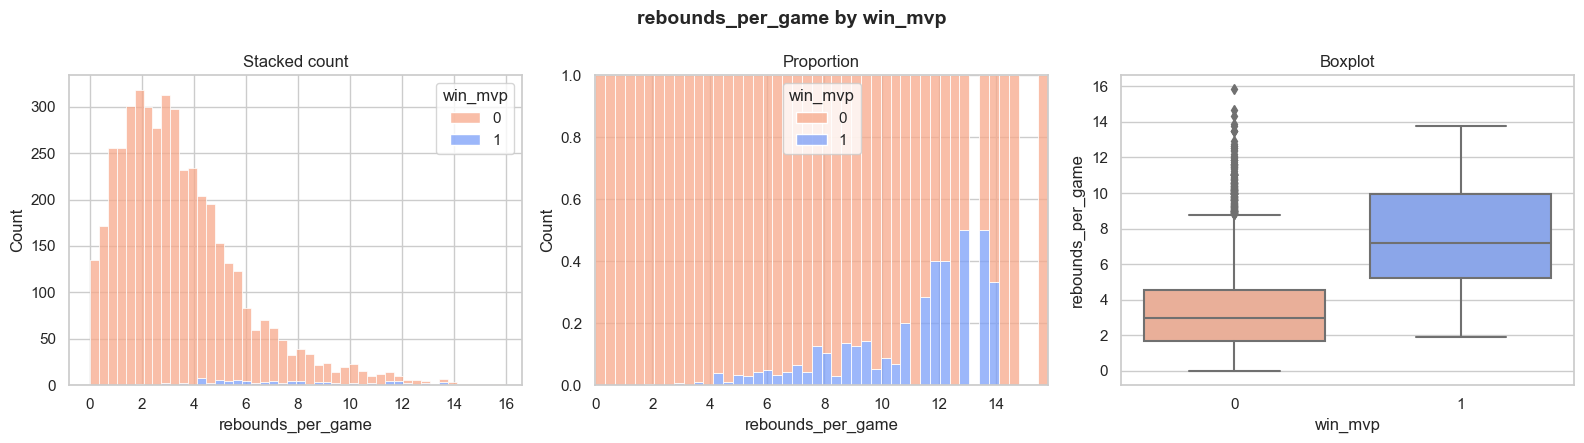

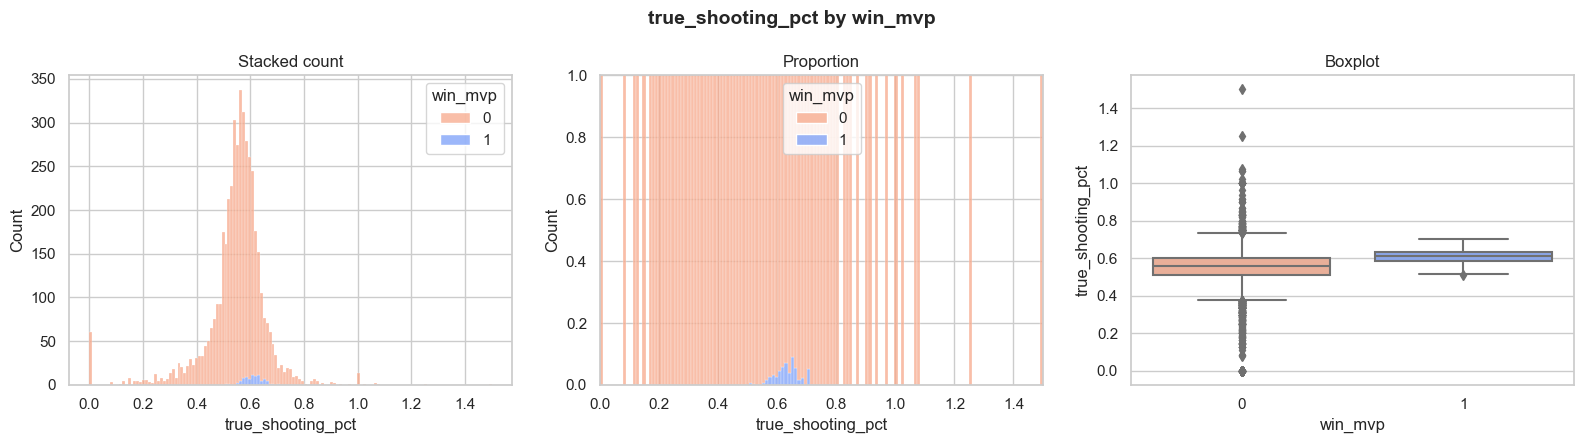

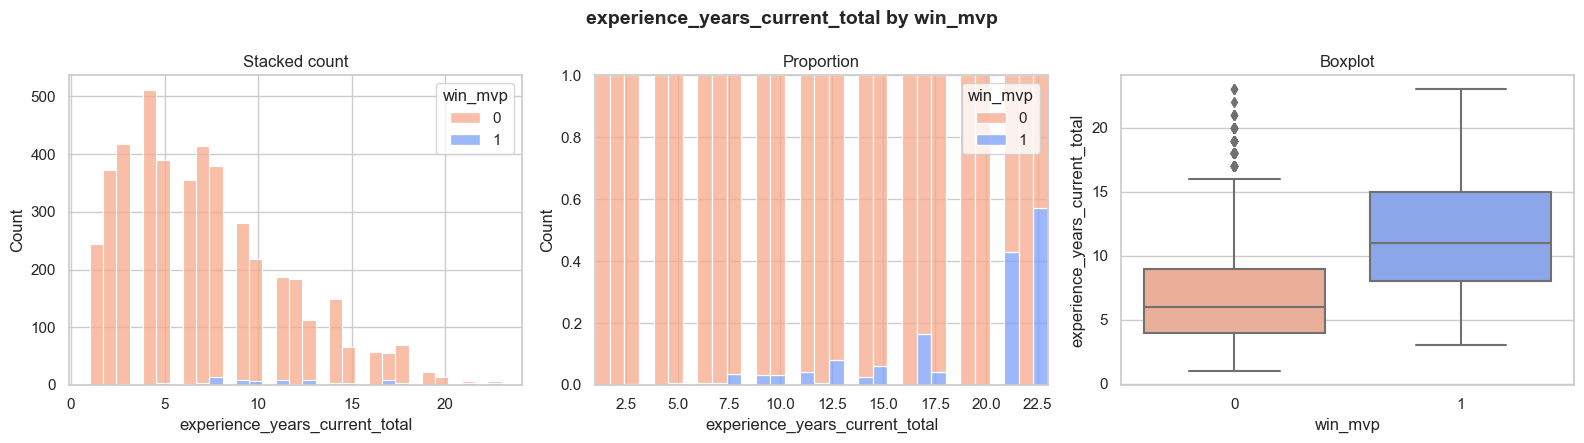

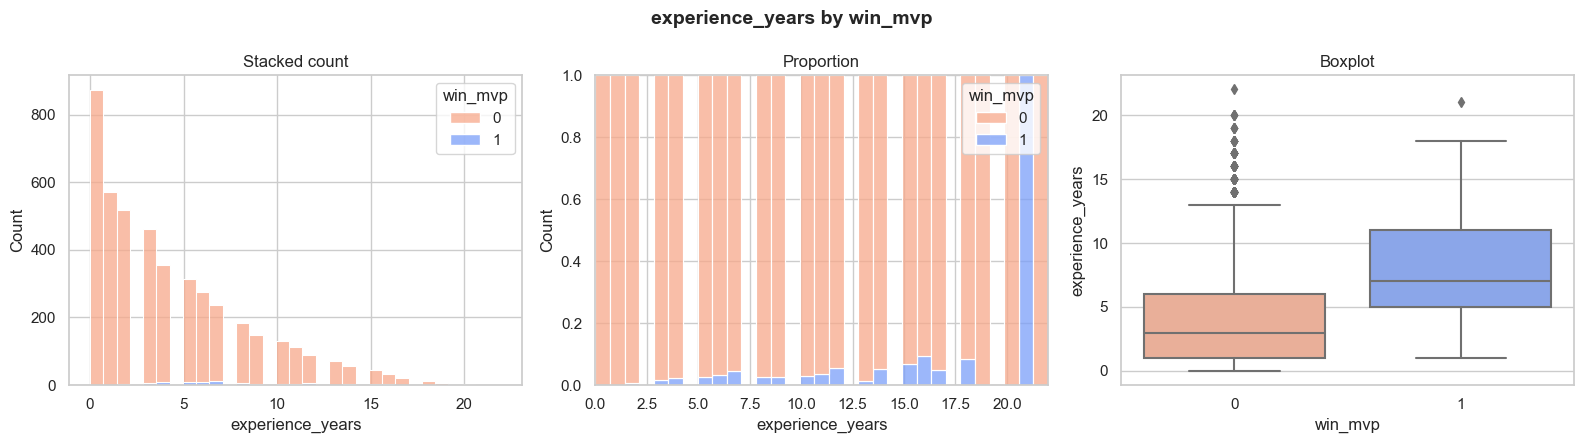

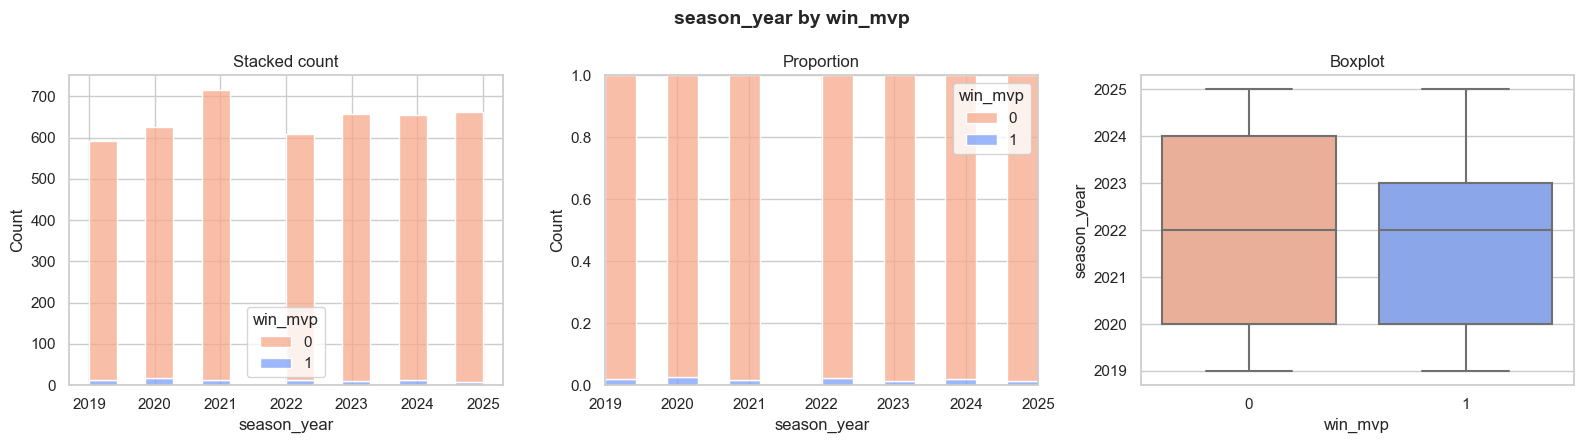

In [50]:
for col in numeric_columns_pp:
    numeric_vs_categorical_plot(data, col)

### Categorical vs Categorical Plot

In [51]:
def two_categorical_plot(df, col, target="win_mvp"):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
    fig.suptitle(col, fontsize=14, fontweight="bold")

    order = df[col].value_counts().index
    target_values = sorted(df[target].dropna().unique())

    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    # cont_table = pd.crosstab(df[col], df[target])
    # sns.heatmap(cont_table, annot=True, fmt=".0f", cmap=soft_coolwarm, cbar=False, ax=axes[0, 0])

    prop_table = pd.crosstab(df[col], df[target], normalize="index")
    sns.heatmap(prop_table, annot=True, fmt=".2%", cmap=soft_coolwarm, cbar=False, ax=axes[0, 0])

    sns.countplot(data=df, x=col, hue=target, order=order, palette=palette, ax=axes[0, 1])
    axes[0, 1].tick_params(axis="x", rotation=45)
    axes[0, 1].set_title("Grouped count")

    # ct = pd.crosstab(df[col], df[target], normalize="index").reindex(order)
    # ct.plot(kind="bar", stacked=True, color=[palette[v] for v in ct.columns], ax=axes[1, 1])
    # axes[1, 1].tick_params(axis="x", rotation=45)
    # axes[1, 1].set_title("Proportion by " + target)

    plt.tight_layout()
    plt.show()

### Numeric vs Numeric Plot

In [52]:
def numeric_vs_numeric_plot(df, x, y, hue=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{x} vs {y}", fontsize=14, fontweight="bold")

    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    pearson_r, pearson_p = pearsonr(clean[x], clean[y])
    spearman_r, spearman_p = spearmanr(clean[x], clean[y])

    # scatter + regression line
    sns.regplot(
        data=df, x=x, y=y, ax=axes[0],
        scatter_kws=dict(alpha=0.35, s=18, color=Blue, edgecolor="none"),
        line_kws=dict(color=Orange, linewidth=2.2),
    )
    axes[0].set_title(
        f"pearson r={pearson_r:.2f} (p={pearson_p:.1g})   |   spearman ρ={spearman_r:.2f}",
        fontsize=10
    )
    axes[0].spines[["top", "right"]].set_visible(False)

    #colored by a category if given, otherwise a density view
    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        sns.scatterplot(
            data=df, x=x, y=y, hue=hue, palette=palette,
            alpha=0.5, s=22, edgecolor="none", ax=axes[1]
        )
        axes[1].set_title(f"colored by {hue}", fontsize=11)
        axes[1].legend(frameon=False, title=hue)
    else:
        sns.kdeplot(data=df, x=x, y=y, fill=True, cmap=soft_coolwarm, thresh=0.05, ax=axes[1])
        axes[1].set_title("Density", fontsize=11)

    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

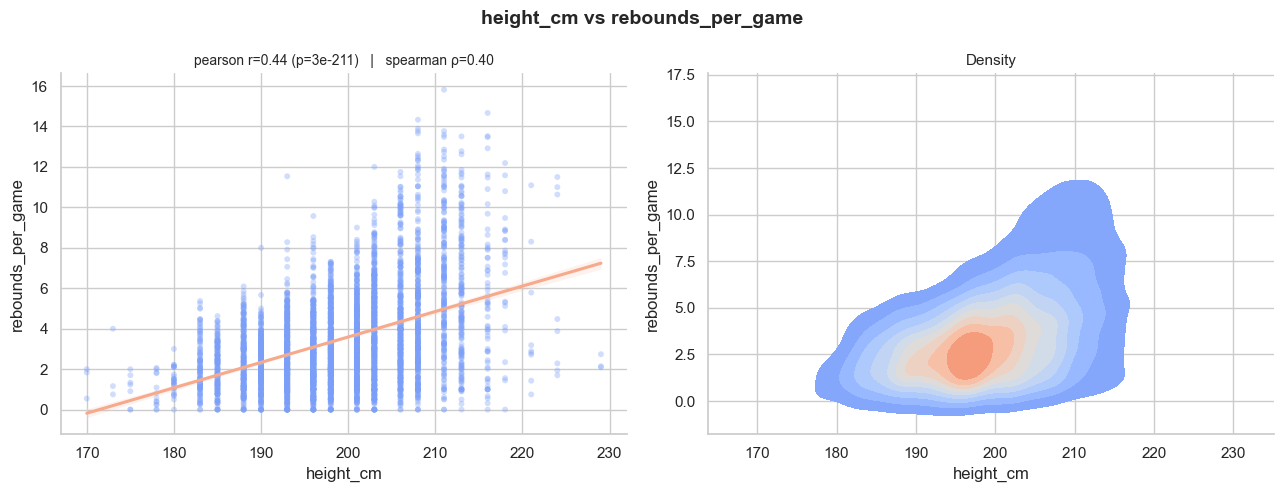

In [53]:
numeric_vs_numeric_plot(data, "height_cm", "rebounds_per_game")

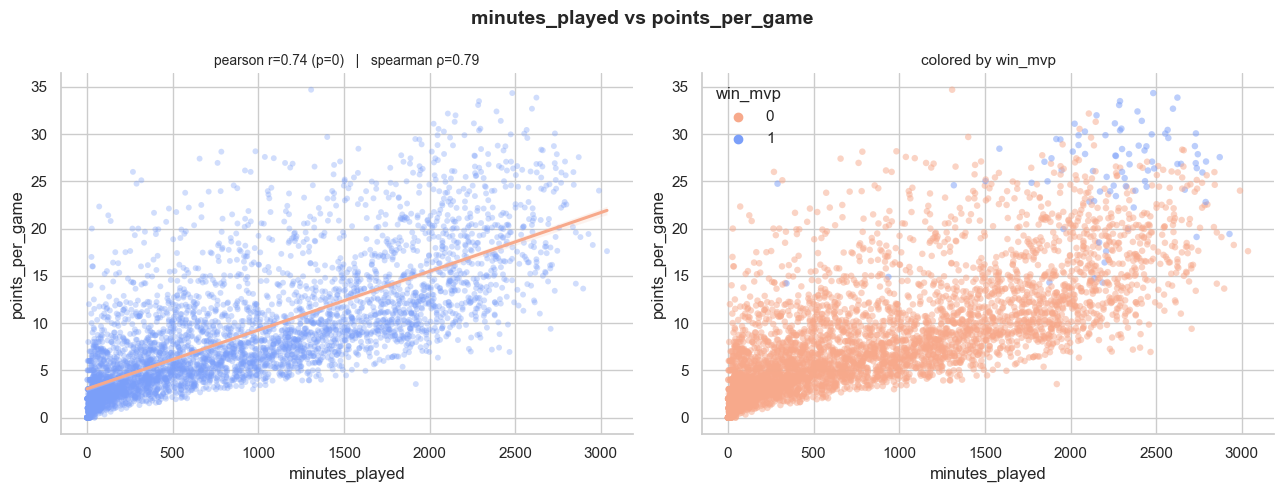

In [54]:
numeric_vs_numeric_plot(data, "minutes_played", "points_per_game", hue="win_mvp")

### Season Trend Plot

In [55]:
def plot_season_trend(df, col, season_col="season", season_order_col="season_year", hue=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    order = (
        df[[season_col, season_order_col]]
        .drop_duplicates()
        .sort_values(season_order_col)[season_col]
    )

    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        summary = df.groupby([season_col, hue])[col].mean().reset_index()
        for val in hue_values:
            sub = summary[summary[hue] == val].set_index(season_col).reindex(order)
            ax.plot(order, sub[col], marker="o", linewidth=2.2, label=str(val), color=palette[val])
        ax.legend(title=hue, frameon=False)
    else:
        summary = df.groupby(season_col)[col].agg(["mean", "std", "count"]).reindex(order)
        se = summary["std"] / np.sqrt(summary["count"])
        ax.plot(order, summary["mean"], marker="o", linewidth=2.2, color=Blue)
        ax.fill_between(
            range(len(order)), summary["mean"] - se, summary["mean"] + se,
            color=Blue, alpha=0.15, label="± SE"
        )
        ax.legend(frameon=False)

    ax.set_title(f"{col} by season", fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.show()

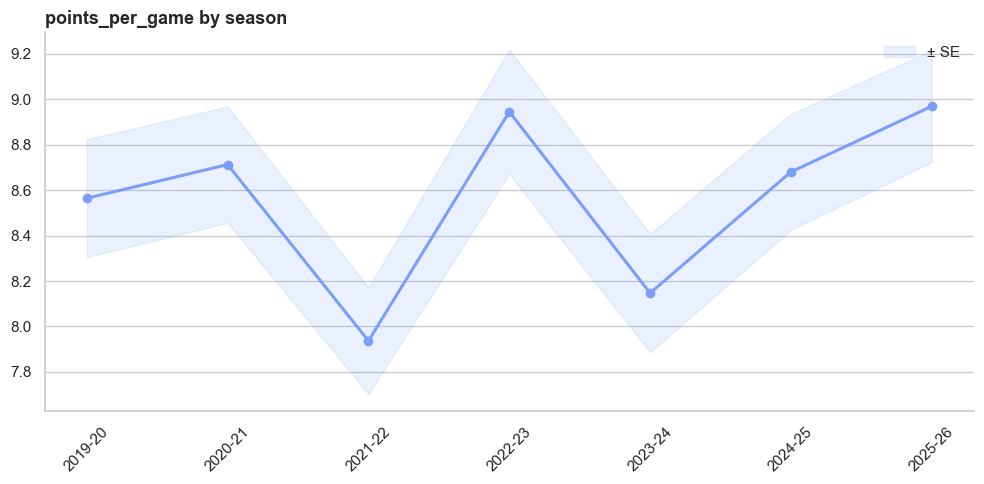

In [56]:
plot_season_trend(data, "points_per_game")

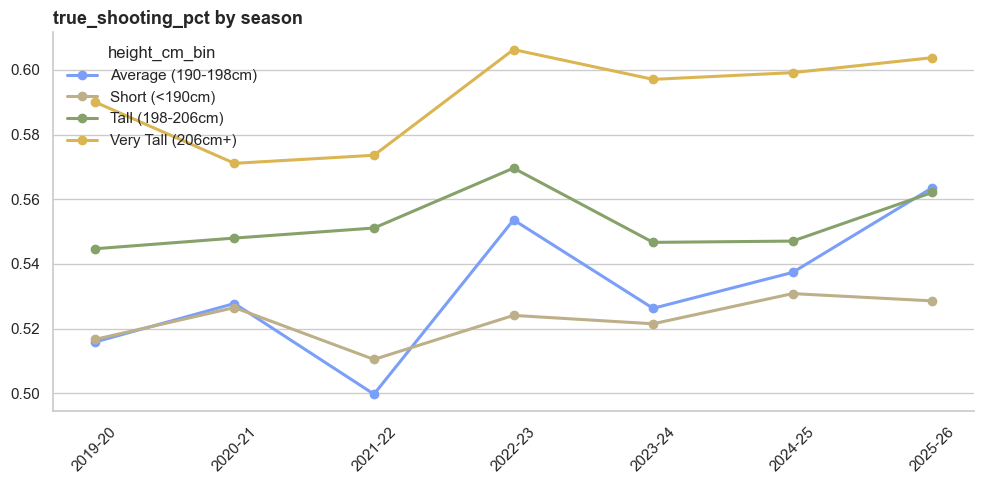

In [57]:
plot_season_trend(data, "true_shooting_pct", hue="height_cm_bin")

In [58]:
def anova_boxplot(df, group_col, value_col, palette=None):
    order = df.groupby(group_col)[value_col].median().sort_values(ascending=False).index
    colors = palette or [FALLBACK_PALETTE[i % len(FALLBACK_PALETTE)] for i in range(df[group_col].nunique())]

    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=df, x=group_col, y=value_col, order=order, palette=colors)
    sns.stripplot(data=df, x=group_col, y=value_col, order=order, color="black", alpha=0.15, size=2)
    plt.title(f"{value_col} by {group_col}", fontsize=12, fontweight="bold", loc="left")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

# Exploratory Data Analysis (EDA)

### Confidence Interval Analysis

- Confidence intervals estimate the likely range for the true population mean of a numeric
  variable, based on the sample we have.
- Applied here to `points_per_game`, `minutes_played`, and `true_shooting_pct` — instead of
  reporting only the sample mean, we report a 95% confidence interval so the result also
  communicates uncertainty.

In [59]:
def mean_ci(data, column, confidence=0.95):

    x = data[column].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(x)
    mean = x.mean()
    std = x.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin_error = t_critical * se

    result = pd.DataFrame({
        "Variable": [column],
        "Type": "Mean CI",
        "N": n,
        "Sample Mean": round(mean, 3),
        "Sample Std": round(std, 3),
        "Confidence Level": confidence,
        "CI Lower": round(mean - margin_error, 3),
        "CI Upper": round(mean + margin_error, 3),
    })

    return result

### ANOVA: numeric outcome across a multi-category variable

In [60]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna().copy()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        groups = [
            g[target_col].values
            for _, g in temp.groupby(group_col)
            if len(g) > 0
        ]
        f_stat, p = f_oneway(*groups)
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")


    return f_stat, p, result

In [61]:
def get_residuals(df, value_col, group_col):
    return df[value_col] - df.groupby(group_col)[value_col].transform('mean')

In [62]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

### Chi-square test of independence between two categorical variables

- **Null Hypothesis (H0):** the two categorical variables are independent.
- **Alternative Hypothesis (H1):** the two categorical variables are associated.
- If p-value < 0.05, reject H0.

In [63]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    two_categorical_plot(df, col_1, col_2)

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

### Numeric vs categorical (binary target)

To compare a continuous feature against a binary target, first check normality per group
(Shapiro-Wilk). If both groups are normal, use an independent-samples t-test. If not, attempt
a Box-Cox transform and re-test; if it still isn't normal, fall back to the non-parametric
Mann-Whitney U test.

In [64]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):

    numeric_vs_categorical_plot(data, col_1, col_2)

    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].replace([np.inf, -np.inf], np.nan).dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].replace([np.inf, -np.inf], np.nan).dropna()

    shapiro_p0 = stats.shapiro(X1.sample(min(len(X1), 5000), random_state=42)).pvalue
    shapiro_p1 = stats.shapiro(X2.sample(min(len(X2), 5000), random_state=42)).pvalue
    print(f"Shapiro group '{categories[0]}': p = {shapiro_p0:.4g}")
    print(f"Shapiro group '{categories[1]}': p = {shapiro_p1:.4g}")

    if shapiro_p0 > alpha and shapiro_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            shapiro_p0_bc = stats.shapiro(X1_bc.sample(min(len(X1_bc), 5000)) if hasattr(X1_bc, "sample") else X1_bc[:5000]).pvalue
            shapiro_p1_bc = stats.shapiro(X2_bc[:5000]).pvalue

            if shapiro_p0_bc > alpha and shapiro_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p

### numeric-vs-numeric

In [65]:
def numeric_vs_numeric_test(df, x, y, alpha=0.05):
    numeric_vs_numeric_plot(df, x, y)
    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    rho, p = spearmanr(clean[x], clean[y])
    result = "Significant" if p < alpha else "Not Significant"
    print(f"Spearman rho = {rho:.4f}, p = {p:.4g}")
    print("Result:", result)
    return rho, p

In [66]:
mean_ci(data, "points_per_game")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,points_per_game,Mean CI,4513,8.552,6.479,0.95,8.363,8.741


In [67]:
mean_ci(data, "minutes_played")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,minutes_played,Mean CI,4513,886.994,771.588,0.95,864.476,909.511


In [89]:
mean_ci(data, "true_shooting_pct")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,true_shooting_pct,Mean CI,4513,0.547,0.117,0.95,0.543,0.55


### Q1: Do positions differ in scoring?

- **Variables:** `position_main`, `points_per_game`
- **Test:** Welch's one-way ANOVA (unequal variances -- see diagnostics above)
- **H0:** the mean `points_per_game` is the same across all positions.
- **H1:** at least one position has a different mean.

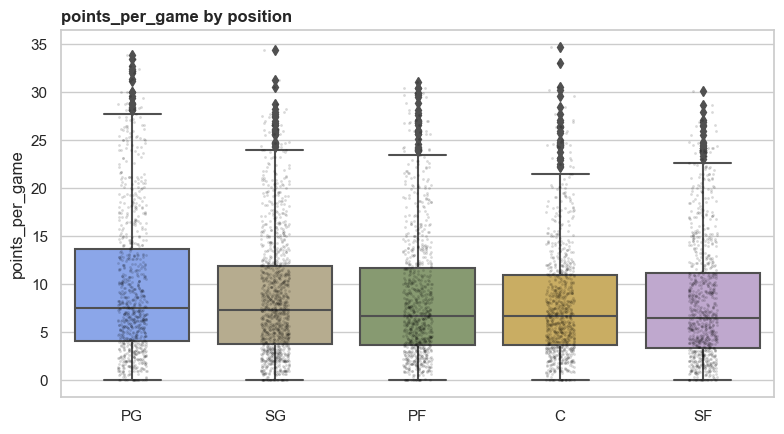

Test used: Welch ANOVA
F-stat = 8.5399
p-value = 7.764e-07
Result: Significant


(8.539881332740796, 7.764465044041174e-07, 'Significant')

In [116]:
anova_boxplot(data, "position", "points_per_game")
anova_test_pro(data, "position", "points_per_game", equal_var=False)

**Conclusion:**
There is a statistically significant difference in average scoring performance between the positions.
The boxplot indicates that the Point Guard (PG) position has a higher distribution of scoring compared to other positions.

### Q2: Do positions differ in blocking, passing, or rebounding?

- **Variables:** `position_main`, `blocks`, `assists`, `offensive_rebounds`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is the same across all positions.
- **H1:** at least one position has a different mean.

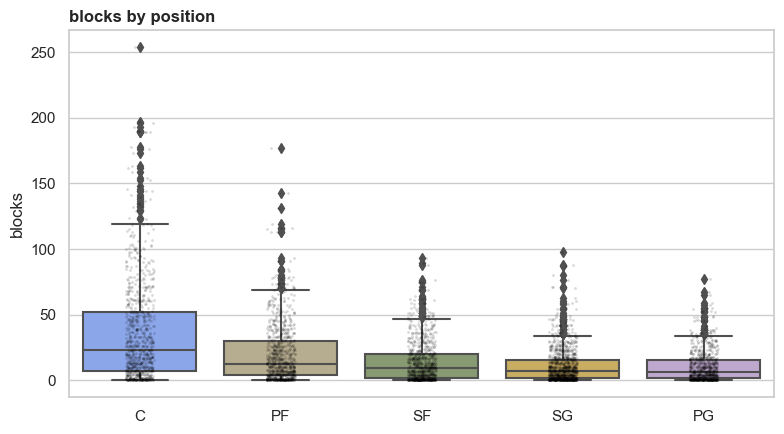

Test used: Welch ANOVA
F-stat = 120.2110
p-value = 1.293e-92
Result: Significant


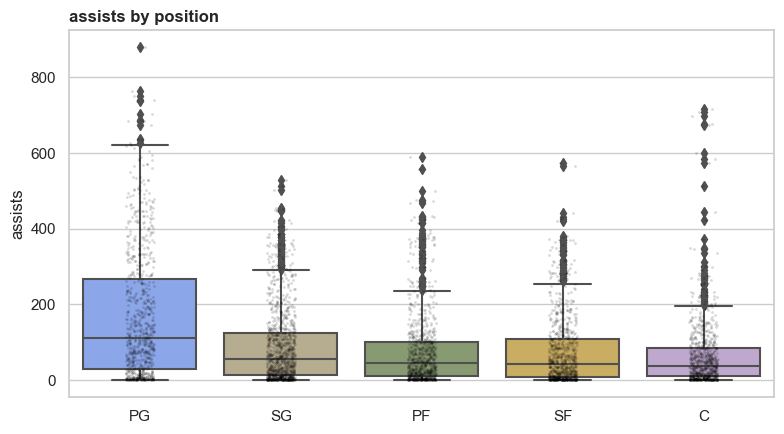

Test used: Welch ANOVA
F-stat = 66.5345
p-value = 3.425e-53
Result: Significant


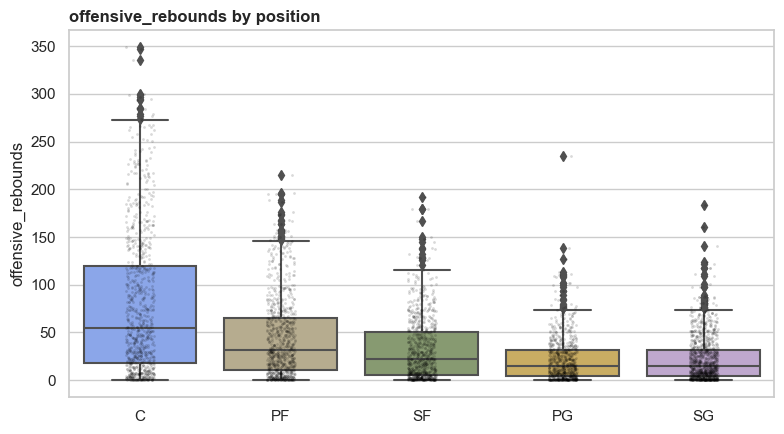

Test used: Welch ANOVA
F-stat = 169.8757
p-value = 2.363e-126
Result: Significant


In [91]:
for stat in ["blocks", "assists", "offensive_rebounds"]:
    anova_boxplot(data, "position", stat)
    anova_test_pro(data, "position", stat, equal_var=False)

**Conclusion:**

In all three categories, the p-value is extremely close to zero (𝑝 < 0.05), meaning we reject the null hypothesis for every metric. Player positions differ significantly in their blocking, passing, and rebounding contributions.

> The data clearly confirms traditional role specializations: Centers (C) lead significantly in blocks and offensive rebounds, while Point Guards (PG) dominate in assists.

> The very high F-statistics (especially for offensive rebounds and blocks) indicate that the “Position” variable is a very strong predictor of these specific physical and technical stats.

### Q3: Do experience groups differ in production?

- **Variables:** `experience_years_bin`, `points`, `assists`, `effective_field_goal_percentage`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is equal across experience groups.
- **H1:** at least one experience group has a different mean.

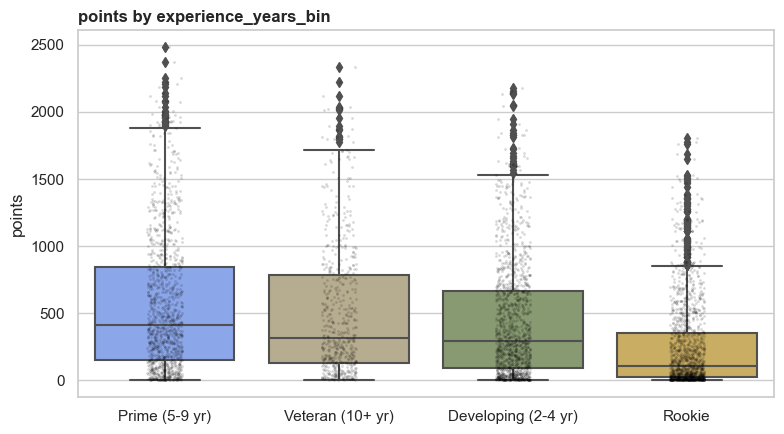

Test used: Welch ANOVA
F-stat = 158.4536
p-value = 1.44e-91
Result: Significant


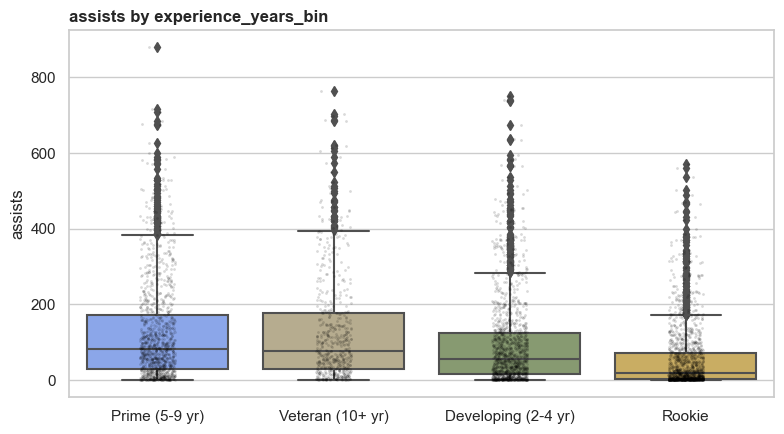

Test used: Welch ANOVA
F-stat = 122.5757
p-value = 1.869e-72
Result: Significant


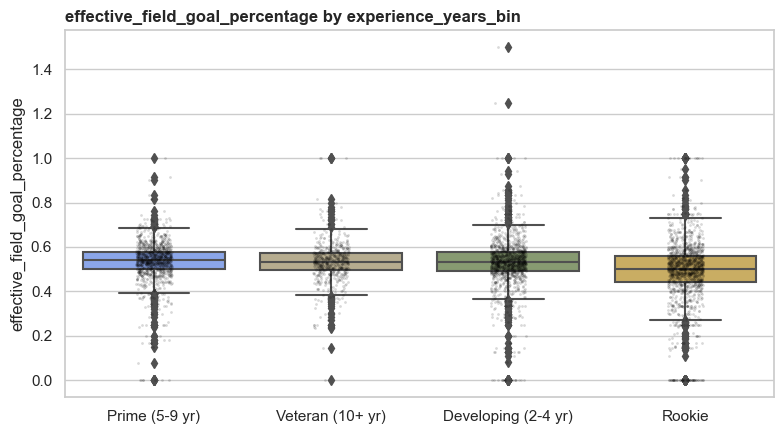

Test used: Welch ANOVA
F-stat = 34.5203
p-value = 8.755e-22
Result: Significant


In [92]:
for stat in ["points", "assists", "effective_field_goal_percentage"]:
    anova_boxplot(data, "experience_years_bin", stat)
    anova_test_pro(data, "experience_years_bin", stat, equal_var=False)

**Conclusion:**

Since p<0.05 for all variables, we reject the null hypothesis. Experience level has a statistically significant impact on a player’s scoring, playmaking, and shooting efficiency.


> The “Prime” Advantage: Players in the Prime (5-9 years) group show the highest median points and strong efficiency, representing the peak of NBA production.

> Learning Curve: There is a clear upward trend from Rookies (lowest in all categories) to the Developing and Prime stages.

> Veteran Consistency: While total points dip slightly for Veterans (10+ years) compared to Prime players, their assist numbers remain high, suggesting a shift in role toward playmaking as they age.

### Q4: Do starters outperform non-starters?

- **Variables:** `is_starter`, `points_per_game`, `effective_field_goal_percentage`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for starters and non-starters.
- **H1:** the distribution of the stat differs between starters and non-starters.

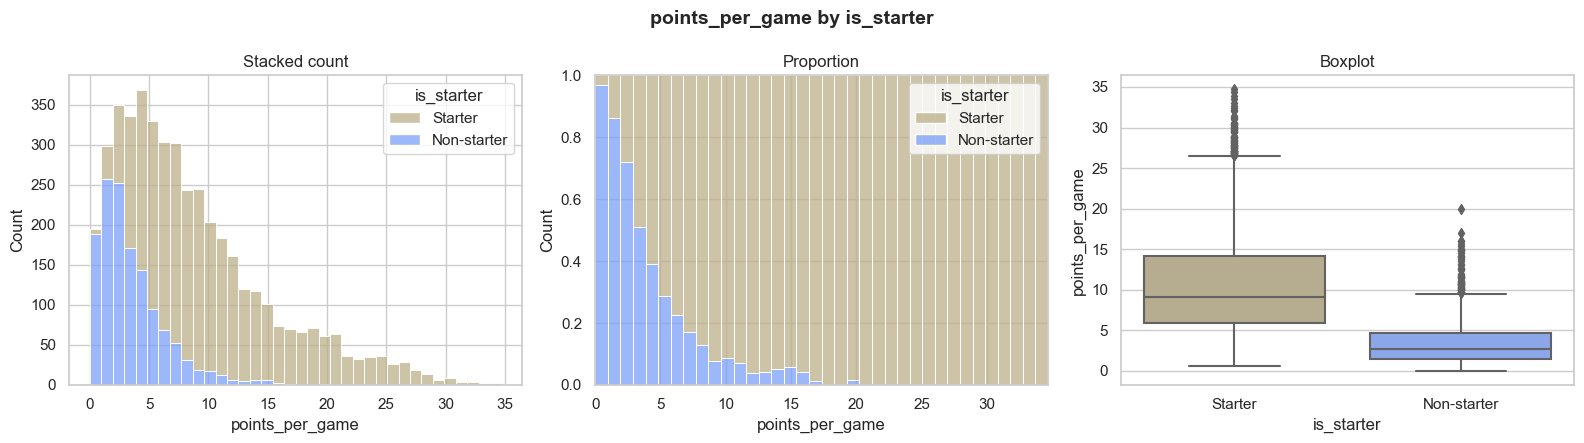

Shapiro group 'Starter': p = 4.392e-37
Shapiro group 'Non-starter': p = 3.02e-31
Not normal after Box-Cox -> Mann-Whitney U
U = 3750287.0, p = 0
Result: Significant


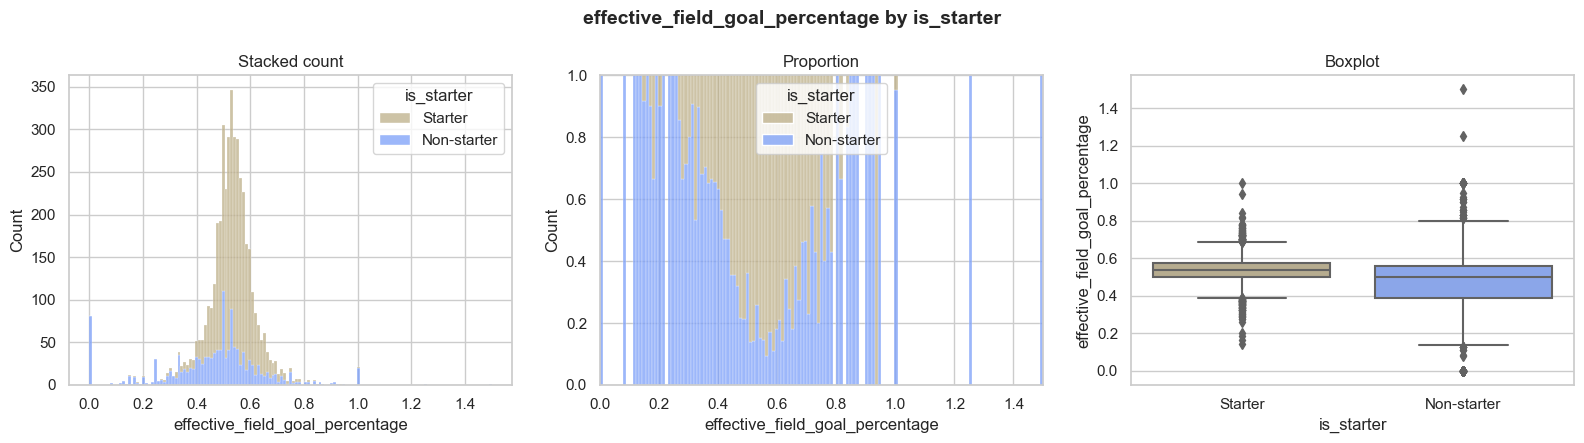

Shapiro group 'Starter': p = 7.462e-26
Shapiro group 'Non-starter': p = 1.272e-23
Not normal after Box-Cox -> Mann-Whitney U
U = 2758992.5, p = 5.43e-57
Result: Significant


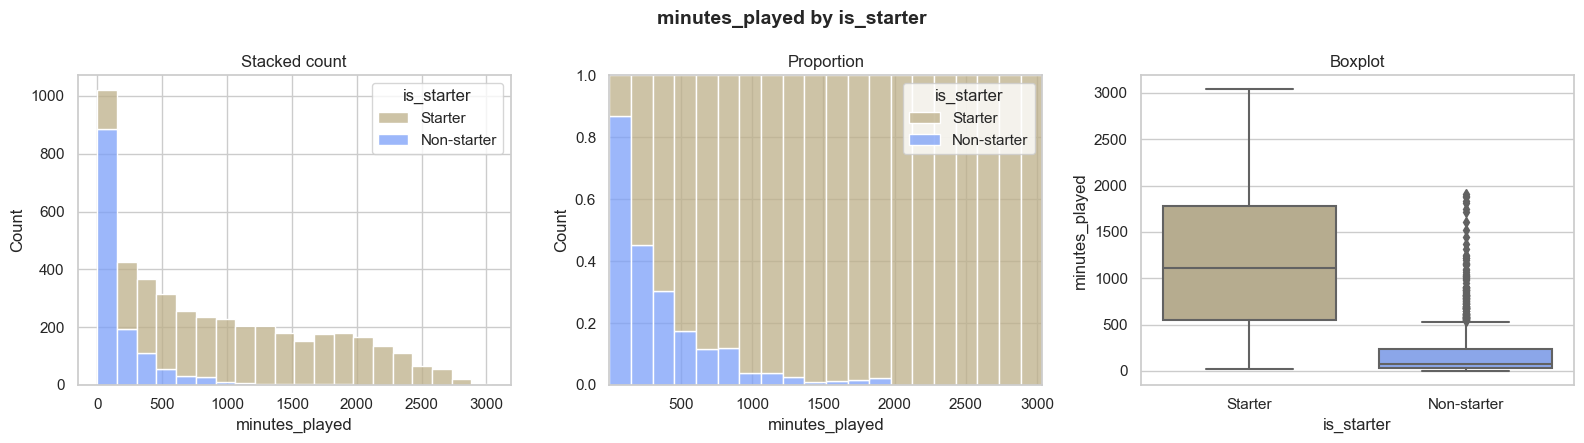

Shapiro group 'Starter': p = 5.87e-29
Shapiro group 'Non-starter': p = 2.757e-45
Not normal after Box-Cox -> Mann-Whitney U
U = 3956725.5, p = 0
Result: Significant


In [93]:
data["is_starter"] = np.where(data["games_started"] == 0, "Non-starter", "Starter")
for stat in ["points_per_game", "effective_field_goal_percentage", "minutes_played"]:
    numeric_vs_categorical(data, stat, "is_starter")

**Conclusion:**  
We reject $H_0$ for all three metrics. Starters and non-starters differ significantly in scoring, efficiency, and playing time. In general, **starters outperform non-starters**, with higher `points_per_game`, higher `effective_field_goal_percentage`, and much more `minutes_played`.


### Q5: Do right-handed players score differently than left-handed players?

- **Variables:** `shoots`, `points_per_game`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of points is the same for right- and left-handed players.
- **H1:** the distribution of points differs between right- and left-handed players.

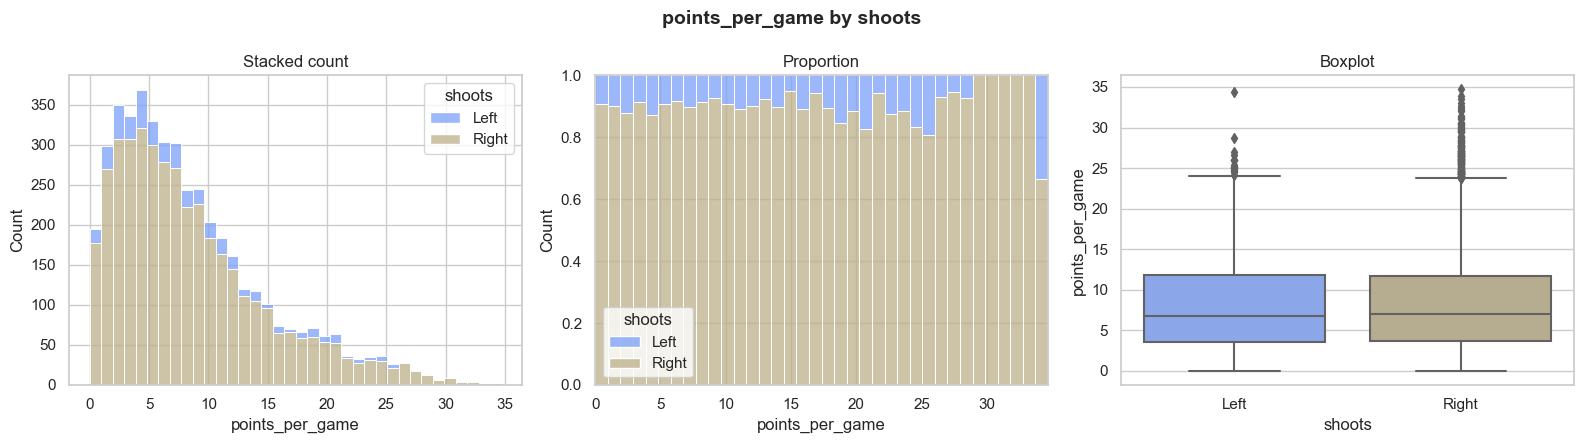

Shapiro group 'Left': p = 1.364e-16
Shapiro group 'Right': p = 5.967e-44
Not normal after Box-Cox -> Mann-Whitney U
U = 898492.5, p = 0.7464
Result: Not Significant


0.7463794809017086

In [94]:
numeric_vs_categorical(data, "points_per_game", "shoots")

**Conclusion:**  
We **fail to reject the null hypothesis ($H_0$)**. There is no statistically significant difference in scoring (`points_per_game`) between left-handed and right-handed players. 

> **Observation:** The boxplots and density proportions are nearly identical, confirming that shooting hand dominance has no apparent effect on a player's average scoring production.


### Q6: Are these player attributes associated with winning MVP?

- **Test:** Chi-square test of independence
- **H0:** the categorical variable and `win_mvp` are independent.
- **H1:** the categorical variable and `win_mvp` are associated.

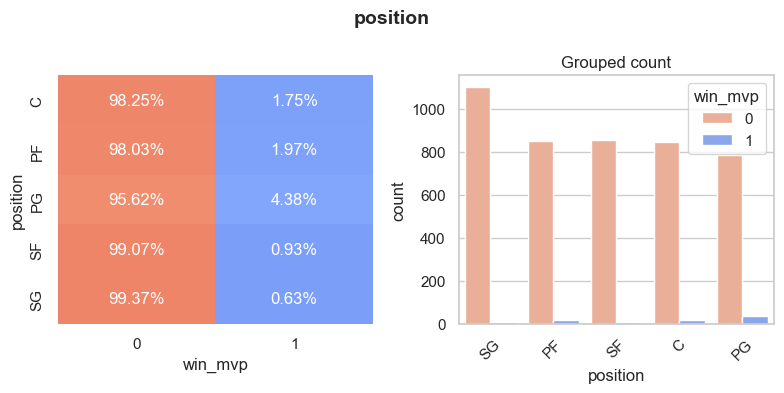

chi2_stat: 42.4797
p-value: 1.327e-08
Reject the Null Hypothesis
There IS a significant association between 'position' and 'win_mvp'.


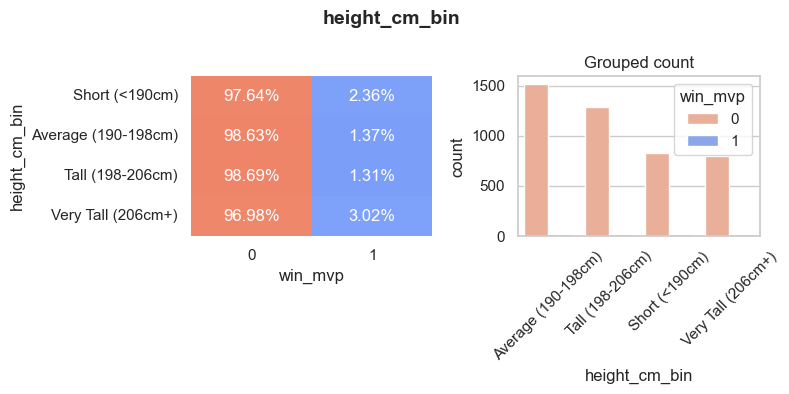

chi2_stat: 11.5721
p-value: 0.009003
Reject the Null Hypothesis
There IS a significant association between 'height_cm_bin' and 'win_mvp'.


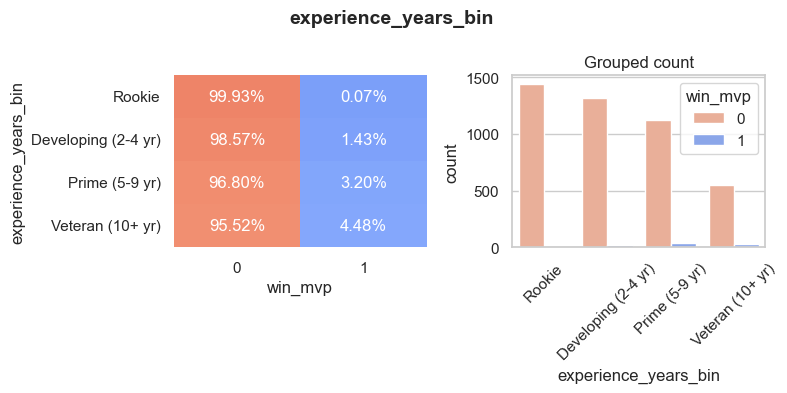

chi2_stat: 60.6437
p-value: 4.283e-13
Reject the Null Hypothesis
There IS a significant association between 'experience_years_bin' and 'win_mvp'.


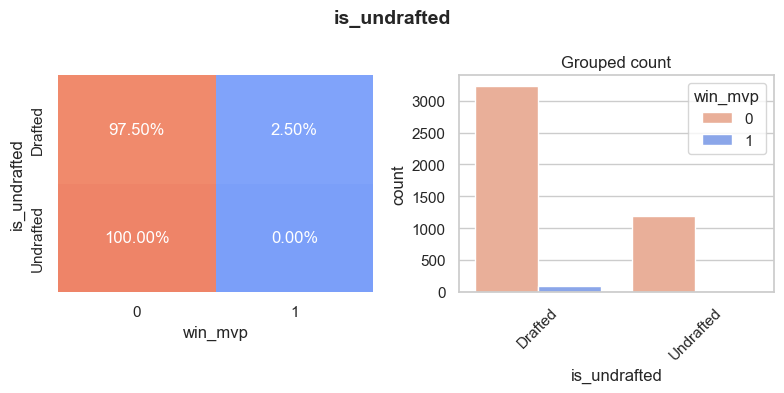

chi2_stat: 28.9806
p-value: 7.311e-08
Reject the Null Hypothesis
There IS a significant association between 'is_undrafted' and 'win_mvp'.


In [133]:
for col in ["position", "height_cm_bin", "experience_years_bin", "is_undrafted"]:
    compare_two_categorical(data, col, target)

**Conclusion:**  
We **reject the null hypothesis** for every attribute tested. There is a statistically significant association between all these factors and winning an MVP award.

**Key Findings:**
*   **Experience Matters:** The likelihood of winning MVP increases with experience, peaking in the **Veteran (10+ yr)** and **Prime (5-9 yr)** groups. Rookies have a near-zero (0.07%) probability.
*   **Position Bias:** **Point Guards (PG)** and **Power Forwards (PF)** show higher percentages of MVP winners compared to Shooting Guards (SG).
*   **The Undrafted Gap:** There is a stark difference in draft status; in this dataset, **0% of undrafted players** have won MVP, whereas drafted players have a 2.5% win rate.
*   **Physical Profile:** **Very Tall (206cm+)** and **Short (<190cm)** players (likely elite PGs) have higher MVP proportions than "Average" height players.



### Q7: Is scoring, shooting efficiency, or playing time different for MVP seasons?

- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for MVP and non-MVP seasons.
- **H1:** MVP seasons have a different (higher) distribution.

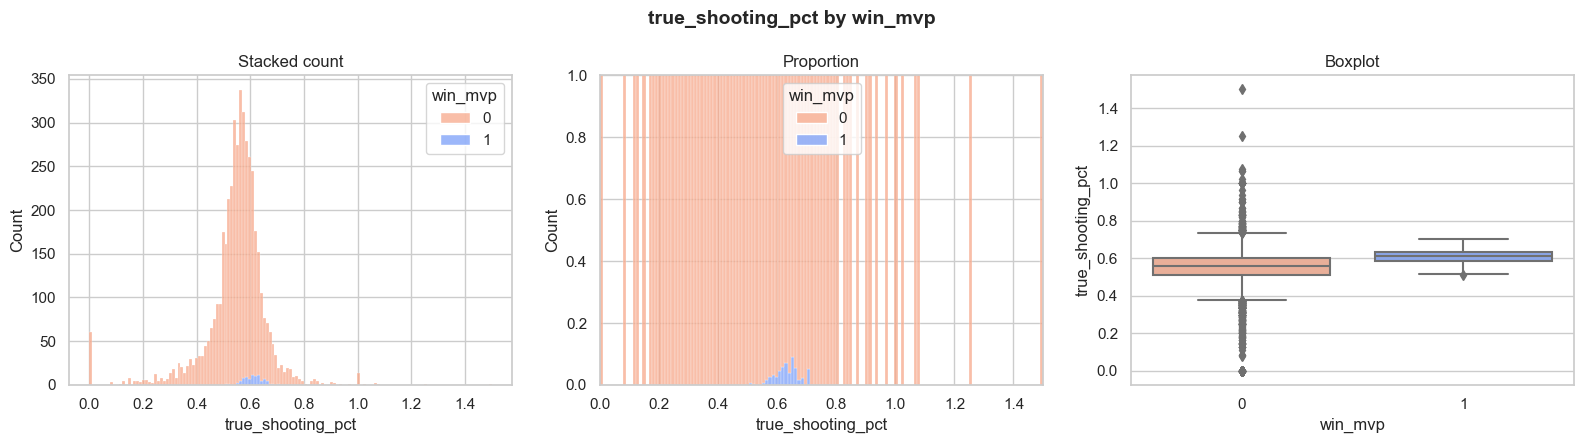

Shapiro group '1': p = 0.7547
Shapiro group '0': p = 5.167e-55
Not normal after Box-Cox -> Mann-Whitney U
U = 278341.5, p = 9.362e-16
Result: Significant


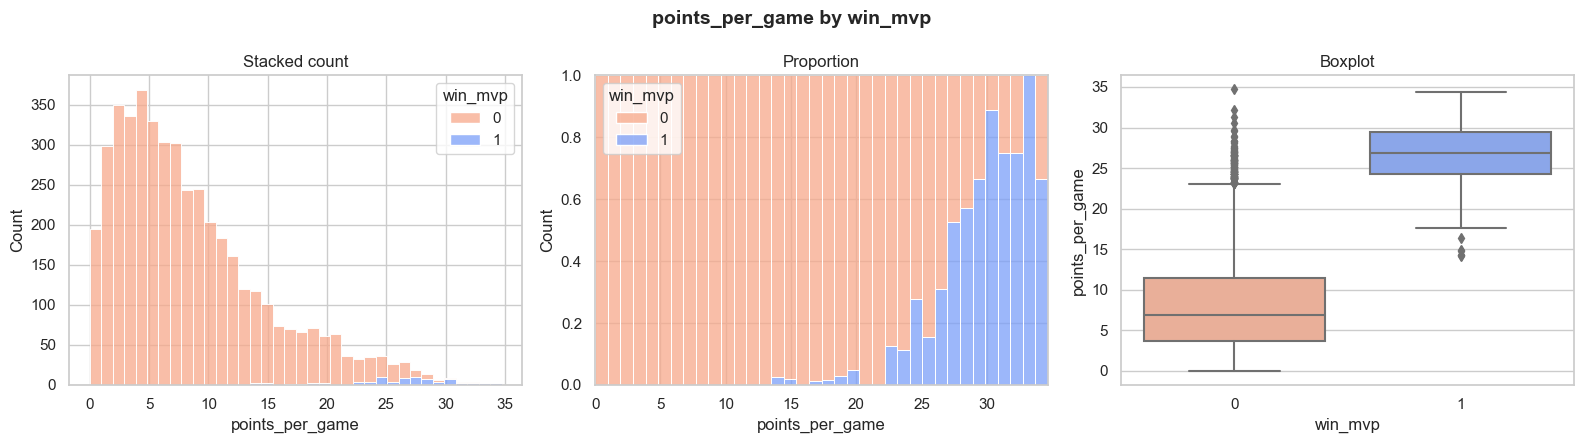

Shapiro group '1': p = 0.00035
Shapiro group '0': p = 2.277e-43
Not normal after Box-Cox -> Mann-Whitney U
U = 359442.5, p = 2.071e-50
Result: Significant


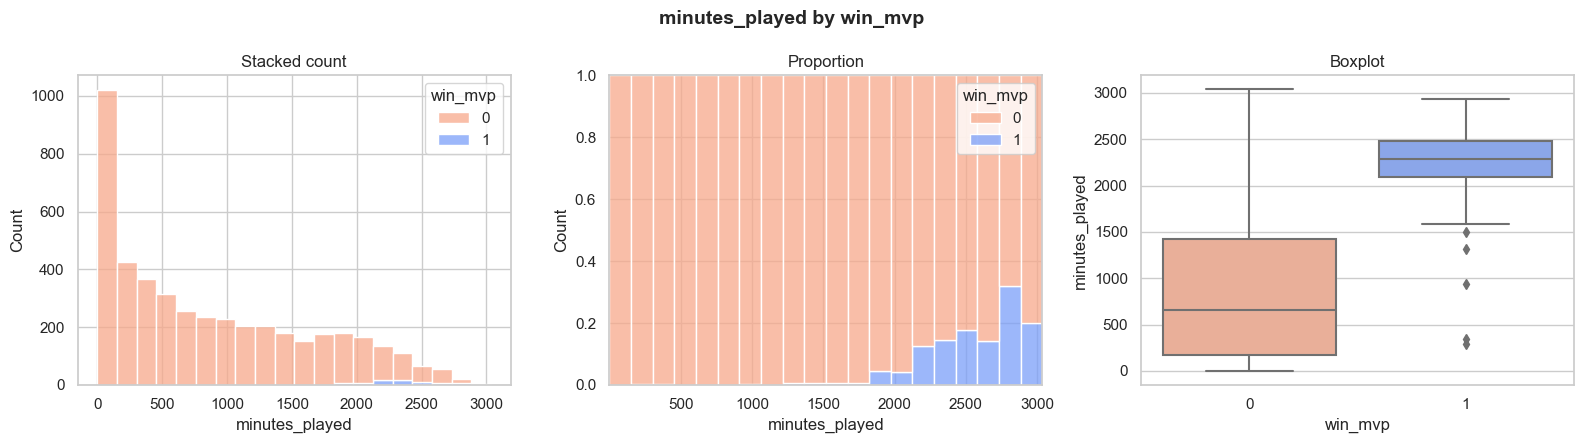

Shapiro group '1': p = 2.172e-08
Shapiro group '0': p = 3.717e-46
Not normal after Box-Cox -> Mann-Whitney U
U = 339593.5, p = 4.942e-40
Result: Significant


In [96]:
for stat in ["true_shooting_pct", "points_per_game", "minutes_played"]:
    numeric_vs_categorical(data, stat, target)

**Conclusion:**  
We **reject the null hypothesis ($H_0$)** for all three metrics. Statistical evidence confirms that MVP seasons are characterized by significantly higher scoring production, better shooting efficiency, and increased playing time.
*   **The Point Threshold:** The proportion chart for `points_per_game` shows that once a player crosses ~25 PPG, the likelihood of an MVP win increases dramatically.
*   **Efficiency Floor:** While non-MVP seasons show a wide spread of shooting efficiency (including many low values), MVP seasons are tightly clustered at high efficiency levels (mostly above 0.55 TS%).
*   **Durability:** MVP winners consistently rank in the top tier of `minutes_played`, usually exceeding 2000 minutes for the season.


### Q8: Do undrafted players who make an NBA roster get less playing time than drafted players?

- **Variables:** `is_undrafted`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of minutes played is the same regardless of draft status.
- **H1:** minutes played differs by draft status.

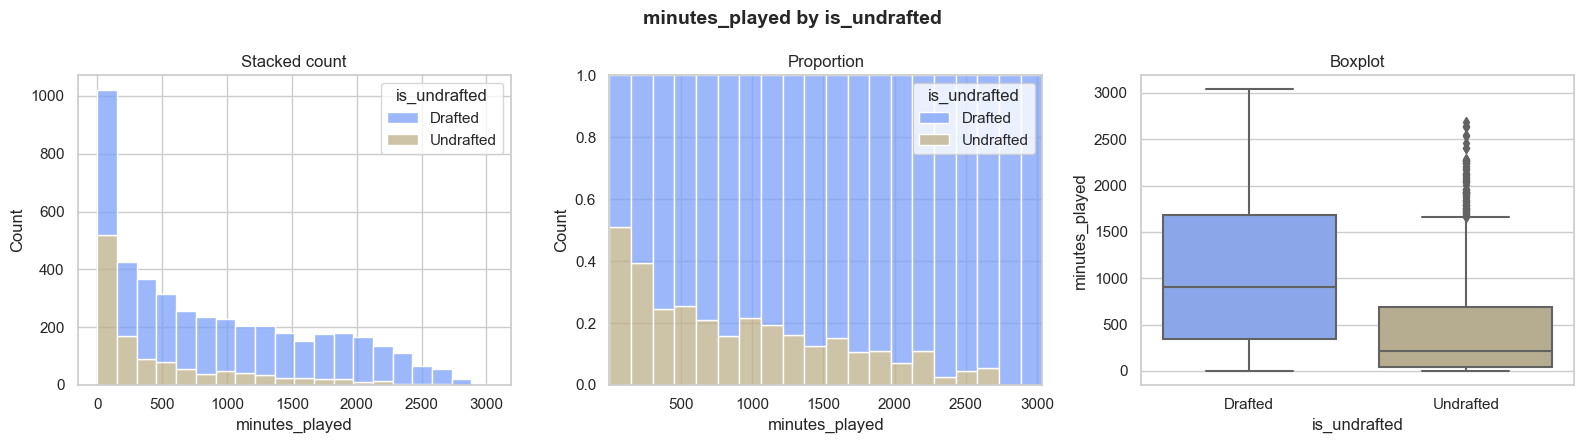

Shapiro group 'Drafted': p = 1.214e-35
Shapiro group 'Undrafted': p = 5.434e-37
Not normal after Box-Cox -> Mann-Whitney U
U = 2894511.0, p = 2.435e-124
Result: Significant


2.4354215117295756e-124

In [97]:
numeric_vs_categorical(data, "minutes_played", "is_undrafted")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is overwhelming statistical evidence ($p < 0.05$) that undrafted players who make an NBA roster receive significantly less playing time than their drafted counterparts.

*   Median Gap: The boxplot reveals a stark difference in median minutes. Drafted players have a median well above 500 minutes, while the median for undrafted players is significantly lower, often relegated to "garbage time" or deep bench roles.
*   Volume Distribution: The "Stacked count" histogram shows a massive concentration of undrafted players in the 0–250 minute range. Very few undrafted players cross the 2000-minute threshold.
*   Opportunity Proportion: The "Proportion" chart highlights that as minutes played increase, the percentage of the player pool that is undrafted shrinks. Drafted players dominate almost 100% of the high-minute (2500+) buckets.


### Q9: Does a heavier build predict better rebounding?

- **Variables:** `weight_kg`, `offensive_rebounds`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between weight and offensive rebounds).
- **H1:** rho ≠ 0.

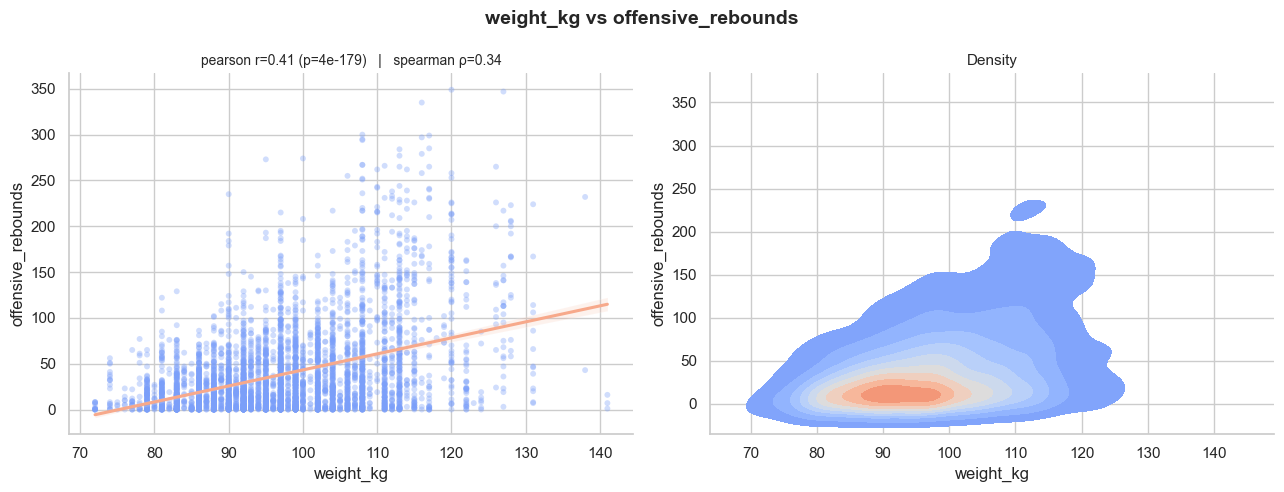

Spearman rho = 0.3353, p = 5.465e-119
Result: Significant


(0.33528157716254336, 5.464619175460971e-119)

In [98]:
numeric_vs_numeric_test(data, "weight_kg", "offensive_rebounds")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant positive relationship between player weight and offensive rebounds. Heavier players tend to grab more offensive boards.

*   The relationship is **positive but moderate**, so weight appears to help rebounding, but it is not the only factor involved.
*   The scatter/density plot shows a clear upward trend: as `weight_kg` increases, `offensive_rebounds` generally increase as well.


### Q10: Does shooting efficiency improve continuously with experience?

- **Variables:** `experience_years`, `true_shooting_pct`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between experience and shooting efficiency).
- **H1:** rho ≠ 0.

This is the continuous counterpart to Q3's binned ANOVA -- useful to check whether the
relationship looks smooth/monotonic or whether the binned groups were hiding a plateau.

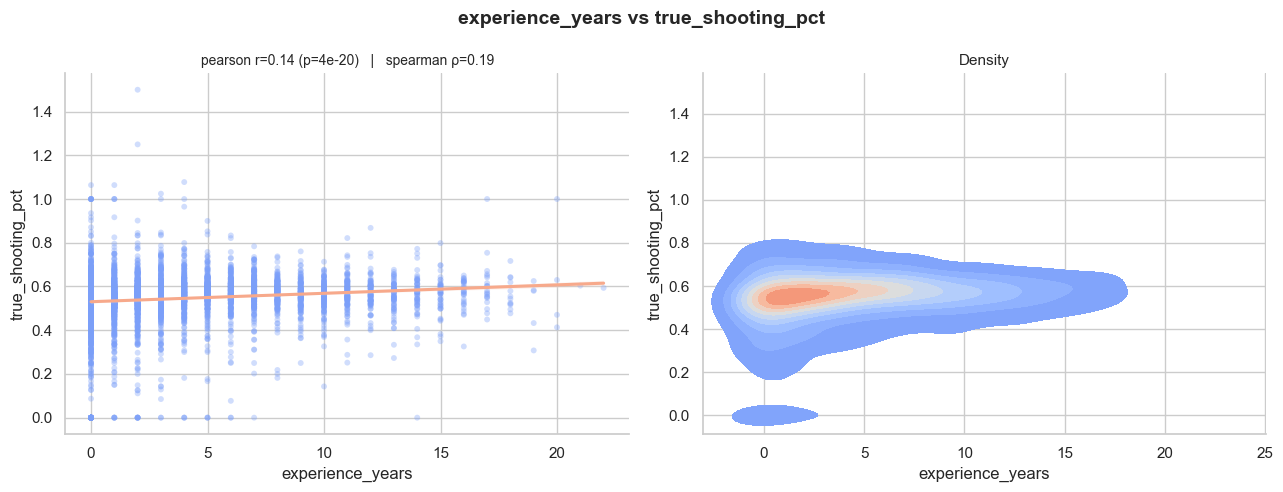

Spearman rho = 0.1928, p = 4.698e-39
Result: Significant


(0.19282432600405217, 4.6978425949896744e-39)

In [99]:
numeric_vs_numeric_test(data, "experience_years", "true_shooting_pct")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant positive monotonic relationship between a player's years of experience and their shooting efficiency (`true_shooting_pct`).


> Deep Dive: Continuous vs. Binned Analysis (Comparing Q10 and Q3)
Looking at this relationship as a continuous variable reveals important details that were not visible in the earlier binned ANOVA analysis:
>1. **A Weak but Clear Relationship:**
>   - Although the p-value is extremely small because of the large sample size, the Spearman correlation coefficient is relatively low ($\rho \approx 0.19$).
>   - This means experience is associated with better shooting efficiency, but it is a weak predictor on its own for any individual player.
>2. **Survivor Bias Effect:**
>   - The density plot shows that the lower boundary of shooting efficiency rises as experience increases.
>   - In early-career stages (0–4 years), there is a wide spread, including many low-efficiency players.
>   - In later-career stages (10+ years), those inefficient players largely disappear, suggesting that only more efficient shooters tend to remain in the league long enough to become veterans.
3. **Prime Plateau:**
>   - The overall trend rises slightly in the first few years, but then levels off around the 5–15 year range.
>   - This supports the earlier finding that players improve during their early development phase, but once they reach their prime, shooting efficiency tends to plateau rather than keep increasing steadily.

### Q11: Is shooting hand associated with playing position?

- **Variables:** `shoots`, `position_main`
- **Test:** Chi-square test of independence
- **H0:** shooting hand and position are independent.
- **H1:** shooting hand and position are associated.

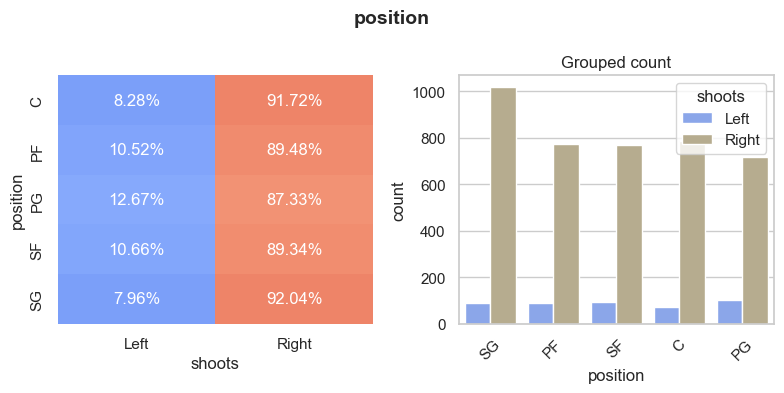

chi2_stat: 15.2271
p-value: 0.004253
Reject the Null Hypothesis
There IS a significant association between 'position' and 'shoots'.


In [68]:
compare_two_categorical(data, "position", "shoots")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant association between shooting hand and playing position.

1. **Right-handed players dominate every position**
   - Right-handed players make up the large majority across all positions.
   - This is consistent with the overall prevalence of right-handed shooters in the league.

2. **Point guards show the highest left-handed share**
   - Among the positions shown, **PGs have the largest proportion of left-handed players** at **12.67%**.
   - This suggests a slight positional imbalance, even though right-handed players still dominate.

3. **Centers have the lowest left-handed share**
   - **Centers** show one of the smallest left-handed proportions at **8.28%**.
   - This indicates that left-handedness is not evenly distributed across roles.

4. **Association is statistically significant but modest**
   - The p-value shows a real relationship, but the effect appears relatively small in practical terms.
   - In other words, shooting hand is related to position, but position is still mostly determined by skill set, size, and role rather than handedness alone.


### Q12: Do veteran players get more minutes than rookies?

- **Variables:** `experience_years_bin`, `minutes_played`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean `minutes_played` is equal across experience groups.
- **H1:** at least one experience group differs.

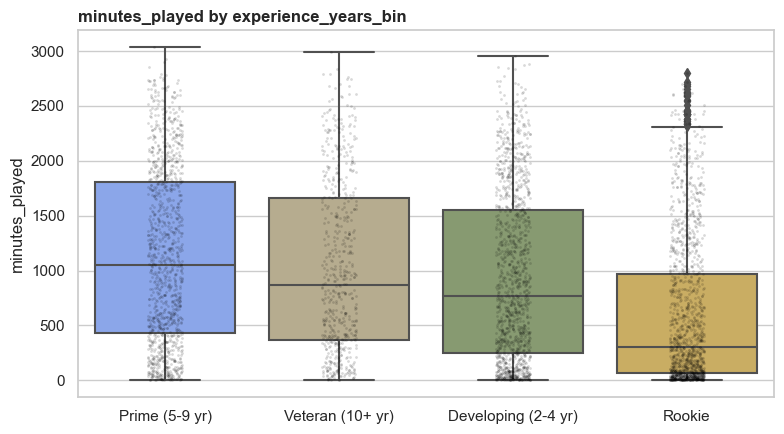

Test used: Welch ANOVA
F-stat = 137.0002
p-value = 1.225e-80
Result: Significant


(137.00015216908102, 1.225285164955166e-80, 'Significant')

In [101]:
anova_boxplot(data, "experience_years_bin", "minutes_played")
anova_test_pro(data, "experience_years_bin", "minutes_played", equal_var=False)

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant difference in minutes played across experience groups. This means that career stage has a strong effect on playing time.

1. **Prime players receive the most minutes**
   - Players in the **Prime (5–9 years)** group have the highest median minutes played.
   - Teams appear to rely most heavily on players who are experienced but not yet in decline.

2. **Rookies play the fewest minutes**
   - **Rookies** have the lowest median playing time by a wide margin.
   - Most rookies are used in limited roles, with only a few exceptions receiving heavy minutes.

3. **Veterans still play more than developing players**
   - **Veterans (10+ years)** generally receive more minutes than **Developing (2–4 years)** players.
   - Even if they are past their peak, experience helps veterans remain valuable in team rotations.

4. **High-minute seasons are concentrated in established players**
   - The distribution shows that very high-minute seasons are much more common among **Prime** and **Veteran** players.
   - This suggests that long, durable, high-usage seasons are mostly reserved for established players.


### Q13: Are undrafted players who make an NBA roster more shooting-efficient than drafted players?

- **Variables:** `is_undrafted`, `true_shooting_pct`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of shooting efficiency is the same regardless of draft status.
- **H1:** shooting efficiency differs by draft status.

Rationale: an undrafted player who sticks in the league may need to be more efficient to
justify a roster spot -- a survivorship-bias-style question, distinct from Q8 (which looks at
playing time rather than efficiency).

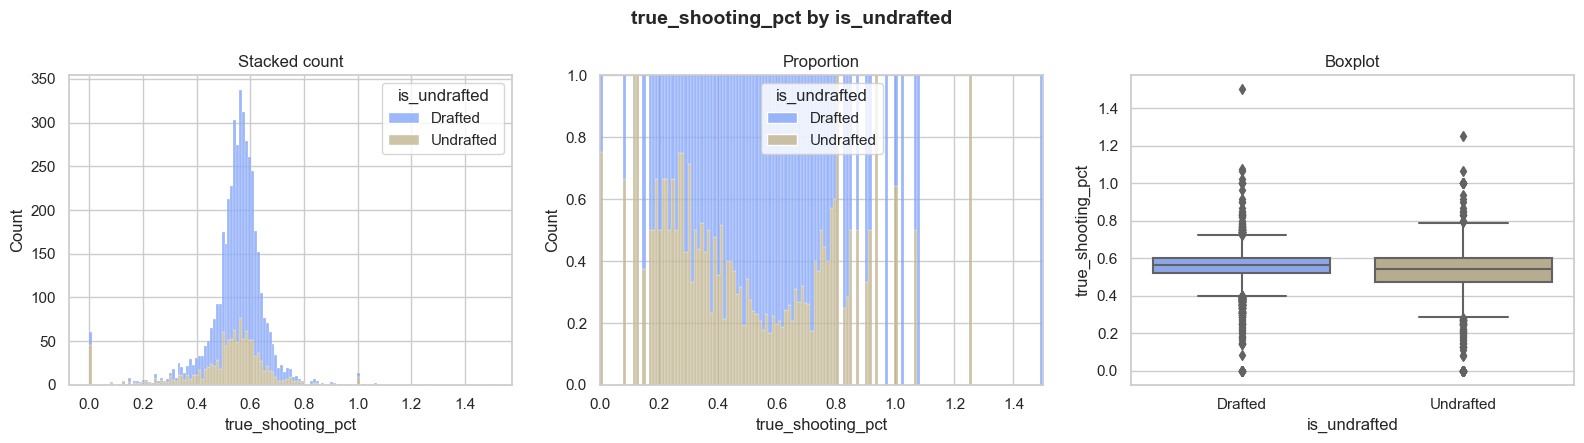

Shapiro group 'Drafted': p = 9.799e-47
Shapiro group 'Undrafted': p = 1.187e-29
Not normal after Box-Cox -> Mann-Whitney U
U = 2250345.0, p = 2.164e-12
Result: Significant


2.1639222450780544e-12

In [102]:
numeric_vs_categorical(data, "true_shooting_pct", "is_undrafted")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant difference in shooting efficiency based on draft status. However, the data suggests that **drafted players are actually more efficient** than undrafted players.

1. **Efficiency Gap**
   - The **Boxplot** shows that drafted players have a slightly higher median `true_shooting_pct` than undrafted players. 
   - This suggests that while undrafted players must be talented to make a roster, they do not necessarily outperform drafted players in efficiency to "justify" their spot.

2. **The "Floor" and Failed Stints**
   - In the **Proportion chart**, undrafted players have a noticeably higher concentration in the very low efficiency ranges (0.0 to 0.4 TS%). 
   - This likely represents undrafted players who received brief "cup of coffee" opportunities in the NBA but failed to produce, leading to a quick exit from the league.

3. **Concentration of Talent**
   - The **Stacked count** histogram shows a much tighter and taller "peak" for drafted players around the league average (approx. 0.55 TS%). 
   - Drafted players appear to have more consistent production, whereas undrafted players show more variance and a lower overall efficiency floor.

4. **Survivorship Bias Context**
   - Contrary to the hypothesis that undrafted survivors might be "efficiency specialists," the data indicates that draft status remains a strong predictor of offensive quality. Drafted players likely benefit from more "gravity," better roles, and higher innate skill, allowing them to maintain higher efficiency despite higher defensive attention.


### Q14) MVP Winners Come from Better Teams

- **Variables:**
  - MVP winner: defined as `rank == 1` in `mvp` (MVP votes table)
  - Team performance: `wins` (from `team_season_stats`)
- **Test:** Independent t-test
- **H0:** Mean team wins are equal for MVP winners and non-winner vote-getters.
- **H1:** Mean team wins differ between MVP winners and non-winner vote-getters.

In [83]:
mvp_wins = mvp.merge(
    team_season_stats[["team_id", "season_id", "wins"]],
    on=["team_id", "season_id"],
    how="left"
)

mvp_wins["mvp_winner"] = np.where(mvp_wins["rank"] == 1, "MVP Winner", "Non-winner Vote-getter")

winner_wins = mvp_wins.loc[mvp_wins["mvp_winner"] == "MVP Winner", "wins"].dropna()
nonwinner_wins = mvp_wins.loc[mvp_wins["mvp_winner"] == "Non-winner Vote-getter", "wins"].dropna()

print(f"Sample sizes — MVP winners: {len(winner_wins)}   Non-winner vote-getters: {len(nonwinner_wins)}")
winner_wins.describe(), nonwinner_wins.describe()

Sample sizes — MVP winners: 7   Non-winner vote-getters: 72


(count     7.000000
 mean     56.285714
 std       7.718253
 min      47.000000
 25%      51.000000
 50%      56.000000
 75%      60.500000
 max      68.000000
 Name: wins, dtype: float64,
 count    72.000000
 mean     49.541667
 std       7.080896
 min      33.000000
 25%      44.000000
 50%      49.500000
 75%      53.000000
 max      64.000000
 Name: wins, dtype: float64)

In [84]:
# normality check (informational — the independent t-test is used regardless, per the test plan above)
shapiro_p_winner = shapiro(winner_wins).pvalue
shapiro_p_nonwinner = shapiro(nonwinner_wins).pvalue
print(f"Shapiro (MVP winners):             p = {shapiro_p_winner:.4g}")
print(f"Shapiro (non-winner vote-getters): p = {shapiro_p_nonwinner:.4g}")

Shapiro (MVP winners):             p = 0.6639
Shapiro (non-winner vote-getters): p = 0.1059


In [85]:
alpha = 0.05

stat, p_value = ttest_ind(winner_wins, nonwinner_wins, equal_var=True)

print(f"Independent t-test: statistic = {stat:.4f},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")
print(f"\nMean wins — MVP winners: {winner_wins.mean():.2f}   Non-winner vote-getters: {nonwinner_wins.mean():.2f}")

Independent t-test: statistic = 2.3882,  p = 0.01938
Result: Significant — reject H0

Mean wins — MVP winners: 56.29   Non-winner vote-getters: 49.54


## Q15) Higher MVP Vote Share Is Associated with Stronger Player Performance

- **Variables:**
  - MVP vote share: `share`
  - Player-performance metrics: `points_per_game`, `assists_per_game`, `rebounds_per_game`, `effective_field_goal_percentage`
- **Test:** Spearman correlation significance test
- **H0:** MVP vote share has no monotonic correlation with each player-performance metric (ρ = 0).
- **H1:** MVP vote share has a significant monotonic correlation with at least one player-performance metric (ρ ≠ 0).

Note: only player-seasons that actually received at least one MVP vote have a defined `share`, so this test is restricted to that subset (an inner join with `mvp`), not the full league.

In [86]:
# restrict to player-seasons that received at least one MVP vote (share is only defined for those)
mvp_share = mvp[["player_id", "season_id", "share"]].merge(
    data[["player_id", "season_id", "points_per_game", "assists_per_game",
          "rebounds_per_game", "effective_field_goal_percentage"]],
    on=["player_id", "season_id"],
    how="inner"
)

print(f"Sample size (MVP vote-getters): {len(mvp_share)}")
mvp_share.describe()

Sample size (MVP vote-getters): 83


,player_id,season_id,share,points_per_game,assists_per_game,rebounds_per_game,effective_field_goal_percentage
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,1482.710843,3.698795,0.219422,26.104618,6.569161,7.678288,0.559241
std,304.324583,1.942684,0.309585,4.737116,2.190259,3.027094,0.038993
min,1022.000000,1.000000,0.001000,14.200000,1.253521,1.933333,0.465000
25%,1264.500000,2.000000,0.003000,24.270624,5.012958,5.196135,0.531000
50%,1415.000000,4.000000,0.030000,26.851351,6.285714,7.189655,0.557000
75%,1723.000000,5.000000,0.354000,29.452381,8.144642,9.945621,0.574500
max,2111.000000,7.000000,0.961000,34.338235,11.738462,13.770270,0.675000


In [87]:
metrics = ["points_per_game", "assists_per_game", "rebounds_per_game", "effective_field_goal_percentage"]
alpha = 0.05

results = []
for metric in metrics:
    clean = mvp_share[["share", metric]].dropna()
    rho, p_value = spearmanr(clean["share"], clean[metric])
    results.append({
        "metric": metric,
        "spearman_rho": rho,
        "p_value": p_value,
        "result": "Significant" if p_value < alpha else "Not Significant"
    })

results_df = pd.DataFrame(results)
results_df

,metric,spearman_rho,p_value,result
0,points_per_game,0.482014,0.000004,Significant
1,assists_per_game,0.069965,0.529665,Not Significant
2,rebounds_per_game,0.412060,0.000109,Significant
3,effective_field_goal_percentage,0.262161,0.016656,Significant


In [88]:
significant_metrics = results_df.loc[results_df["result"] == "Significant", "metric"].tolist()

print("Reject H0" if len(significant_metrics) > 0 else "Fail to reject H0")
print(f"Metrics with a significant correlation to MVP vote share: {significant_metrics}")

Reject H0
Metrics with a significant correlation to MVP vote share: ['points_per_game', 'rebounds_per_game', 'effective_field_goal_percentage']


## Q16) First-Place Vote Distribution Depends on Player Position

- **Variables:**
  - Player position: `position_main`
  - First-place vote status: `received_first_place_vote` — "Yes" if `first_place_votes > 0`, else "No"
- **Test:** Chi-square test of independence
- **H0:** Player position and receiving first-place votes are independent.
- **H1:** Player position and receiving first-place votes are associated.

Note: this is restricted to player-seasons that received at least one MVP vote at all (an inner join with `mvp`), since `first_place_votes` is only meaningful for that subset.

In [90]:
mvp_fpv = mvp[["player_id", "season_id", "first_place_votes"]].merge(
    data[["player_id", "season_id", "position"]],
    on=["player_id", "season_id"],
    how="inner"
)

mvp_fpv["received_first_place_vote"] = np.where(mvp_fpv["first_place_votes"] > 0, "Yes", "No")

print(f"Sample size (MVP vote-getters): {len(mvp_fpv)}")
pd.crosstab(mvp_fpv["position"], mvp_fpv["received_first_place_vote"])

Sample size (MVP vote-getters): 83


received_first_place_vote,No,Yes
position,,
C,5,10
PF,12,5
PG,26,10
SF,8,0
SG,7,0


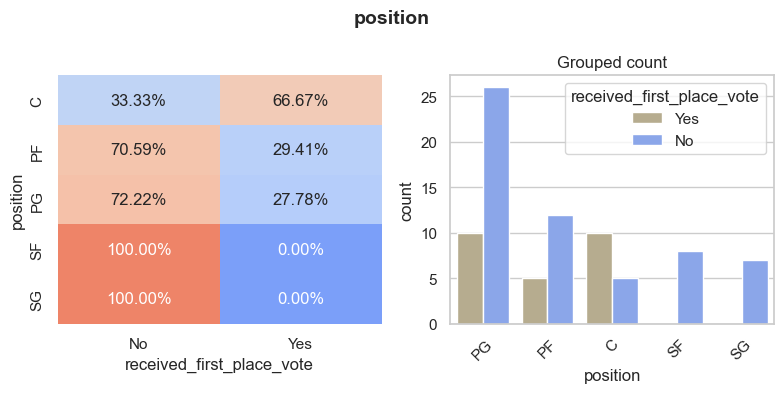

chi2_stat: 16.0818
p-value: 0.002911
Reject the Null Hypothesis
There IS a significant association between 'position' and 'received_first_place_vote'.


In [92]:
compare_two_categorical(mvp_fpv, "position", "received_first_place_vote")

In [94]:
alpha = 0.05

contingency = pd.crosstab(mvp_fpv["position"], mvp_fpv["received_first_place_vote"])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic = {chi2_stat:.4f},  dof = {dof},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")

Chi-square statistic = 16.0818,  dof = 4,  p = 0.002911
Result: Significant — reject H0


---
## Has the agility (height-to-weight ratio) of each season's top 20 players increased over time?

- **Agility definition:** agility = height_cm / weight_kg
- **Recent group:** top 20 players (rank ≤ 20) in the 2022-23 and 2023-24 seasons
- **Past group:** top 20 players (rank ≤ 20) in the 2020-21 and 2021-22 seasons
- **H0:** the mean agility of the recent group is **not greater** than the past group (μ_recent ≤ μ_past)
- **H1:** the mean agility of the recent group **is greater** than the past group (μ_recent > μ_past)
- **Test:** one-tailed (`alternative='greater'`) — since the claim is explicitly directional ("has increased")

In [ ]:
# filter to each season's top 20 players and build the agility variable
top20 = data[data['rank'] <= 20].copy()
top20['agility'] = top20['height_cm'] / top20['weight_kg']

# season_id: 2 -> 2020-21 , 3 -> 2021-22 , 4 -> 2022-23 , 5 -> 2023-24
past = top20[top20['season_id'].isin([2, 3])]   # 2020-21 through 2021-22
recent = top20[top20['season_id'].isin([4, 5])]   # 2022-23 through 2023-24

print(f"Sample sizes — past: {len(past)}   recent: {len(recent)}")
past['agility'].describe(), recent['agility'].describe()

In [162]:
# check normality before choosing the test
shapiro_p_past = shapiro(past['agility'].dropna()).pvalue
shapiro_p_recent = shapiro(recent['agility'].dropna()).pvalue
print(f"Shapiro (past):   p = {shapiro_p_past:.4g}")
print(f"Shapiro (recent): p = {shapiro_p_recent:.4g}")

Shapiro (past):   p = 0.5843
Shapiro (recent): p = 0.6211


In [172]:
alpha = 0.05

if shapiro_p_past > alpha and shapiro_p_recent > alpha:
    stat, p_value = ttest_ind(recent['agility'], past['agility'], alternative='greater', equal_var=False)
    test_used = "Welch's t-test (one-sided: recent > past)"
else:
    stat, p_value = mannwhitneyu(recent['agility'], past['agility'], alternative='greater')
    test_used = "Mann-Whitney U (one-sided: recent > past)"

print(f"Test used: {test_used}")
print(f"statistic = {stat:.4f},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")

Test used: Welch's t-test (one-sided: recent > past)
statistic = 0.0072,  p = 0.4971
Result: Not significant — fail to reject H0


**Conclusion:**

There is no significant evidence that the top 20 players' agility (height ÷ weight) has increased in recent seasons compared to a couple of seasons earlier. The two group means are nearly identical (2.028 vs. 2.029), so this isn't a case of a real difference that the test missed — the data itself shows essentially no change.

This is consistent with what we'd expect physically: an adult player's height and weight are largely fixed for the rest of their career, so a ratio built entirely from those two traits has little room to shift from one season to the next, regardless of any real change in playing style or athleticism the league may have undergone.

---
## Has Players' "Innate Ability" Improved?

**Claim:** an expert argues that, thanks to modern progress and better conditions, people's ability to develop and express their innate talent has improved compared to the past. As supporting evidence, the expert claims that the average *innate ability* of the players on the championship-winning team is higher in the **last 2 seasons** than it was **2 seasons before that**. The expert defines *innate ability* as **experience relative to age** (experience ÷ age) — the idea being that someone who has accumulated more career experience per year of life has converted more of their life into skill.

In [210]:
# the champion team for each of the 4 most recent seasons on record
champ_recent = champ.merge(seasons, on="season_id").sort_values("season_id", ascending=False).head(4).sort_values("season_id").reset_index(drop=True)

print("4 most recent seasons with a recorded champion:")
print(champ_recent[["season_id", "season", "team_id"]].to_string(index=False))

# Most recent 2 seasons vs. the 2 seasons before those
last_2_seasons = champ_recent.iloc[2:]
prior_2_seasons = champ_recent.iloc[:2]

4 most recent seasons with a recorded champion:
 season_id  season  team_id
         4 2022-23        8
         5 2023-24       20
         6 2024-25       21
         7 2025-26       20


In [212]:
group_recent = data.merge(last_2_seasons[['season_id', 'team_id']])
group_recent = group_recent.query("games > 0 and age > 0").copy()
group_recent["innate_ability"] = group_recent["experience_years"] / group_recent["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_recent = group_recent[cols]
group_recent

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1367,Shai Gilgeous-Alexander,2024-25,21,26,6,0.230769
1,2130,Jalen Williams,2024-25,21,23,2,0.086957
2,2121,Aaron Wiggins,2024-25,21,26,3,0.115385
3,1522,Isaiah Joe,2024-25,21,25,4,0.160000
4,1273,Luguentz Dort,2024-25,21,25,5,0.200000
5,1429,Isaiah Hartenstein,2024-25,21,26,6,0.230769
6,2086,Cason Wallace,2024-25,21,21,1,0.047619
7,1465,Chet Holmgren,2024-25,21,22,1,0.045455
8,2134,Kenrich Williams,2024-25,21,30,6,0.200000
9,1174,Alex Caruso,2024-25,21,30,7,0.233333


In [213]:
group_prior = data.merge(prior_2_seasons[['season_id', 'team_id']])
group_prior = group_prior.query("games > 0 and age > 0").copy()
group_prior["innate_ability"] = group_prior["experience_years"] / group_prior["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_prior = group_prior[cols]
group_prior

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1539,Nikola JokiA,2022-23,8,27,7,0.259259
1,1752,Jamal Murray,2022-23,8,25,6,0.240000
2,1377,Aaron Gordon,2022-23,8,27,8,0.296296
3,1851,Michael Porter Jr.,2022-23,8,24,3,0.125000
4,1128,Bruce Brown,2022-23,8,26,4,0.153846
5,1157,Kentavious Caldwell-Pope,2022-23,8,29,9,0.310345
6,1507,Reggie Jackson,2022-23,8,32,11,0.343750
7,1487,Bones Hyland,2022-23,8,22,1,0.045455
8,1142,Thomas Bryant,2022-23,8,25,5,0.200000
9,1394,Jeff Green,2022-23,8,36,15,0.416667


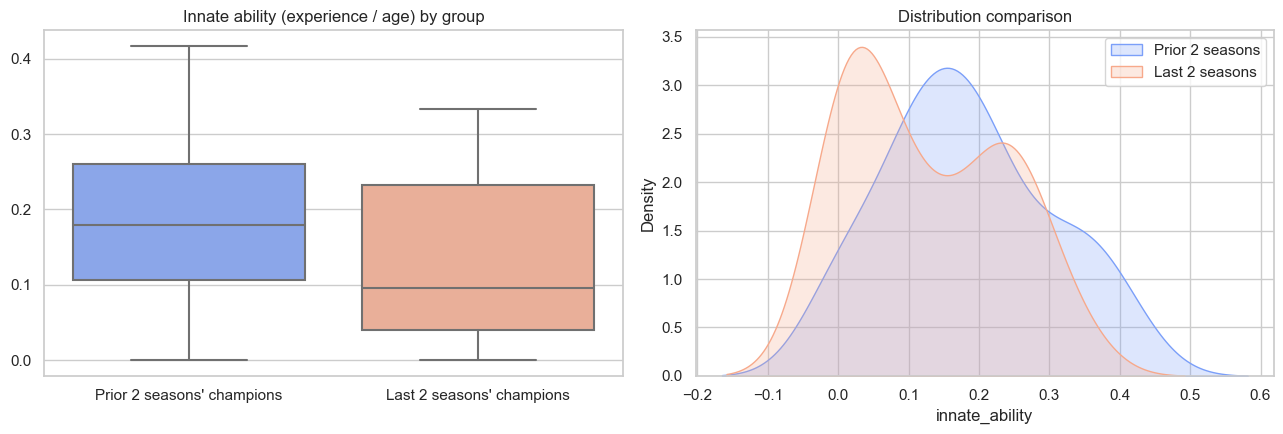

Mean innate ability, prior 2 seasons' champions: 0.1838
Mean innate ability, last 2 seasons' champions:  0.1260


In [214]:
# compare the two groups' innate-ability distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=[group_prior["innate_ability"], group_recent["innate_ability"]], ax=axes[0], palette=[Blue, Orange])
axes[0].set_xticklabels(["Prior 2 seasons' champions", "Last 2 seasons' champions"])
axes[0].set_title("Innate ability (experience / age) by group")

sns.kdeplot(group_prior["innate_ability"], fill=True, label="Prior 2 seasons", color=Blue, ax=axes[1])
sns.kdeplot(group_recent["innate_ability"], fill=True, label="Last 2 seasons", color=Orange, ax=axes[1])
axes[1].set_title("Distribution comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean innate ability, prior 2 seasons' champions: {group_prior['innate_ability'].mean():.4f}")
print(f"Mean innate ability, last 2 seasons' champions:  {group_recent['innate_ability'].mean():.4f}")

In [215]:
alpha = 0.05

shapiro_p_recent = stats.shapiro(group_recent["innate_ability"]).pvalue
shapiro_p_prior = stats.shapiro(group_prior["innate_ability"]).pvalue
print(f"Shapiro (last 2 seasons' champions):  p = {shapiro_p_recent:.4g}")
print(f"Shapiro (prior 2 seasons' champions): p = {shapiro_p_prior:.4g}")

Shapiro (last 2 seasons' champions):  p = 0.001088
Shapiro (prior 2 seasons' champions): p = 0.1234


In [216]:
stat, p = stats.mannwhitneyu(group_recent["innate_ability"], group_prior["innate_ability"],
                                  alternative="greater")
test_used = "Mann-Whitney U (one-sided: recent > prior)"
print(f"\nMann-Whitney U (one-sided: recent > prior) used.")
print(f"statistic = {stat:.4f}, p = {p:.4g}")


Mann-Whitney U (one-sided: recent > prior) used.
statistic = 633.5000, p = 0.9802


**Result:** p >= alpha, fail to reject H0 — no significant evidence for the expert's claim in this specific example.

- This tests one specific example (one team's roster, twice), not the general claim about society or the league as a whole — even a clear result here would only support the claim's illustration, not prove the broader statement.
- A champion roster's experience mix is shaped by team-building strategy (a team can win by combining a few veteran stars with young role players), not just by how much "innate ability" individual players have converted to skill — the metric conflates roster construction with individual development.
- experience_at_season uses nba_debut as the start of a career; it does not account for time missed to injury or time spent outside the NBA (overseas, G League), so it is a reasonable but imperfect proxy for actual playing experience.
- With only two seasons per group, the sample size is small and roster-dependent — a different pair of seasons or a different champion could change the conclusion.

---
## 1. Champion Team vs. Top 15 Players — Height & Experience

**Objective**

Compare the height and playing experience of the *active* roster of the NBA championship
team in the 2024-25 and 2025-26 seasons against the Top 15 ranked players of the same
seasons — to see whether championship rosters lean on more experienced players, or are
physically different, compared with the league's individual top performers.

**SQL Queries — champion team roster, both seasons**


In [141]:
try:
    query_champ_roster_2024_25 = """
        SELECT 
            p.name, 
            p.height_cm, 
            p.experience_years,
            s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        JOIN teams AS t ON pss.team_id = t.team_id AND s.season_id = pss.season_id
        WHERE s.season = '2024-25'
          AND p.is_active = TRUE;
    """
    
    df_champ_2024_25 = pd.read_sql(query_champ_roster_2024_25, con=engine).drop_duplicates(subset=['name'])
    display(df_champ_2024_25)
    
except Exception as e:
    print(e)

,name,height_cm,experience_years,season
0,Precious Achiuwa,203,6,2024-25
1,Steven Adams,211,12,2024-25
2,Bam Adebayo,206,9,2024-25
3,Ochai Agbaji,196,4,2024-25
4,Santi Aldama,213,5,2024-25
...,...,...,...,...
593,Delon Wright,193,10,2024-25
595,Guerschon Yabusele,201,4,2024-25
596,Jahmir Young,183,2,2024-25
597,Trae Young,188,8,2024-25


In [142]:
try:
    query_champ_roster_2025_26 = """
        SELECT 
            p.name, 
            p.height_cm, 
            p.experience_years,
            s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        JOIN teams AS t ON pss.team_id = t.team_id AND s.season_id = pss.season_id
        WHERE s.season = '2025-26'
          AND p.is_active = TRUE;
    """
    
    df_champ_2025_26 = pd.read_sql(query_champ_roster_2025_26, con=engine).drop_duplicates(subset=['name'])
    display(df_champ_2025_26)
    
except Exception as e:
    print(e)

,name,height_cm,experience_years,season
0,Precious Achiuwa,203,6,2025-26
1,Steven Adams,211,12,2025-26
2,Bam Adebayo,206,9,2025-26
3,Ochai Agbaji,196,4,2025-26
5,Santi Aldama,213,5,2025-26
...,...,...,...,...
653,Jahmir Young,183,2,2025-26
654,Trae Young,188,8,2025-26
656,Omer Yurtseven,211,4,2025-26
657,Rocco Zikarsky,221,1,2025-26


**SQL Queries — Top 15 ranked players, both seasons**

In [143]:
try:
    query_top15_2024_25 = """
        SELECT 
            p.name, 
            p.height_cm, 
            p.experience_years,
            s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE pss.rank <= 15
          AND s.season = '2024-25'
          AND p.is_active = 1
        ORDER BY pss.rank ASC;
    """
    df_top15_2024_25 = pd.read_sql(query_top15_2024_25, con=engine).drop_duplicates(subset=['name'])
    display(df_top15_2024_25)
    
except Exception as e:
    print(e)

,name,height_cm,experience_years,season
0,Shai Gilgeous-Alexander,198,8,2024-25
1,Anthony Edwards,193,6,2024-25
2,Nikola JokiA,211,11,2024-25
3,Giannis Antetokounmpo,211,13,2024-25
4,Jayson Tatum,203,9,2024-25
5,Devin Booker,196,11,2024-25
6,Trae Young,188,8,2024-25
7,Tyler Herro,196,7,2024-25
8,Cade Cunningham,198,5,2024-25
9,James Harden,196,17,2024-25


In [144]:
try:
    query_top15_2025_26 = """
        SELECT 
            p.name, 
            p.height_cm, 
            p.experience_years,
            s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE pss.rank <= 15
          AND s.season = '2025-26'
          AND p.is_active = 1
        ORDER BY pss.rank ASC;
    """
    df_top15_2025_26 = pd.read_sql(query_top15_2025_26, con=engine).drop_duplicates(subset=['name'])
    display(df_top15_2025_26)
except Exception as e:
    print(e)

,name,height_cm,experience_years,season
0,Luka DonAiA,203,8,2025-26
1,Shai Gilgeous-Alexander,198,8,2025-26
2,Jaylen Brown,198,10,2025-26
3,Kevin Durant,211,18,2025-26
4,Tyrese Maxey,188,6,2025-26
5,Donovan Mitchell,188,9,2025-26
6,Jalen Brunson,188,8,2025-26
7,Jamal Murray,193,9,2025-26
8,Kawhi Leonard,198,14,2025-26
9,Nikola JokiA,211,11,2025-26


**Sanity check** — quick look at the raw `players` / `teams` tables.

In [146]:
try:
    df_players = pd.read_sql("SELECT * FROM players LIMIT 10;", con=engine)
    df_teams = pd.read_sql("SELECT * FROM teams LIMIT 10;", con=engine)
    display(df_players)
    display(df_teams)
except Exception as e:
    print(e)

,player_id,name,birth_date,height_cm,weight_kg,position,draft_year,nba_debut,experience_years,is_active,birth_place,shoots
0,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,Nigeria,Right
1,1002,Jaylen Adams,1996-05-04,183,102,Point Guard,NaN,2018,3,0,Maryland,Right
2,1003,Steven Adams,1993-07-20,211,120,Center,2013.0,2013,12,1,New Zealand,Right
3,1004,Bam Adebayo,1997-07-18,206,115,Center and Power Forward,2017.0,2017,9,1,New Jersey,Right
4,1005,Ochai Agbaji,2000-04-20,196,97,Shooting Guard,2022.0,2022,4,1,Wisconsin,Right
5,1006,Santi Aldama,2001-01-10,213,97,Power Forward,2021.0,2021,5,1,Spain,Right
6,1007,LaMarcus Aldridge,1985-07-19,211,113,Power Forward and Center,2006.0,2006,16,0,Texas,Right
7,1008,Kyle Alexander,1996-10-21,211,99,Center,NaN,2020,1,0,Ontario,Right
8,1009,Nickeil Alexander-Walker,1998-09-02,196,92,Shooting Guard,2019.0,2019,7,1,Ontario,Right
9,1010,Trey Alexander,2003-05-02,196,83,Shooting Guard,NaN,2024,2,1,Oklahoma,Right


,team_id,team_name,from_year,to_year,total_games,total_wins,total_losses,playoffs,conference_championships,division_championships,championships,league
0,1,Atlanta Hawks,1949,2025,6102,3013,3088,50,0,13,1,NBA
1,2,Boston Celtics,1946,2025,6278,3751,2527,63,11,36,18,NBA/BAA
2,3,Brooklyn Nets,1967,2025,4776,2074,2702,31,2,5,2,NBA/ABA
3,4,Charlotte Hornets,1988,2025,2877,1237,1640,10,0,0,0,NBA
4,5,Chicago Bulls,1966,2025,4844,2453,2391,36,6,9,6,NBA
5,6,Cleveland Cavaliers,1970,2025,4517,2148,2369,26,5,8,1,NBA
6,7,Dallas Mavericks,1980,2025,3707,1862,1845,25,3,5,1,NBA
7,8,Denver Nuggets,1967,2025,4777,2471,2306,41,1,13,1,NBA/ABA
8,9,Detroit Pistons,1948,2025,6162,2931,3231,44,5,12,3,NBA/BAA
9,10,Golden State Warriors,1946,2025,6268,3054,3213,38,7,12,7,NBA/BAA


**Alternative, single-query version of the same comparison** — this earlier attempt
pulls the champion-team and Top-15 groups in one query (via a `LEFT JOIN` to `champ` and a
`group_type` label) and plots height and experience side-by-side with `kdeplot`. Kept as an
alternative approach alongside the per-season queries above.

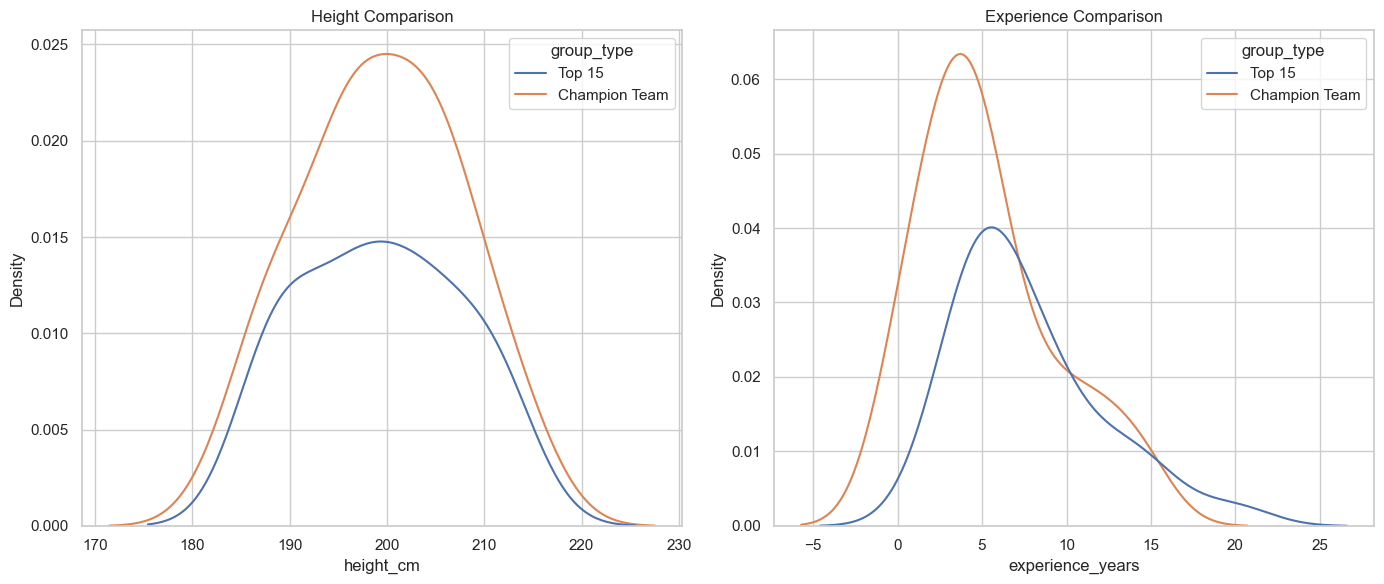

In [147]:
try:
    query_q2 = """
        SELECT p.name, p.height_cm,
               (CAST(SUBSTRING(s.season,1,4) AS SIGNED) - p.nba_debut) AS experience_years,
               s.season,
               CASE WHEN c.team_id IS NOT NULL THEN 'Champion Team' ELSE 'Top 15' END AS group_type
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id=p.player_id
        JOIN seasons AS s ON pss.season_id=s.season_id
        LEFT JOIN champ AS c ON pss.team_id=c.team_id AND pss.season_id=c.season_id
        WHERE s.season IN ('2022-23','2023-24')
          AND (c.team_id IS NOT NULL OR pss.rank <= 15);
    """
    df_q2=pd.read_sql(query_q2, con=engine)
    fig,axes=plt.subplots(1,2,figsize=(14,6))
    sns.kdeplot(data=df_q2,x='height_cm',hue='group_type',ax=axes[0])
    axes[0].set_title("Height Comparison")
    sns.kdeplot(data=df_q2,x='experience_years',hue='group_type',ax=axes[1])
    axes[1].set_title("Experience Comparison")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(e)

**Visualization** — height distribution, champion team vs. Top 15, per season.

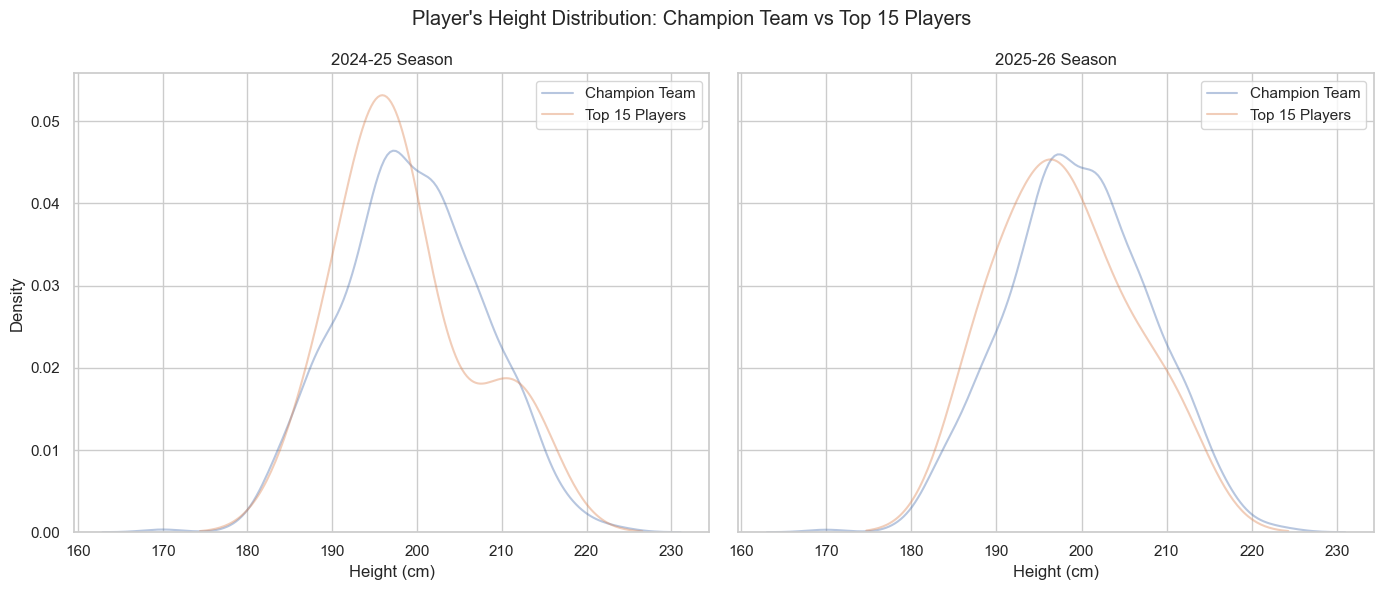

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Season 2024-25
sns.kdeplot(data=df_champ_2024_25, x='height_cm', fill=False, alpha=0.4, label='Champion Team', ax=axes[0])
sns.kdeplot(data=df_top15_2024_25, x='height_cm', fill=False, alpha=0.4, label='Top 15 Players', ax=axes[0])
axes[0].set_title("2024-25 Season")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Season 2025-26
sns.kdeplot(data=df_champ_2025_26, x='height_cm', fill=False, alpha=0.4, label='Champion Team', ax=axes[1])
sns.kdeplot(data=df_top15_2025_26, x='height_cm', fill=False, alpha=0.4, label='Top 15 Players', ax=axes[1])
axes[1].set_title("2025-26 Season")
axes[1].set_xlabel("Height (cm)")
axes[1].set_ylabel("Density")
axes[1].legend()

fig.suptitle("Player's Height Distribution: Champion Team vs Top 15 Players")
plt.tight_layout()
plt.show()

**Conclusion:**
Height tends to be similar between the two groups in both seasons, since both groups
consist of high-level NBA players regardless of team. Experience is typically where the
groups diverge more: a full championship roster includes younger, lower-experience role
players alongside its stars, while the Top 15 group is composed almost entirely of proven,
experienced stars.


---
## 2. Height Distribution: MVP Vote List vs. Top 50 Players

**Objective**

Compare the height distribution of players who appeared in the MVP voting list against the
Top 50 ranked players, across recent seasons — to see whether MVP-caliber players are
systematically taller than a broader pool of highly-ranked players.

**Helper function** — builds a combined stacked-count / stacked-proportion / KDE comparison
plot for any two groups on a numeric column.

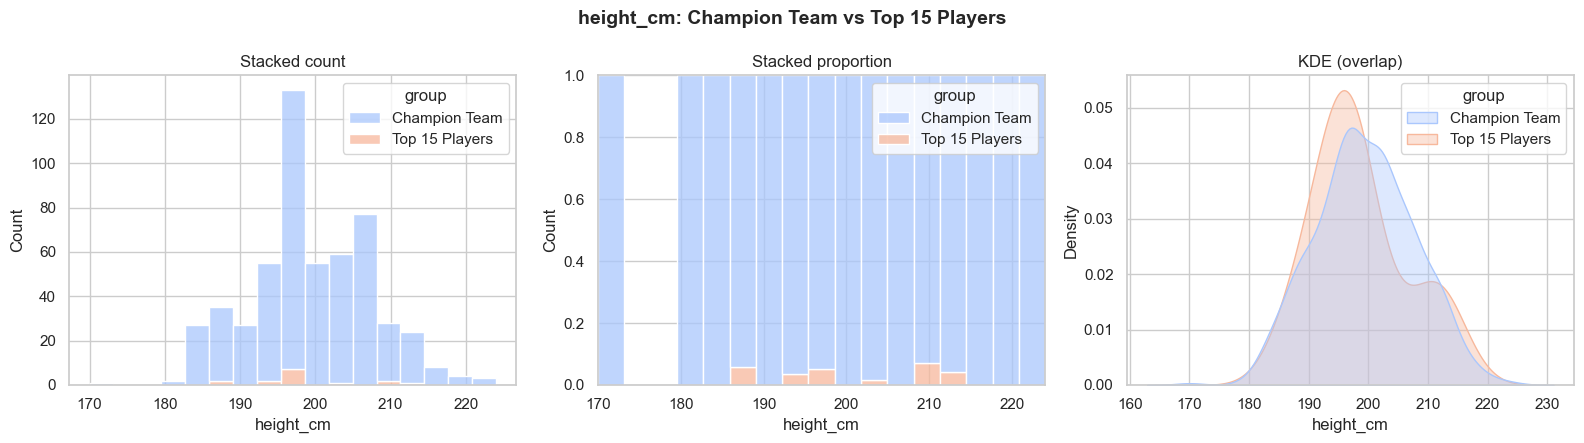

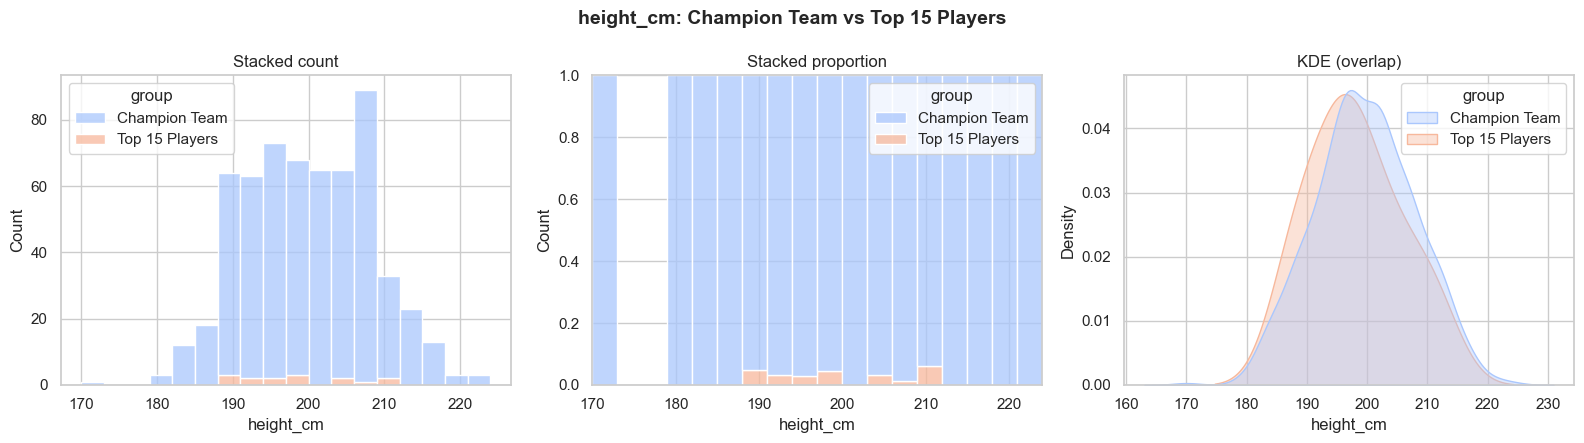

In [149]:
def compare_height(df1, df2, col='height_cm', label1='Top50', label2='MVP'):
    d1 = df1[[col]].copy()
    d1['group'] = label1
    d2 = df2[[col]].copy()
    d2['group'] = label2
    
    combined = pd.concat([d1, d2], ignore_index=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f'{col}: {label1} vs {label2}', fontsize=14, fontweight='bold')
    
    sns.histplot(data=combined, x=col, hue='group', multiple='stack', 
                 palette='coolwarm', ax=axes[0])
    axes[0].set_title('Stacked count')
    
    sns.histplot(data=combined, x=col, hue='group', multiple='fill', 
                 palette='coolwarm', ax=axes[1])
    axes[1].set_title('Stacked proportion')
    
    sns.kdeplot(data=combined, x=col, hue='group', fill=True, 
                common_norm=False, palette='coolwarm', alpha=0.4, ax=axes[2])
    axes[2].set_title('KDE (overlap)')
    
    plt.tight_layout()
    plt.show()

compare_height(df_champ_2024_25, df_top15_2024_25, col='height_cm', label1='Champion Team', label2='Top 15 Players')
compare_height(df_champ_2025_26, df_top15_2025_26, col='height_cm', label1='Champion Team', label2='Top 15 Players')

In [151]:
try:
    query_mvp = """
        SELECT
            p.name,
            p.height_cm,
            s.season,
            pss.position
        FROM mvp AS m
        JOIN players AS p ON m.player_id = p.player_id
        JOIN seasons AS s ON m.season_id = s.season_id
        JOIN player_season_stats AS pss ON pss.player_id = m.player_id AND pss.season_id = m.season_id
        WHERE m.rank = 1
            AND s.season IN ('2019-20', '2020-21', '2021-22', '2022-23', '2023-24');
    """

    query_top50 = """
        SELECT
            p.name, 
            p.height_cm, 
            s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE s.season IN ('2019-20', '2020-21', '2021-22', '2022-23','2023-24')
        ORDER BY pss.rank ASC
        
        LIMIT 50;
    """

    df_mvp = pd.read_sql(query_mvp, con=engine)
    df_top50 = pd.read_sql(query_top50, con=engine)

    display(df_mvp)
    display(df_top50)

except Exception as e:
    print(e)

,name,height_cm,season,position
0,Giannis Antetokounmpo,211,2019-20,PF
1,Nikola JokiA,211,2020-21,C
2,Nikola JokiA,211,2021-22,C
3,Joel Embiid,213,2022-23,C
4,Nikola JokiA,211,2023-24,C


,name,height_cm,season
0,James Harden,196,2019-20
1,Stephen Curry,188,2020-21
2,Trae Young,188,2021-22
3,Jayson Tatum,203,2022-23
4,Luka DonAiA,203,2023-24
5,Damian Lillard,188,2019-20
6,Damian Lillard,188,2020-21
7,DeMar DeRozan,198,2021-22
8,Joel Embiid,213,2022-23
9,Shai Gilgeous-Alexander,198,2023-24


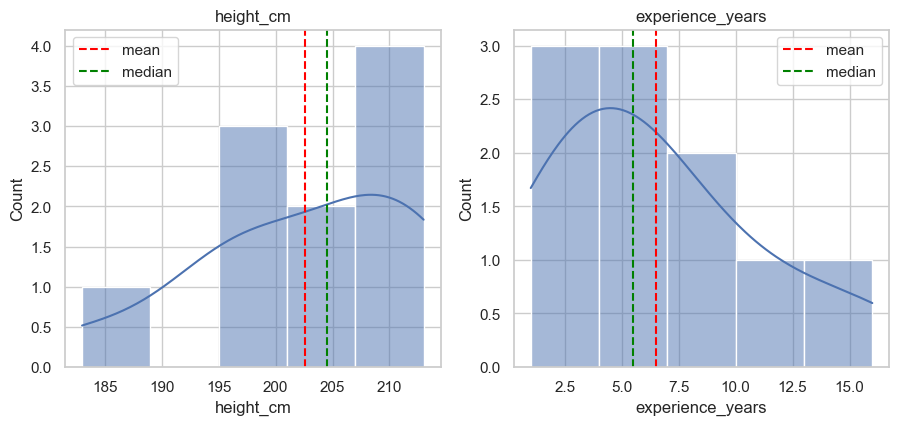

In [152]:
selected_cols=['height_cm','experience_years']
numeric_cols = df_players.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in selected_cols if 'id' not in c.lower()]
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, c in zip(axes, numeric_cols):
    sns.histplot(df_players[c], kde=True, ax=ax)
    ax.axvline(df_players[c].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df_players[c].median(), color='green', linestyle='--', label='median')
    ax.set_title(c)
    ax.legend()

for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

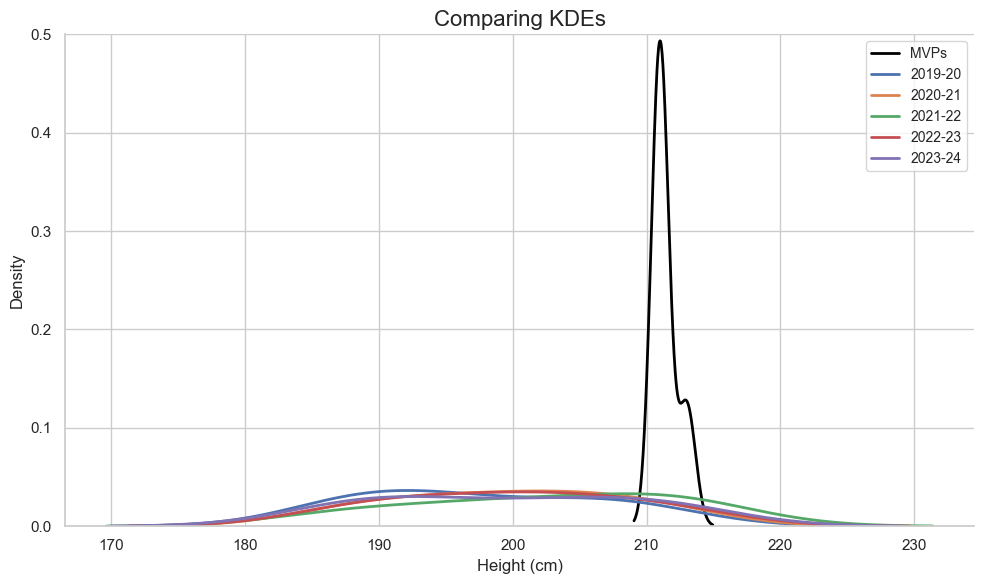

In [153]:
fig, ax = plt.subplots(figsize=(10, 6))
seasons = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

sns.kdeplot(data=df_mvp['height_cm'], fill=False, linewidth=2, 
            label='MVPs', color='black', ax=ax)

for i in seasons:
    top50 = df_top50[df_top50['season']==i]
    finall = top50['height_cm']
    sns.kdeplot(data=finall, fill=False, linewidth=2, label=i, ax=ax)

ax.set_title("Comparing KDEs", fontsize=16)
ax.set_xlabel("Height (cm)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_ylim(0,0.5)  
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

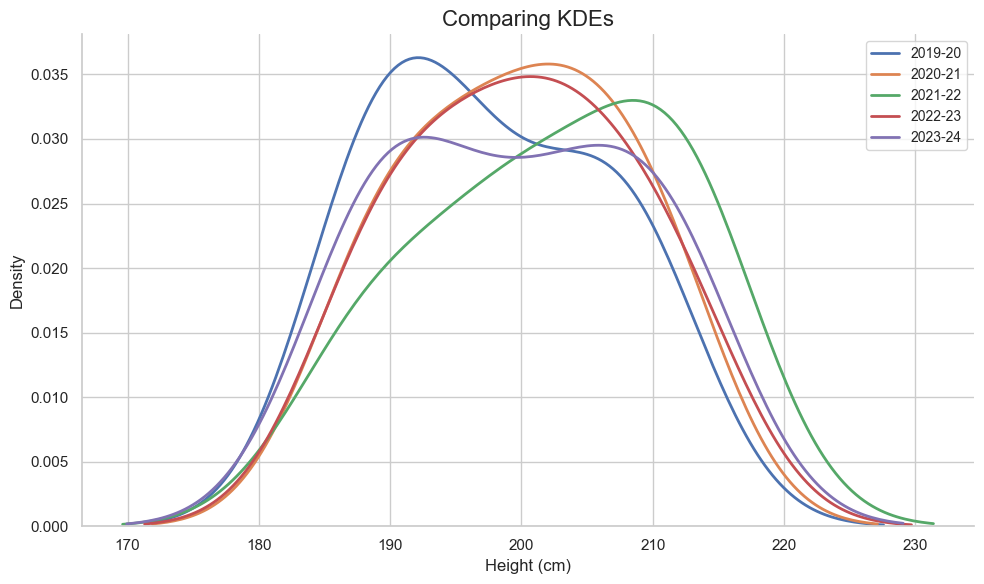

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))
seasons = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

for i in seasons:
    top50=df_top50[df_top50['season']==i]
    finall=top50['height_cm']
    sns.kdeplot(data=finall, fill=False, linewidth=2, label=i, ax=ax)

ax.set_title("Comparing KDEs", fontsize=16)
ax.set_xlabel("Height (cm)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.show()

In [155]:
print(df_mvp.columns.tolist())

['name', 'height_cm', 'season', 'position']


In [158]:
query_mvp = """
    SELECT
        p.name,
        p.height_cm,
        s.season,
        pss.position
    FROM mvp AS m
    JOIN players AS p ON m.player_id = p.player_id
    JOIN seasons AS s ON m.season_id = s.season_id
    JOIN player_season_stats AS pss ON pss.player_id = m.player_id AND pss.season_id = m.season_id
    WHERE s.season IN ('2019-20', '2020-21', '2021-22', '2022-23', '2023-24');
"""

df_mvp = pd.read_sql(query_mvp, engine)


print(df_mvp)
df_mvp.head()

                     name  height_cm   season position
0   Giannis Antetokounmpo        211  2019-20       PF
1            LeBron James        206  2019-20       PG
2            James Harden        196  2019-20       SG
3             Luka DonAiA        203  2019-20       PG
4           Kawhi Leonard        198  2019-20       SF
..                    ...        ...      ...      ...
58          Jalen Brunson        188  2023-24       PG
59           Jayson Tatum        203  2023-24       PF
60        Anthony Edwards        193  2023-24       SG
61       Domantas Sabonis        208  2023-24        C
62           Kevin Durant        211  2023-24       PF

[63 rows x 4 columns]


,name,height_cm,season,position
0,Giannis Antetokounmpo,211,2019-20,PF
1,LeBron James,206,2019-20,PG
2,James Harden,196,2019-20,SG
3,Luka DonAiA,203,2019-20,PG
4,Kawhi Leonard,198,2019-20,SF


**Conclusion:**

The MVP-list group and the Top 50 group typically overlap substantially in height, with the
MVP list skewing a little taller on average — consistent with MVP voting favoring
high-impact forwards/centers, while the Top 50 group spans a wider range of positions
(including shorter guards).

---
## 3. Point Guard Recommendation for the Club

**Objective**

The club wants to sign a Point Guard. Player quality is measured by presence in the MVP
voting list. The goal is to identify the most consistently elite Point Guards and recommend
candidates for acquisition.

In [159]:
try:
    query_pg = """
        SELECT p.name,s.season,pss.position
        FROM mvp AS m
        JOIN players AS p ON m.player_id=p.player_id
        JOIN seasons AS s ON m.season_id=s.season_id
        JOIN player_season_stats AS pss ON pss.player_id=m.player_id AND pss.season_id=m.season_id
        WHERE s.season IN ('2019-20','2020-21','2021-22','2022-23','2023-24');
    """
    df_mvp_pg=pd.read_sql(query_pg, con=engine)
    filtered=df_mvp_pg[(df_mvp_pg['position'].str.contains('PG', na=False)) &
        (df_mvp_pg['season'].isin(seasons))]
    presence_count=filtered.pivot_table(index='name',values='season',aggfunc='count')
    presence_count=presence_count.rename(columns={'season':'appearances_in_seasons'}).reset_index()
    presence_count=presence_count.sort_values('appearances_in_seasons',ascending=False)
    print(presence_count.head(3))
except Exception as e:
    print(e)

             name  appearances_in_seasons
9     Luka DonAiA                       5
1      Chris Paul                       3
12  Stephen Curry                       3


In [160]:
li = []
for i in filtered['name']:
    li.append(i)
    print(i) 

LeBron James
Luka DonAiA
Chris Paul
Damian Lillard
Stephen Curry
Chris Paul
Luka DonAiA
Damian Lillard
Derrick Rose
Derrick Rose
Russell Westbrook
Ben Simmons
James Harden
James Harden
LeBron James
Luka DonAiA
Ja Morant
Stephen Curry
Chris Paul
Shai Gilgeous-Alexander
Luka DonAiA
Stephen Curry
De'Aaron Fox
Jalen Brunson
Ja Morant
Shai Gilgeous-Alexander
Luka DonAiA
Jalen Brunson
